# COMP8851 — GHRN controlled benchmark

Trains **GHRN only** across all six datasets under the controlled protocol, and
saves its results to its own tree. Run the CARE-GNN notebook separately; the two
can run in parallel sessions and never touch each other's evidence.

Paper: Gao et al., WWW 2023. Code: https://github.com/blacksingular/GHRN
Backbone: Tang et al., ICML 2022.

Trained in the published two-stage procedure. Stage 1 trains the beta-wavelet
backbone on the unrefined graph, which is the BWGNN-equivalent baseline, and its
posteriors score every edge for heterophily. Stage 2 deletes the most
heterophilic fraction, reinitialises and retrains. Stage 2 is always the reported
result when `del_ratio > 0`; reporting whichever stage won would publish a BWGNN
number under the GHRN name.

## The controlled specification

Every run in this notebook obeys the same frozen rules.

| Rule | Value |
|---|---|
| GPU | NVIDIA T4, GPU 0 only |
| Split seed | 2 |
| Train seeds | 2, 42, 72 |
| Optimizer | Adam, beta 0.9/0.999, eps 1e-8 |
| Tuning | TR40, train seed 2, at most 12 trials, identical budget per dataset |
| Config selection | validation AUPRC |
| Max epochs / patience | 100 / 20 |
| Threshold | validation Macro-F1 swept 0.01 to 0.99 step 0.01 |
| Test | evaluated exactly once, after everything is frozen |

Test isolation is enforced by the command, not by convention: every tuning trial
runs with `--skip-test`, so no tuning run can read, score or write test data.

## Before running

1. **GPU on.** Kaggle: Settings → Accelerator → GPU. Colab: Runtime → Change runtime type.
2. **Internet on.** Kaggle: Settings → Internet → On. Nothing downloads without it.
3. *(Elliptic)* Kaggle: **+ Add Input** → search `elliptic-data-set` → **Add**.
4. **Run All.** Edit only the CONFIG cell.


## 1. Environment

In [38]:
# Detect the platform, pick a writable directory, and check the GPU.
import os, sys, subprocess, shutil, time, json
from pathlib import Path

def detect_platform():
    if Path("/kaggle").exists():
        return "kaggle"
    if "google.colab" in sys.modules or Path("/content").exists():
        return "colab"
    return "local"

PLATFORM = detect_platform()
if PLATFORM == "kaggle":
    ROOT = Path("/kaggle/working/comp8851")
elif PLATFORM == "colab":
    ROOT = Path("/content/comp8851")
else:
    ROOT = Path.cwd() / "comp8851"

DATA_ROOT    = ROOT / "data"
RESULTS_ROOT = ROOT / "results_ghrn"          # this model's own results tree
RAW_ROOT     = RESULTS_ROOT / "raw"                # per-run evidence bundles
TUNING_ROOT  = RESULTS_ROOT / "tuning"             # tuning trials, kept separate
for directory in (ROOT, DATA_ROOT, RESULTS_ROOT, RAW_ROOT, TUNING_ROOT):
    directory.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

# The protocol fixes GPU 0 only.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print(f"Platform : {PLATFORM}")
print(f"Root     : {ROOT}")
print(f"Results  : {RESULTS_ROOT}")
print(f"Python   : {sys.version.split()[0]}")


Platform : kaggle
Root     : /kaggle/working/comp8851
Results  : /kaggle/working/comp8851/results_ghrn
Python   : 3.12.13


In [39]:
# Install anything missing. Torch is already present on Kaggle and Colab.
def pip_install(*packages, extra_args=()):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *packages, *extra_args],
        capture_output=True, text=True)
    if result.returncode != 0:
        tail = (result.stderr or result.stdout).strip().splitlines()
        print(f"  pip failed for {packages}: {tail[-1][:200] if tail else ''}")
    return result.returncode == 0

def have(module):
    try:
        __import__(module)
        return True
    except Exception:
        return False

required = {"torch": "torch", "numpy": "numpy", "scipy": "scipy",
            "sklearn": "scikit-learn", "pandas": "pandas", "sympy": "sympy",
            "yaml": "PyYAML", "matplotlib": "matplotlib", "psutil": "psutil",
            "gdown": "gdown"}
missing = [package for module, package in required.items() if not have(module)]
if missing:
    print(f"installing: {', '.join(missing)}")
    pip_install(*missing)
else:
    print("all core packages present")

import torch
CONTROLLED_GPU = "Tesla T4"
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None

print(f"\ntorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")
if GPU_NAME:
    print(f"GPU  : {GPU_NAME}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    if CONTROLLED_GPU.lower() not in GPU_NAME.lower():
        print(f"\n  NOTE: the controlled specification is {CONTROLLED_GPU}, this host is")
        print(f"  {GPU_NAME}. Predictive metrics remain valid, but runtime and memory")
        print("  figures are NOT comparable with T4 numbers. The manifest records the")
        print("  GPU actually used, so this stays visible rather than silent.")
else:
    print("No GPU detected. Training will run on CPU and be far slower.")
    print("Kaggle: Settings -> Accelerator -> GPU.  Colab: Runtime -> Change runtime type.")


all core packages present

torch 2.10.0+cu128 | CUDA available: True
CUDA_VISIBLE_DEVICES = 0
GPU  : Tesla T4
VRAM : 14.6 GB


In [40]:
# GHRN uses DGL for message passing, and falls back to an equivalent
# torch.sparse backend when DGL is unavailable. DGL is also needed to
# decode FDCompCN, T-Finance and T-Social.
#
# DGL wheels are compiled against a specific PyTorch ABI and currently top out at
# torch 2.4, while hosted notebooks ship much newer torch. If DGL will not import
# here, the notebook builds a small ISOLATED environment purely to decode those
# three files into a library-free .npz cache. The training environment is never
# downgraded.

def dgl_works():
    try:
        import dgl
        dgl.graph(([0], [1]))
        return True
    except Exception:
        return False

if not dgl_works():
    torch_mm = ".".join(torch.__version__.split(".")[:2])
    cuda_tag = "cu" + torch.version.cuda.replace(".", "") if torch.version.cuda else "cpu"
    for index_url in [f"https://data.dgl.ai/wheels/torch-{torch_mm}/{cuda_tag}/repo.html",
                      f"https://data.dgl.ai/wheels/torch-{torch_mm}/repo.html",
                      "https://data.dgl.ai/wheels/torch-2.4/cu121/repo.html",
                      "https://data.dgl.ai/wheels/repo.html"]:
        pip_install("dgl", extra_args=("-f", index_url))
        if dgl_works():
            break

DGL_AVAILABLE = dgl_works()
if DGL_AVAILABLE:
    import dgl
    print(f"DGL usable in this environment: {dgl.__version__}")
else:
    print("DGL is NOT usable in this environment (expected on recent torch builds).")
    print("The dataset cell will build an isolated decoder environment instead.")


DGL is NOT usable in this environment (expected on recent torch builds).
The dataset cell will build an isolated decoder environment instead.


## 2. Write the codebase

Each cell writes one verified source file. They only touch disk.

In [41]:
# %%writefile cannot create directories, so make them first.
for folder in ["models/ghrn/ghrnlib", "models/ghrn/scripts", "shared", "shared/comp8851"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
print('Directories ready.')


Directories ready.


In [42]:
%%writefile shared/__init__.py
"""Shared COMP8851 benchmark assets: split registry and the ``comp8851`` library."""


Overwriting shared/__init__.py


In [43]:
%%writefile shared/comp8851/__init__.py
"""COMP8851 shared benchmark library.

This package holds the machinery that must be *identical* across every model in
the COMP8851 fraud-GNN benchmark: dataset loading, split handling, evaluation,
timing, and the result-artefact schema required by master plan v4.4.

Model-specific code (architectures, losses, optimisers, hyperparameters) lives
under ``models/<model>/`` and must never be duplicated here.

Reference: COMP8851_VastAI_Master_Plan_FINAL_v4.4.docx, sections 4, 9 and 10.
"""

from . import artifacts, datasets, evaluator, protocol, runtime, splits

__all__ = ["artifacts", "datasets", "evaluator", "protocol", "runtime", "splits",
           "aggregate", "report", "tuning", "dgl_env"]

__version__ = "1.0.0"


Overwriting shared/comp8851/__init__.py


In [44]:
%%writefile shared/comp8851/protocol.py
"""Protocol identity and constants for COMP8851 benchmark protocol v4.4.

Every controlled run must record which protocol it was executed under. The
constants here are the machine-readable form of the rules frozen in
``COMP8851_VastAI_Master_Plan_FINAL_v4.4.docx``.

Nothing in this module may be changed for a single model or dataset. A change
here is a protocol amendment and requires a dated entry in the decision
register plus a re-run of every affected comparison.
"""

from __future__ import annotations

import hashlib
import json
import subprocess
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Dict, Optional

# --------------------------------------------------------------------------
# Frozen protocol constants (master plan v4.4, sections 7.3, 8.1 and 10)
# --------------------------------------------------------------------------

PROTOCOL_VERSION = "vast-v4.4"

#: Split-generation seed. Fixed for every model and dataset; never varies.
SPLIT_SEED = 2

#: Training seeds for final unified runs (weight init, dropout, sampling).
TRAIN_SEEDS = (2, 42, 72)

#: Controlled training ratios. Validation and test IDs are identical across all
#: four; only the labelled training pool shrinks. TR10 < TR20 < TR30 < TR40.
TRAIN_RATIOS = {
    "TR40": 0.40,
    "TR30": 0.30,
    "TR20": 0.20,
    "TR10": 0.10,
}

#: Fixed validation and test fractions of the whole eligible node set.
VALIDATION_FRACTION = 0.20
TEST_FRACTION = 0.40

#: Unified stopping rule.
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20

#: Tuning budget. This is a hard ceiling: no model-dataset pair may exceed it,
#: and every pair must receive the same budget so neither model is advantaged.
MAX_TUNING_TRIALS = 12

#: Tuning runs on TR40 with train seed 2 only, and never evaluates test.
TUNING_RATIO = "TR40"
TUNING_SEED = 2

#: Controlled GPU class for the benchmark. Recorded in every run and checked at
#: launch; a mismatch is reported, never silently accepted.
CONTROLLED_GPU = "Tesla T4"

#: Checkpoint selection metric under protocol v4.4. NOT AUROC -- the team
#: pre-registered validation AUPRC for the imbalanced fraud task.
SELECTION_METRIC = "auprc"

#: Threshold-selection rule: sweep validation thresholds 0.01..0.99 in 0.01
#: steps, maximise Macro-F1, tie-break by fraud recall then closeness to 0.5.
THRESHOLD_MIN = 0.01
THRESHOLD_MAX = 0.99
THRESHOLD_STEP = 0.01
THRESHOLD_OBJECTIVE = "macro_f1"

#: CPU thread cap applied identically on every benchmark machine.
CPU_THREAD_CAP = 8

#: The six datasets in scope. No substitutions, no additions.
DATASETS = ("yelpchi", "amazon", "tfinance", "tsocial", "elliptic", "fdcompcn")

#: Experimental tracks. These must never be merged in reporting.
TRACKS = ("author", "unified")

#: Compatibility statuses from master plan section 5.
COMPATIBILITY_STATUSES = (
    "PASS",
    "PASS_WITH_SHARED_ADAPTER",
    "CONDITIONAL",
    "FAILED_TECHNICAL",
    "NOT_ELIGIBLE",
)

#: Run status values used by the resumable run ledger.
RUN_STATUSES = ("PENDING", "RUNNING", "COMPLETE", "FAILED", "SKIPPED")

#: Datasets whose split is chronological rather than random-stratified.
CHRONOLOGICAL_DATASETS = ("elliptic",)


def sha256_file(path: Path | str, chunk_size: int = 1 << 20) -> str:
    """Return the SHA256 hex digest of a file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(chunk_size), b""):
            digest.update(block)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    """Return the SHA256 hex digest of a byte string."""
    return hashlib.sha256(payload).hexdigest()


def config_sha256(config: Dict[str, Any]) -> str:
    """Hash a fully-resolved configuration dictionary.

    The hash is computed after defaults and command-line overrides have been
    merged, so two runs sharing a ``config_sha256`` used byte-identical
    effective hyperparameters.
    """
    canonical = json.dumps(config, sort_keys=True, separators=(",", ":"), default=str)
    return sha256_bytes(canonical.encode("utf-8"))


def git_commit(repo_root: Optional[Path] = None) -> Optional[str]:
    """Return the current 40-character git commit SHA, or None if unavailable."""
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=str(repo_root) if repo_root else None,
            capture_output=True,
            text=True,
            timeout=10,
            check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    if result.returncode != 0:
        return None
    commit = result.stdout.strip()
    return commit if len(commit) == 40 else None


@dataclass
class ProtocolIdentity:
    """The identity fields required in every controlled run record.

    Master plan v4.4 section 9.6 makes each of these mandatory so that any two
    result rows can be checked for comparability without re-reading the code.
    """

    protocol_version: str = PROTOCOL_VERSION
    hardware_profile_id: Optional[str] = None
    container_digest: Optional[str] = None
    model_source_commit: Optional[str] = None
    dataset_manifest_version: Optional[str] = None
    source_sha256: Optional[str] = None
    dataset_view_id: Optional[str] = None
    view_sha256: Optional[str] = None
    split_registry_version: Optional[str] = None
    split_sha256: Optional[str] = None
    evaluator_commit: Optional[str] = None
    adapter_version: Optional[str] = None
    adapter_sha256: Optional[str] = None
    config_sha256: Optional[str] = None
    selection_metric: str = SELECTION_METRIC
    threshold_rule: str = (
        f"validation {THRESHOLD_OBJECTIVE} swept {THRESHOLD_MIN}-{THRESHOLD_MAX} "
        f"step {THRESHOLD_STEP}; tie-break fraud recall then closeness to 0.5"
    )
    max_epochs: int = MAX_EPOCHS
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE
    split_seed: int = SPLIT_SEED
    notes: Dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    def missing_fields(self) -> list[str]:
        """Return identity fields that are still unset.

        Used by the pre-run checklist: a final controlled run should not be
        reported while required provenance fields are empty.
        """
        required = [
            "hardware_profile_id",
            "model_source_commit",
            "source_sha256",
            "dataset_view_id",
            "split_sha256",
            "config_sha256",
        ]
        return [name for name in required if getattr(self, name) in (None, "")]


def run_name(model: str, dataset: str, track: str, ratio: str, seed: int,
             gpu: str, timestamp: str) -> str:
    """Build the canonical run name from master plan v4.4 section 9.2.

    Example: ``pcgnn_yelpchi_unified_tr40_seed2_a6000_20260912T093000Z``
    """
    safe_gpu = "".join(ch if ch.isalnum() else "-" for ch in gpu.lower()).strip("-")
    return (
        f"{model.lower()}_{dataset.lower()}_{track.lower()}_{ratio.lower()}"
        f"_seed{seed}_{safe_gpu}_{timestamp}"
    )


def result_dir(results_root: Path | str, model: str, dataset: str, track: str,
               ratio: str, seed: int) -> Path:
    """Return the required result directory from master plan v4.4 section 9.5.

    ``results/<model>/<dataset>/<track>/<ratio>/seed_<seed>/``
    """
    return (
        Path(results_root)
        / model.lower()
        / dataset.lower()
        / track.lower()
        / ratio.lower()
        / f"seed_{seed}"
    )


Overwriting shared/comp8851/protocol.py


In [45]:
%%writefile shared/comp8851/evaluator.py
"""Shared evaluator for the COMP8851 fraud-GNN benchmark.

Every model must score predictions through this module. A model that computes
its own metrics is not comparable, because differences in averaging, positive
class, zero-division handling or threshold choice silently change the numbers.

Protocol rules implemented here (master plan v4.4, sections 7.3 and 10.1):

* Checkpoint selection uses validation **AUPRC**.
* Thresholds are swept on **validation** data only, 0.01..0.99 in 0.01 steps,
  maximising Macro-F1, tie-broken by fraud recall and then by closeness to 0.5.
* The chosen threshold is applied unchanged to the test set.
* The positive class is always label ``1`` (fraud / anomaly).
"""

from __future__ import annotations

from typing import Dict, Sequence, Tuple

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from .protocol import THRESHOLD_MAX, THRESHOLD_MIN, THRESHOLD_STEP

#: Metric keys reported for every run, in reporting order.
METRIC_KEYS = (
    "auroc",
    "auprc",
    "macro_f1",
    "fraud_f1",
    "fraud_precision",
    "fraud_recall",
    "gmean",
    "accuracy",
)

POSITIVE_LABEL = 1


def _as_arrays(labels: Sequence[int], probabilities: Sequence[float]):
    y_true = np.asarray(labels).reshape(-1).astype(np.int64)
    y_score = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    if y_true.shape != y_score.shape:
        raise ValueError(
            f"Label/probability shape mismatch: {y_true.shape} vs {y_score.shape}"
        )
    if y_true.size == 0:
        raise ValueError("Cannot evaluate an empty prediction set.")
    unseen = set(np.unique(y_true).tolist()) - {0, 1}
    if unseen:
        raise ValueError(f"Expected binary labels 0/1; found extra values {sorted(unseen)}")
    if not np.isfinite(y_score).all():
        raise ValueError("Probabilities contain NaN or infinity.")
    return y_true, y_score


def threshold_grid() -> np.ndarray:
    """Return the frozen validation threshold grid (0.01..0.99 step 0.01)."""
    count = int(round((THRESHOLD_MAX - THRESHOLD_MIN) / THRESHOLD_STEP)) + 1
    return np.round(np.linspace(THRESHOLD_MIN, THRESHOLD_MAX, count), 10)


def select_threshold(labels: Sequence[int],
                     probabilities: Sequence[float]) -> Tuple[float, float]:
    """Choose a decision threshold on validation data under protocol v4.4.

    Maximises Macro-F1; ties are broken first by higher fraud recall, then by
    closeness to 0.5. Returns ``(threshold, macro_f1_at_threshold)``.

    This function must only ever be given validation labels. Passing test
    labels here would select the threshold from test data, which the protocol
    forbids.
    """
    y_true, y_score = _as_arrays(labels, probabilities)

    best = None  # (macro_f1, fraud_recall, -|t - 0.5|, threshold)
    for threshold in threshold_grid():
        predictions = (y_score >= threshold).astype(np.int64)
        macro = f1_score(y_true, predictions, average="macro", zero_division=0)
        rec = recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        key = (float(macro), float(rec), -abs(float(threshold) - 0.5), float(threshold))
        if best is None or key > best:
            best = key
    assert best is not None
    return best[3], best[0]


def metric_bundle(labels: Sequence[int], probabilities: Sequence[float],
                  threshold: float) -> Dict[str, float]:
    """Compute the full required metric set at a fixed threshold.

    ``threshold`` must have been selected on validation data, never here.
    """
    y_true, y_score = _as_arrays(labels, probabilities)
    predictions = (y_score >= float(threshold)).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0

    # AUROC and AUPRC are undefined when only one class is present. That is a
    # data problem, not a metric to silently fill with 0.
    present = set(np.unique(y_true).tolist())
    single_class = len(present) < 2

    bundle: Dict[str, float] = {
        "auroc": float("nan") if single_class else float(roc_auc_score(y_true, y_score)),
        "auprc": float("nan") if single_class else float(average_precision_score(y_true, y_score)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro", zero_division=0)),
        "fraud_f1": float(f1_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)),
        "fraud_precision": float(
            precision_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        ),
        "fraud_recall": float(
            recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)
        ),
        "gmean": float(np.sqrt(tpr * tnr)),
        "accuracy": float(accuracy_score(y_true, predictions)),
        "threshold": float(threshold),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "positives": int(tp + fn),
        "negatives": int(tn + fp),
        "evaluated_nodes": int(y_true.size),
    }
    if single_class:
        bundle["metric_note"] = (
            "AUROC/AUPRC undefined: evaluation set contains a single class."
        )
    return bundle


def selection_value(metrics: Dict[str, float], metric: str = "auprc") -> float:
    """Extract the checkpoint-selection scalar from a validation metric bundle."""
    if metric not in metrics:
        raise KeyError(f"Selection metric {metric!r} not present in metric bundle.")
    value = float(metrics[metric])
    if not np.isfinite(value):
        # An undefined selection metric must not silently win or lose the
        # comparison; treat it as the worst possible value and let the caller's
        # log record why.
        return float("-inf")
    return value


def evaluate_validation(labels: Sequence[int],
                        probabilities: Sequence[float]) -> Dict[str, float]:
    """Score a validation set: select the threshold, then report all metrics."""
    threshold, _ = select_threshold(labels, probabilities)
    return metric_bundle(labels, probabilities, threshold)


def summarise_seeds(runs: Sequence[Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    """Aggregate metric bundles across training seeds.

    Returns ``{metric: {"mean": m, "std": s, "n": k}}`` using the sample
    standard deviation (ddof=1) when more than one seed is present, matching
    the reporting convention in master plan section 10.2.
    """
    summary: Dict[str, Dict[str, float]] = {}
    for key in METRIC_KEYS:
        values = [float(run[key]) for run in runs if key in run and np.isfinite(run[key])]
        if not values:
            continue
        array = np.asarray(values, dtype=np.float64)
        summary[key] = {
            "mean": float(array.mean()),
            "std": float(array.std(ddof=1)) if array.size > 1 else 0.0,
            "n": int(array.size),
        }
    return summary


Overwriting shared/comp8851/evaluator.py


In [46]:
%%writefile shared/comp8851/splits.py
"""COMP8851 unified split registry.

Split policy (master plan v4.4, section 4.9):

* Split-generation seed is fixed at 2 and never varies by model or seed.
* The base partition is 40% train / 20% validation / 40% test over the
  **eligible** (supervised-labelled) nodes.
* Training subsets are nested: TR10 subset of TR20 subset of TR30 subset of TR40.
* Validation and test node IDs are identical across all four ratios, across all
  training seeds and across all models.
* Nodes dropped from a smaller training pool become ``unused_idx``; they remain
  structurally present in the graph but carry no supervised label for that run.
* Ineligible nodes (Amazon's 3,305 unlabelled users, Elliptic's unknown
  transactions) are excluded from the partition entirely, while still existing
  in the graph for message passing.

Elliptic is the documented exception: its split is chronological, not random.
Validation and test occupy later time steps and only the earlier labelled
training region shrinks across ratios.
"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence

import numpy as np
from sklearn.model_selection import train_test_split

from .protocol import (
    SPLIT_SEED,
    TEST_FRACTION,
    TRAIN_RATIOS,
    VALIDATION_FRACTION,
    sha256_file,
)

SPLIT_KEYS = ("train_idx", "valid_idx", "test_idx", "unused_idx")


# --------------------------------------------------------------------------
# Generation
# --------------------------------------------------------------------------

def build_nested_splits(labels: np.ndarray,
                        eligible_idx: Optional[np.ndarray] = None,
                        seed: int = SPLIT_SEED) -> Dict[str, Dict[str, np.ndarray]]:
    """Build nested stratified TR40/TR30/TR20/TR10 splits over eligible nodes.

    ``labels`` is the full-graph label vector; ``eligible_idx`` selects the
    nodes that may take part in supervised learning. Returns a mapping from
    ratio name to arrays of global node IDs.
    """
    labels = np.asarray(labels).reshape(-1).astype(np.int64)
    if eligible_idx is None:
        eligible = np.arange(len(labels), dtype=np.int64)
    else:
        eligible = np.asarray(eligible_idx, dtype=np.int64)
    eligible_labels = labels[eligible]

    if set(np.unique(eligible_labels).tolist()) != {0, 1}:
        raise ValueError(
            "Eligible nodes must contain both classes with binary labels 0/1; "
            f"found {sorted(set(np.unique(eligible_labels).tolist()))}"
        )

    # Base partition: 40% train pool, 60% held out -> 1/3 validation, 2/3 test,
    # giving the frozen 40/20/40 proportions.
    train40, held_out = train_test_split(
        eligible,
        train_size=TRAIN_RATIOS["TR40"],
        random_state=seed,
        shuffle=True,
        stratify=eligible_labels,
    )
    held_out_labels = labels[held_out]
    valid, test = train_test_split(
        held_out,
        train_size=VALIDATION_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
        random_state=seed,
        shuffle=True,
        stratify=held_out_labels,
    )

    # Nested training subsets. Each is drawn from the next larger pool so that
    # TR10 is a subset of TR20, and so on.
    train30, _ = train_test_split(
        train40, train_size=0.75, random_state=seed, shuffle=True,
        stratify=labels[train40],
    )
    train20, _ = train_test_split(
        train30, train_size=2.0 / 3.0, random_state=seed, shuffle=True,
        stratify=labels[train30],
    )
    train10, _ = train_test_split(
        train20, train_size=0.50, random_state=seed, shuffle=True,
        stratify=labels[train20],
    )

    pools = {"TR40": train40, "TR30": train30, "TR20": train20, "TR10": train10}
    base_pool = set(train40.tolist())
    splits: Dict[str, Dict[str, np.ndarray]] = {}
    for ratio, train in pools.items():
        unused = np.asarray(sorted(base_pool - set(train.tolist())), dtype=np.int64)
        splits[ratio] = {
            "train_idx": np.sort(np.asarray(train, dtype=np.int64)),
            "valid_idx": np.sort(np.asarray(valid, dtype=np.int64)),
            "test_idx": np.sort(np.asarray(test, dtype=np.int64)),
            "unused_idx": unused,
        }
    return splits


def build_chronological_splits(labels: np.ndarray,
                               time_steps: np.ndarray,
                               eligible_idx: Optional[np.ndarray] = None,
                               seed: int = SPLIT_SEED) -> Dict[str, Dict[str, np.ndarray]]:
    """Build the Elliptic chronological splits.

    Time order is preserved: the earliest time steps supply training, the middle
    supplies validation and the latest supplies test. Only the labelled training
    region shrinks across ratios, and it shrinks by dropping the *earliest*
    steps first so the remaining training data stays adjacent to validation.

    Nesting still holds (TR10 subset of TR20 subset of TR30 subset of TR40) and
    validation/test IDs never change.
    """
    labels = np.asarray(labels).reshape(-1).astype(np.int64)
    time_steps = np.asarray(time_steps).reshape(-1)
    if eligible_idx is None:
        eligible = np.arange(len(labels), dtype=np.int64)
    else:
        eligible = np.asarray(eligible_idx, dtype=np.int64)

    order = eligible[np.argsort(time_steps[eligible], kind="stable")]
    total = len(order)
    n_train = int(round(total * TRAIN_RATIOS["TR40"]))
    n_valid = int(round(total * VALIDATION_FRACTION))

    train40 = order[:n_train]
    valid = order[n_train:n_train + n_valid]
    test = order[n_train + n_valid:]

    # Shrink the training window from the earliest end.
    pools = {"TR40": train40}
    for ratio in ("TR30", "TR20", "TR10"):
        keep = int(round(total * TRAIN_RATIOS[ratio]))
        pools[ratio] = train40[len(train40) - keep:]

    base_pool = set(train40.tolist())
    splits: Dict[str, Dict[str, np.ndarray]] = {}
    for ratio, train in pools.items():
        unused = np.asarray(sorted(base_pool - set(train.tolist())), dtype=np.int64)
        splits[ratio] = {
            "train_idx": np.sort(np.asarray(train, dtype=np.int64)),
            "valid_idx": np.sort(np.asarray(valid, dtype=np.int64)),
            "test_idx": np.sort(np.asarray(test, dtype=np.int64)),
            "unused_idx": unused,
        }
    return splits


# --------------------------------------------------------------------------
# Verification
# --------------------------------------------------------------------------

def verify_splits(splits: Dict[str, Dict[str, np.ndarray]],
                  eligible_idx: np.ndarray,
                  total_nodes: int) -> None:
    """Raise if any split invariant is violated.

    Checks: no duplicates, no overlap between partitions, IDs inside the graph,
    every partition inside the eligible set, exact coverage of the eligible set,
    fixed validation/test IDs across ratios, and training-pool nesting.
    """
    eligible = set(np.asarray(eligible_idx, dtype=np.int64).tolist())
    errors: list[str] = []

    reference_valid = None
    reference_test = None
    for ratio in sorted(splits):
        arrays = splits[ratio]
        missing = set(SPLIT_KEYS) - set(arrays)
        if missing:
            errors.append(f"{ratio}: missing arrays {sorted(missing)}")
            continue

        sets = {name: set(np.asarray(arrays[name]).tolist()) for name in SPLIT_KEYS}
        for name in SPLIT_KEYS:
            values = np.asarray(arrays[name])
            if len(values) != len(sets[name]):
                errors.append(f"{ratio}: duplicate IDs in {name}")
            if values.size and (values.min() < 0 or values.max() >= total_nodes):
                errors.append(f"{ratio}: out-of-range IDs in {name}")
            if not sets[name].issubset(eligible):
                errors.append(f"{ratio}: {name} contains ineligible node IDs")

        names = list(SPLIT_KEYS)
        for i, left in enumerate(names):
            for right in names[i + 1:]:
                if sets[left] & sets[right]:
                    errors.append(f"{ratio}: overlap between {left} and {right}")

        covered = set().union(*sets.values())
        if covered != eligible:
            errors.append(
                f"{ratio}: partitions cover {len(covered)} eligible nodes, expected {len(eligible)}"
            )

        if not sets["train_idx"]:
            errors.append(f"{ratio}: empty training set")
        if not sets["valid_idx"] or not sets["test_idx"]:
            errors.append(f"{ratio}: empty validation or test set")

        if reference_valid is None:
            reference_valid, reference_test = sets["valid_idx"], sets["test_idx"]
        else:
            if sets["valid_idx"] != reference_valid:
                errors.append(f"{ratio}: validation IDs differ from other ratios")
            if sets["test_idx"] != reference_test:
                errors.append(f"{ratio}: test IDs differ from other ratios")

    present = [r for r in ("TR10", "TR20", "TR30", "TR40") if r in splits]
    for smaller, larger in zip(present, present[1:]):
        small = set(np.asarray(splits[smaller]["train_idx"]).tolist())
        large = set(np.asarray(splits[larger]["train_idx"]).tolist())
        if not small <= large:
            errors.append(f"training pools not nested: {smaller} is not a subset of {larger}")

    if errors:
        raise RuntimeError("Split verification failed:\n  " + "\n  ".join(errors))


def describe_partition(ids: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """Summarise one partition: size and class balance."""
    ids = np.asarray(ids, dtype=np.int64)
    total = int(ids.size)
    fraud = int(np.asarray(labels).reshape(-1)[ids].sum()) if total else 0
    return {
        "nodes": total,
        "fraud_nodes": fraud,
        "normal_nodes": total - fraud,
        "fraud_percentage": (100.0 * fraud / total) if total else 0.0,
    }


def split_summary(arrays: Dict[str, np.ndarray], labels: np.ndarray,
                  source: str) -> Dict[str, object]:
    """Build the ``split_summary.json`` payload for one run."""
    return {
        "source": source,
        "train": describe_partition(arrays["train_idx"], labels),
        "validation": describe_partition(arrays["valid_idx"], labels),
        "test": describe_partition(arrays["test_idx"], labels),
        "unused_nodes": int(np.asarray(arrays["unused_idx"]).size),
    }


# --------------------------------------------------------------------------
# Persistence
# --------------------------------------------------------------------------

def split_filename(dataset: str, ratio: str, seed: int = SPLIT_SEED) -> str:
    """Canonical split filename, e.g. ``yelpchi_TR40_seed2.npz``."""
    return f"{dataset.lower()}_{ratio.upper()}_seed{seed}.npz"


def save_splits(splits: Dict[str, Dict[str, np.ndarray]], output_dir: Path | str,
                dataset: str, labels: np.ndarray, seed: int = SPLIT_SEED,
                extra_manifest: Optional[Dict[str, object]] = None) -> Path:
    """Write split archives plus a manifest, and return the manifest path."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    labels = np.asarray(labels).reshape(-1)

    manifest: Dict[str, object] = {
        "dataset": dataset,
        "split_seed": int(seed),
        "convention": (
            "40/20/40 base partition over eligible nodes with nested stratified "
            "TR30/TR20/TR10 training subsets; validation and test IDs fixed"
        ),
        "splits": {},
    }
    if extra_manifest:
        manifest.update(extra_manifest)

    for ratio, arrays in splits.items():
        path = output_dir / split_filename(dataset, ratio, seed)
        np.savez_compressed(path, **{k: np.asarray(v, dtype=np.int64) for k, v in arrays.items()})
        manifest["splits"][ratio] = {  # type: ignore[index]
            "file": path.name,
            "file_sha256": sha256_file(path),
            "train": describe_partition(arrays["train_idx"], labels),
            "validation": describe_partition(arrays["valid_idx"], labels),
            "test": describe_partition(arrays["test_idx"], labels),
            "unused_nodes": int(np.asarray(arrays["unused_idx"]).size),
        }

    manifest_path = output_dir / f"{dataset.lower()}_split_manifest_seed{seed}.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding="utf-8")
    return manifest_path


def load_split(path: Path | str) -> Dict[str, np.ndarray]:
    """Load one split archive, tolerating legacy files without ``unused_idx``."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Split file not found: {path}")
    with np.load(path, allow_pickle=False) as data:
        required = {"train_idx", "valid_idx", "test_idx"}
        missing = required - set(data.files)
        if missing:
            raise ValueError(f"Split file {path.name} is missing arrays: {sorted(missing)}")
        arrays = {name: np.asarray(data[name], dtype=np.int64) for name in data.files}
    arrays.setdefault("unused_idx", np.asarray([], dtype=np.int64))
    return {key: arrays[key] for key in SPLIT_KEYS}


def eligible_from_split(arrays: Dict[str, np.ndarray]) -> np.ndarray:
    """Recover the eligible node set implied by a split archive."""
    union: Iterable[int] = set()
    for key in SPLIT_KEYS:
        union = set(union) | set(np.asarray(arrays[key], dtype=np.int64).tolist())
    return np.asarray(sorted(union), dtype=np.int64)


def assert_no_leakage(train_idx: Sequence[int], valid_idx: Sequence[int],
                      test_idx: Sequence[int]) -> None:
    """Fail loudly if the three supervised partitions intersect."""
    train, valid, test = (set(np.asarray(x).tolist()) for x in (train_idx, valid_idx, test_idx))
    overlaps = {
        "train/validation": train & valid,
        "train/test": train & test,
        "validation/test": valid & test,
    }
    offending = {name: len(ids) for name, ids in overlaps.items() if ids}
    if offending:
        raise RuntimeError(f"Split leakage detected: {offending}")


Overwriting shared/comp8851/splits.py


In [47]:
%%writefile shared/comp8851/datasets.py
"""Canonical dataset loaders for the six COMP8851 benchmark datasets.

Design rules (master plan v4.4, section 4):

* Acquisition, representation conversion and splitting are three separate
  stages. This module performs conversion only; it never invents a split and
  never applies performance-motivated cleaning.
* The canonical asset preserves the richest available representation. Multi-
  relational datasets keep their relations; a homogeneous union view is derived
  deterministically for models that genuinely require one.
* Every loader returns the same :class:`CanonicalDataset` structure so that
  CARE-GNN, GHRN and any future model consume identical data.

Views
-----
``relation`` : per-relation adjacency, required by relation-aware methods such
               as CARE-GNN.
``homogeneous`` : union of all relations with self-loops, required by
               genuinely homogeneous spectral methods such as BWGNN/GHRN.

Both views contain identical nodes, features and labels. Only the edge
representation differs, which is what makes an A1 adapter defensible.
"""

from __future__ import annotations

import json
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import scipy.sparse as sp

from .protocol import sha256_file

# Expected statistics, used as integrity assertions rather than as
# documentation. A mismatch means the wrong file was downloaded.
EXPECTED_STATS: Dict[str, Dict[str, Any]] = {
    "yelpchi": {"nodes": 45954, "features": 32, "relations": ["rur", "rtr", "rsr"]},
    "amazon": {"nodes": 11944, "features": 25, "relations": ["upu", "usu", "uvu"],
               "ineligible_prefix": 3305},
    "tfinance": {"features": 10},
    "tsocial": {"features": 10},
    "elliptic": {"features": 166},
    "fdcompcn": {"nodes": 5317, "features": 57, "fraud_nodes": 559,
                 "relations": ["cic", "cpc", "csc"]},
}

RELATION_NAMES: Dict[str, List[str]] = {
    "yelpchi": ["rur", "rtr", "rsr"],
    "amazon": ["upu", "usu", "uvu"],
    "fdcompcn": ["cic", "cpc", "csc"],
}


@dataclass
class CanonicalDataset:
    """A dataset in the frozen COMP8851 canonical representation."""

    name: str
    features: np.ndarray                     # (N, F) float32
    labels: np.ndarray                       # (N,) int64 in {0, 1}
    eligible_idx: np.ndarray                 # node IDs allowed in supervised splits
    relations: Dict[str, sp.spmatrix]        # relation name -> symmetric adjacency
    time_steps: Optional[np.ndarray] = None  # Elliptic chronology
    source_files: Dict[str, str] = field(default_factory=dict)
    source_sha256: Dict[str, str] = field(default_factory=dict)
    notes: Dict[str, Any] = field(default_factory=dict)

    # -- basic properties -------------------------------------------------
    @property
    def num_nodes(self) -> int:
        return int(self.features.shape[0])

    @property
    def num_features(self) -> int:
        return int(self.features.shape[1])

    @property
    def is_multi_relational(self) -> bool:
        return len(self.relations) > 1

    # -- views ------------------------------------------------------------
    def homogeneous_adjacency(self, add_self_loops: bool = True) -> sp.csr_matrix:
        """Deterministic union of every relation, symmetric and binarised."""
        if not self.relations:
            raise ValueError(f"{self.name}: no relations to build a union from.")
        union = None
        for name in sorted(self.relations):
            matrix = self.relations[name].tocsr()
            union = matrix if union is None else (union + matrix)
        assert union is not None
        union = union.maximum(union.T)          # symmetric
        union.data = np.ones_like(union.data)   # binary, no multi-edges
        if add_self_loops:
            union = union + sp.eye(self.num_nodes, format="csr")
        union = union.tocsr()
        union.data = np.ones_like(union.data)
        union.eliminate_zeros()
        return union

    def adjacency_lists(self, add_self_loops: bool = True) -> List[Dict[int, set]]:
        """Per-relation adjacency lists, the input format CARE-GNN expects.

        Returns one ``{node_id: {neighbour ids}}`` mapping per relation, in the
        canonical relation order for the dataset.
        """
        order = RELATION_NAMES.get(self.name, sorted(self.relations))
        order = [name for name in order if name in self.relations] or sorted(self.relations)
        lists = []
        for name in order:
            matrix = self.relations[name].tocsr()
            matrix = matrix.maximum(matrix.T)
            if add_self_loops:
                matrix = matrix + sp.eye(self.num_nodes, format="csr")
            matrix = matrix.tocsr()
            adj: Dict[int, set] = {}
            indptr, indices = matrix.indptr, matrix.indices
            for node in range(self.num_nodes):
                neighbours = set(indices[indptr[node]:indptr[node + 1]].tolist())
                if not neighbours:
                    # CARE-GNN indexes neighbours unconditionally; an isolated
                    # node must still have itself so the batch never breaks.
                    neighbours = {node}
                adj[node] = neighbours
            lists.append(adj)
        return lists

    def homogeneous_edges(self, add_self_loops: bool = False):
        """Edge index pair for the union view, as torch tensors.

        Library-agnostic: the caller decides whether to build a DGL graph or a
        plain sparse one, so the dataset layer stays free of model-stack
        dependencies.
        """
        import torch

        union = self.homogeneous_adjacency(add_self_loops=add_self_loops).tocoo()
        return (torch.as_tensor(union.row, dtype=torch.int64),
                torch.as_tensor(union.col, dtype=torch.int64))

    def dgl_homogeneous(self, add_self_loops: bool = True):
        """Build the homogeneous DGL graph used by spectral models."""
        import dgl
        import torch

        union = self.homogeneous_adjacency(add_self_loops=False).tocoo()
        graph = dgl.graph((torch.as_tensor(union.row, dtype=torch.int64),
                           torch.as_tensor(union.col, dtype=torch.int64)),
                          num_nodes=self.num_nodes)
        graph = dgl.to_bidirected(graph)
        graph = dgl.remove_self_loop(graph)
        if add_self_loops:
            graph = dgl.add_self_loop(graph)
        graph.ndata["feature"] = torch.as_tensor(self.features, dtype=torch.float32)
        graph.ndata["label"] = torch.as_tensor(self.labels, dtype=torch.int64)
        return graph

    # -- reporting --------------------------------------------------------
    def statistics(self) -> Dict[str, Any]:
        """Node/edge/feature/label statistics for the dataset manifest."""
        eligible_labels = self.labels[self.eligible_idx]
        fraud = int(eligible_labels.sum())
        total_eligible = int(self.eligible_idx.size)
        union = self.homogeneous_adjacency(add_self_loops=False)
        stats: Dict[str, Any] = {
            "dataset": self.name,
            "nodes": self.num_nodes,
            "feature_dimension": self.num_features,
            "eligible_nodes": total_eligible,
            "ineligible_nodes": self.num_nodes - total_eligible,
            "fraud_nodes": fraud,
            "normal_nodes": total_eligible - fraud,
            "fraud_percentage": (100.0 * fraud / total_eligible) if total_eligible else 0.0,
            "imbalance_ratio_normal_to_fraud": (
                (total_eligible - fraud) / fraud if fraud else None
            ),
            "union_stored_directed_edges": int(union.nnz),
            "union_undirected_edges": int(union.nnz // 2),
            "relations": {},
        }
        for name in sorted(self.relations):
            matrix = self.relations[name].tocsr()
            matrix = matrix.maximum(matrix.T)
            stats["relations"][name] = {
                "stored_directed_edges": int(matrix.nnz),
                "undirected_edges": int(matrix.nnz // 2),
            }
        if self.time_steps is not None:
            stats["time_steps"] = {
                "min": int(np.min(self.time_steps)),
                "max": int(np.max(self.time_steps)),
                "distinct": int(np.unique(self.time_steps).size),
            }
        return stats

    def heterophily(self) -> Dict[str, Any]:
        """Global and fraud-node local heterophily over labelled edges.

        Global H: labelled edges joining different labels divided by all
        labelled edges. Local H for a fraud node: benign labelled neighbours
        divided by all labelled neighbours. Self-loops are excluded from both.
        """
        eligible_mask = np.zeros(self.num_nodes, dtype=bool)
        eligible_mask[self.eligible_idx] = True
        union = self.homogeneous_adjacency(add_self_loops=False).tocoo()

        keep = (union.row != union.col) & eligible_mask[union.row] & eligible_mask[union.col]
        src, dst = union.row[keep], union.col[keep]
        if src.size == 0:
            return {"global_heterophily": None, "note": "no labelled edges"}
        different = float(np.mean(self.labels[src] != self.labels[dst]))

        csr = self.homogeneous_adjacency(add_self_loops=False).tocsr()
        fraud_nodes = self.eligible_idx[self.labels[self.eligible_idx] == 1]
        local: List[float] = []
        for node in fraud_nodes:
            neighbours = csr.indices[csr.indptr[node]:csr.indptr[node + 1]]
            neighbours = neighbours[(neighbours != node) & eligible_mask[neighbours]]
            if neighbours.size:
                local.append(float(np.mean(self.labels[neighbours] == 0)))
        local_array = np.asarray(local, dtype=np.float64)
        return {
            "global_heterophily": different,
            "labelled_edges_considered": int(src.size),
            "fraud_local_heterophily_mean": float(local_array.mean()) if local_array.size else None,
            "fraud_local_heterophily_median": float(np.median(local_array)) if local_array.size else None,
            "fraud_local_heterophily_std": float(local_array.std(ddof=1)) if local_array.size > 1 else None,
            "fraud_nodes_with_labelled_neighbours": int(local_array.size),
        }

    def manifest(self) -> Dict[str, Any]:
        """The ``dataset_manifest.json`` payload."""
        return {
            "dataset_id": self.name,
            "source_files": self.source_files,
            "source_sha256": self.source_sha256,
            "statistics": self.statistics(),
            "notes": self.notes,
        }

    def view_manifest(self, view: str, add_self_loops: bool = True) -> Dict[str, Any]:
        """The ``dataset_view_manifest.json`` payload for the chosen view."""
        if view not in ("relation", "homogeneous"):
            raise ValueError(f"Unknown view {view!r}; expected 'relation' or 'homogeneous'.")
        payload: Dict[str, Any] = {
            "dataset_view_id": f"{self.name}_{view}_v1",
            "view": view,
            "builder": "shared/comp8851/datasets.py",
            "builder_version": "1.0.0",
            "self_loop_policy": "added" if add_self_loops else "not added",
            "edge_convention": "symmetric, binarised, duplicates collapsed",
            "nodes": self.num_nodes,
            "feature_dimension": self.num_features,
        }
        if view == "relation":
            payload["relations"] = RELATION_NAMES.get(self.name, sorted(self.relations))
            payload["relation_edges"] = {
                name: int(self.relations[name].tocsr().maximum(self.relations[name].tocsr().T).nnz)
                for name in sorted(self.relations)
            }
        else:
            union = self.homogeneous_adjacency(add_self_loops=add_self_loops)
            payload["union_stored_directed_edges"] = int(union.nnz)
        payload["view_sha256"] = self._view_hash(view, add_self_loops)
        return payload

    def _view_hash(self, view: str, add_self_loops: bool) -> str:
        """Deterministic hash of the exact edge structure handed to the model."""
        import hashlib

        digest = hashlib.sha256()
        digest.update(self.name.encode())
        digest.update(view.encode())
        digest.update(str(add_self_loops).encode())
        digest.update(np.ascontiguousarray(self.labels).tobytes())
        digest.update(np.ascontiguousarray(self.features).tobytes())
        if view == "relation":
            for name in RELATION_NAMES.get(self.name, sorted(self.relations)):
                if name not in self.relations:
                    continue
                coo = self.relations[name].tocoo()
                order = np.lexsort((coo.col, coo.row))
                digest.update(name.encode())
                digest.update(np.ascontiguousarray(coo.row[order]).tobytes())
                digest.update(np.ascontiguousarray(coo.col[order]).tobytes())
        else:
            coo = self.homogeneous_adjacency(add_self_loops=add_self_loops).tocoo()
            order = np.lexsort((coo.col, coo.row))
            digest.update(np.ascontiguousarray(coo.row[order]).tobytes())
            digest.update(np.ascontiguousarray(coo.col[order]).tobytes())
        return digest.hexdigest()


# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------

def _symmetrise(matrix: sp.spmatrix, num_nodes: int) -> sp.csr_matrix:
    """Return a symmetric, binary, self-loop-free CSR matrix."""
    matrix = sp.csr_matrix(matrix, shape=(num_nodes, num_nodes))
    matrix = matrix.maximum(matrix.T)
    matrix.setdiag(0)
    matrix.eliminate_zeros()
    matrix.data = np.ones_like(matrix.data)
    return matrix.tocsr()


def _edges_to_matrix(src: np.ndarray, dst: np.ndarray, num_nodes: int) -> sp.csr_matrix:
    data = np.ones(len(src), dtype=np.float32)
    matrix = sp.coo_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))
    return _symmetrise(matrix, num_nodes)


def _check(condition: bool, message: str, strict: bool = True) -> None:
    if condition:
        return
    if strict:
        raise ValueError(message)
    print(f"[dataset] WARNING {message}")


# --------------------------------------------------------------------------
# Per-dataset loaders
# --------------------------------------------------------------------------

#: Official DGL distribution points for the YelpChi and Amazon archives. These
#: are the source lineage GADBench also identifies, so they are the canonical
#: team source named in the master plan.
FRAUD_ARCHIVES = {
    "yelpchi": ("https://data.dgl.ai/dataset/FraudYelp.zip", "YelpChi.mat"),
    "amazon": ("https://data.dgl.ai/dataset/FraudAmazon.zip", "Amazon.mat"),
}

#: Relation key names as stored inside the .mat files.
MAT_RELATION_KEYS = {
    "yelpchi": {"net_rur": "rur", "net_rtr": "rtr", "net_rsr": "rsr"},
    "amazon": {"net_upu": "upu", "net_usu": "usu", "net_uvu": "uvu"},
}


def _locate_or_fetch_mat(name: str, raw_dir: Path, download: bool = True) -> Path:
    """Find ``YelpChi.mat``/``Amazon.mat``, extracting or downloading if needed."""
    url, filename = FRAUD_ARCHIVES[name]
    raw_dir = Path(raw_dir)

    if raw_dir.is_file() and raw_dir.suffix.lower() == ".mat":
        return raw_dir

    raw_dir.mkdir(parents=True, exist_ok=True)
    for found in raw_dir.rglob(filename):
        return found

    archive = raw_dir / Path(url).name
    if not archive.exists():
        if not download:
            raise FileNotFoundError(
                f"{name}: {filename} not found under {raw_dir} and downloading is disabled. "
                f"Fetch {url} manually."
            )
        import urllib.request

        print(f"[dataset] downloading {url}")
        urllib.request.urlretrieve(url, archive)

    with zipfile.ZipFile(archive) as handle:
        handle.extractall(raw_dir)
    for found in raw_dir.rglob(filename):
        return found
    raise FileNotFoundError(f"{name}: {filename} missing from {archive}")


def load_fraud_mat(name: str, raw_dir: Path, strict: bool = True,
                   download: bool = True) -> CanonicalDataset:
    """Load YelpChi or Amazon from the official ``.mat`` release.

    The archive published at data.dgl.ai is exactly what ``dgl.data``'s Fraud
    datasets wrap, so reading it directly gives byte-identical graph content
    without requiring DGL. That matters because CARE-GNN's environment does not
    otherwise need DGL at all.

    DGL's generated 70/10/20 masks are not present in the ``.mat`` file and are
    not reconstructed: the unified track uses the frozen COMP8851 split IDs.
    """
    from scipy.io import loadmat

    mat_path = _locate_or_fetch_mat(name, raw_dir, download=download)
    payload = loadmat(str(mat_path))

    labels = np.asarray(payload["label"]).reshape(-1).astype(np.int64)
    feature_block = payload["features"]
    features = (feature_block.todense().A if sp.issparse(feature_block)
                else np.asarray(feature_block)).astype(np.float32)
    num_nodes = features.shape[0]

    relations: Dict[str, sp.spmatrix] = {}
    for mat_key, relation in MAT_RELATION_KEYS[name].items():
        if mat_key not in payload:
            raise KeyError(
                f"{name}: relation {mat_key} missing from {mat_path.name}; "
                f"found {sorted(k for k in payload if not k.startswith('__'))}"
            )
        relations[relation] = _symmetrise(payload[mat_key], num_nodes)

    if name == "amazon":
        # The first 3,305 Amazon users carry no usable label. They stay in the
        # graph for message passing but are excluded from supervised splits.
        prefix = EXPECTED_STATS["amazon"]["ineligible_prefix"]
        eligible = np.arange(prefix, num_nodes, dtype=np.int64)
    else:
        eligible = np.arange(num_nodes, dtype=np.int64)

    expected = EXPECTED_STATS[name]
    _check(num_nodes == expected["nodes"],
           f"{name}: expected {expected['nodes']} nodes, found {num_nodes}", strict)
    _check(features.shape[1] == expected["features"],
           f"{name}: expected {expected['features']} features, found {features.shape[1]}", strict)

    return CanonicalDataset(
        name=name,
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        source_files={"mat": str(mat_path)},
        source_sha256={"mat": sha256_file(mat_path)},
        notes={
            "provenance": f"official release {FRAUD_ARCHIVES[name][0]} -> {mat_path.name}",
            "dgl_masks": "not used; the unified track applies COMP8851 split IDs",
            "relations": list(MAT_RELATION_KEYS[name].values()),
        },
    )


def load_bwgnn_graph(name: str, data_path: Path, strict: bool = True) -> CanonicalDataset:
    """Load T-Finance or T-Social from the BWGNN authors' released DGL graph.

    The stored label tensor is two-column; decoding it with argmax to a single
    binary class ID is representation decoding and matches the official loader.
    It is not relabelling.
    """
    import dgl

    graphs, _ = dgl.load_graphs(str(data_path))
    graph = graphs[0]

    labels_tensor = graph.ndata["label"]
    if labels_tensor.dim() == 2:
        labels = labels_tensor.argmax(dim=1).numpy().reshape(-1).astype(np.int64)
    else:
        labels = labels_tensor.numpy().reshape(-1).astype(np.int64)
    features = graph.ndata["feature"].float().numpy().astype(np.float32)
    num_nodes = features.shape[0]

    src, dst = graph.edges()
    relations = {"homo": _edges_to_matrix(src.numpy(), dst.numpy(), num_nodes)}
    eligible = np.arange(num_nodes, dtype=np.int64)

    _check(set(np.unique(labels).tolist()) == {0, 1},
           f"{name}: labels must be binary after argmax decoding", strict)

    return CanonicalDataset(
        name=name,
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        source_files={"graph": str(data_path)},
        source_sha256={"graph": sha256_file(data_path)},
        notes={
            "provenance": "BWGNN authors, Rethinking-Anomaly-Detection release",
            "label_decoding": "two-column label tensor decoded with argmax",
            "single_relation": "natively homogeneous; no relation split exists",
        },
    )


def load_elliptic(raw_dir: Path, strict: bool = True) -> CanonicalDataset:
    """Build the locked GADBench-compatible 166-feature Elliptic view.

    Source: the three EllipticCo CSVs. The time-step field stays among the 166
    model features and is also retained separately for chronological splitting.
    Unknown-class transactions remain structurally present but are excluded from
    the supervised split.

    Label convention: class 1 in the raw file is illicit, which becomes fraud=1
    here; class 2 is licit, which becomes 0.
    """
    import pandas as pd

    raw_dir = Path(raw_dir)
    candidates = {
        "features": ["elliptic_txs_features.csv"],
        "classes": ["elliptic_txs_classes.csv"],
        "edges": ["elliptic_txs_edgelist.csv"],
    }
    paths: Dict[str, Path] = {}
    for key, names in candidates.items():
        for name in names:
            for found in raw_dir.rglob(name):
                paths[key] = found
                break
            if key in paths:
                break
        if key not in paths:
            raise FileNotFoundError(
                f"Elliptic: could not find {names[0]} under {raw_dir}. "
                "Download the EllipticCo dataset from Kaggle and extract it there."
            )

    features_df = pd.read_csv(paths["features"], header=None)
    classes_df = pd.read_csv(paths["classes"])
    edges_df = pd.read_csv(paths["edges"])

    tx_ids = features_df.iloc[:, 0].to_numpy()
    time_steps = features_df.iloc[:, 1].to_numpy().astype(np.int64)
    # Column 0 is the transaction ID and is dropped. Columns 1.. are kept,
    # which retains the time step inside the 166-feature model input exactly as
    # the GADBench-compatible convention requires.
    features = features_df.iloc[:, 1:].to_numpy().astype(np.float32)

    id_to_index = {tx: index for index, tx in enumerate(tx_ids)}
    num_nodes = len(tx_ids)

    class_map = dict(zip(classes_df.iloc[:, 0], classes_df.iloc[:, 1].astype(str)))
    labels = np.zeros(num_nodes, dtype=np.int64)
    eligible: List[int] = []
    for tx, index in id_to_index.items():
        raw_class = class_map.get(tx, "unknown")
        if raw_class == "1":          # illicit
            labels[index] = 1
            eligible.append(index)
        elif raw_class == "2":        # licit
            labels[index] = 0
            eligible.append(index)
        # "unknown" stays in the graph but out of the supervised split.

    src = edges_df.iloc[:, 0].map(id_to_index).to_numpy()
    dst = edges_df.iloc[:, 1].map(id_to_index).to_numpy()
    valid = ~(np.isnan(src.astype(np.float64)) | np.isnan(dst.astype(np.float64)))
    relations = {"txn": _edges_to_matrix(src[valid].astype(np.int64),
                                         dst[valid].astype(np.int64), num_nodes)}

    _check(features.shape[1] == EXPECTED_STATS["elliptic"]["features"],
           f"elliptic: expected 166 features, found {features.shape[1]}", strict)

    return CanonicalDataset(
        name="elliptic",
        features=features,
        labels=labels,
        eligible_idx=np.asarray(sorted(eligible), dtype=np.int64),
        relations=relations,
        time_steps=time_steps,
        source_files={key: str(value) for key, value in paths.items()},
        source_sha256={key: sha256_file(value) for key, value in paths.items()},
        notes={
            "provenance": "EllipticCo Kaggle release, GADBench-compatible 166-feature view",
            "feature_convention": "transaction ID dropped; time step retained among the 166 features",
            "label_convention": "raw class 1 (illicit) -> 1, class 2 (licit) -> 0, unknown excluded",
            "split_convention": "chronological; see splits.build_chronological_splits",
        },
    )


def load_fdcompcn(raw_path: Path, strict: bool = True) -> CanonicalDataset:
    """Load FDCompCN from the SplitGNN authors' released processed dataset.

    The release is ``data/FDCompCN.zip``, which contains a single DGL binary
    graph ``comp.dgl`` (not a ``.mat`` file). It is a heterograph carrying
    ``feature`` and ``label`` node data and the three semantic relations
    C-I-C, C-P-C and C-S-C as edge types.

    Accepts the ``.zip``, the extracted ``comp.dgl``, a directory containing
    either, or a ``.npz`` canonical cache written by :func:`save_canonical`.
    The cache path needs no DGL, which is how a DGL-free environment such as
    CARE-GNN's consumes this dataset: convert once on a DGL-capable machine,
    then everyone reads the frozen view.

    SplitGNN's own train/valid/test masks are present in the file and are
    deliberately not read: the unified track uses the COMP8851 split registry.
    """
    raw_path = Path(raw_path)

    # A frozen canonical cache short-circuits everything and needs no DGL.
    if raw_path.suffix.lower() == ".npz":
        return load_canonical(raw_path)
    if raw_path.is_dir():
        for cached in raw_path.rglob("fdcompcn_canonical.npz"):
            return load_canonical(cached)

    graph_path: Optional[Path] = None
    if raw_path.is_dir():
        for candidate in list(raw_path.rglob("*.dgl")) + list(raw_path.rglob("FDCompCN.zip")):
            raw_path = candidate
            break

    if raw_path.suffix.lower() == ".zip":
        extract_dir = raw_path.parent / (raw_path.stem + "_extracted")
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(raw_path) as archive:
            archive.extractall(extract_dir)
        for candidate in extract_dir.rglob("*.dgl"):
            graph_path = candidate
            break
        if graph_path is None:
            raise FileNotFoundError(f"No .dgl graph inside {raw_path}")
    elif raw_path.suffix.lower() == ".dgl":
        graph_path = raw_path
    else:
        raise FileNotFoundError(
            f"FDCompCN: expected FDCompCN.zip, comp.dgl, or a canonical .npz, got {raw_path}"
        )

    import dgl

    graphs, _ = dgl.load_graphs(str(graph_path))
    graph = graphs[0]

    features = graph.ndata["feature"].float().numpy().astype(np.float32)
    label_tensor = graph.ndata["label"]
    labels = (label_tensor.argmax(dim=1) if label_tensor.dim() == 2 else label_tensor)
    labels = labels.numpy().reshape(-1).astype(np.int64)
    num_nodes = features.shape[0]

    relations: Dict[str, sp.spmatrix] = {}
    for etype in graph.canonical_etypes:
        relation_name = etype[1]
        normalised = relation_name.lower().replace("-", "").replace("_", "")
        target = next((r for r in RELATION_NAMES["fdcompcn"] if r in normalised), relation_name)
        src, dst = graph.edges(etype=etype)
        relations[target] = _edges_to_matrix(src.numpy(), dst.numpy(), num_nodes)

    if not relations:
        raise KeyError(f"FDCompCN: no edge types found in {graph_path.name}")

    expected = EXPECTED_STATS["fdcompcn"]
    _check(num_nodes == expected["nodes"],
           f"fdcompcn: expected {expected['nodes']} nodes, found {num_nodes}", strict)
    _check(int(labels.sum()) == expected["fraud_nodes"],
           f"fdcompcn: expected {expected['fraud_nodes']} fraud nodes, found {int(labels.sum())}",
           strict)

    return CanonicalDataset(
        name="fdcompcn",
        features=features,
        labels=labels,
        eligible_idx=np.arange(num_nodes, dtype=np.int64),
        relations=relations,
        source_files={"graph": str(graph_path)},
        source_sha256={"graph": sha256_file(graph_path)},
        notes={
            "provenance": "SplitGNN repository, data/FDCompCN.zip -> comp.dgl",
            "relations": "C-I-C, C-P-C, C-S-C preserved as released",
            "split_convention": "SplitGNN's own masks are not inherited; COMP8851 IDs are used",
        },
    )


# --------------------------------------------------------------------------
# Canonical cache
# --------------------------------------------------------------------------

def save_canonical(dataset: CanonicalDataset, path: Path | str) -> Path:
    """Freeze a canonical dataset to a single ``.npz``.

    Two purposes. First, it caches expensive preprocessing on persistent
    storage, as the plan requires. Second, it decouples a dataset from the
    library that originally read it: T-Finance, T-Social and FDCompCN ship as
    DGL binaries, but once frozen here they load in a DGL-free environment such
    as CARE-GNN's.

    The written file is a deterministic derivative of the canonical source and
    is identified by its own SHA256, so it can be listed in the view manifest.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload: Dict[str, Any] = {
        "features": dataset.features,
        "labels": dataset.labels,
        "eligible_idx": dataset.eligible_idx,
        "relation_names": np.asarray(sorted(dataset.relations), dtype=object),
        "meta": np.asarray([json.dumps({
            "name": dataset.name,
            "source_files": dataset.source_files,
            "source_sha256": dataset.source_sha256,
            "notes": dataset.notes,
        })], dtype=object),
    }
    if dataset.time_steps is not None:
        payload["time_steps"] = dataset.time_steps

    for name in sorted(dataset.relations):
        matrix = dataset.relations[name].tocoo()
        payload[f"rel_{name}_row"] = matrix.row.astype(np.int64)
        payload[f"rel_{name}_col"] = matrix.col.astype(np.int64)

    np.savez_compressed(path, **payload)
    return path


def load_canonical(path: Path | str) -> CanonicalDataset:
    """Load a dataset frozen by :func:`save_canonical`. Requires no graph library."""
    path = Path(path)
    with np.load(path, allow_pickle=True) as data:
        features = data["features"]
        labels = data["labels"]
        eligible = data["eligible_idx"]
        relation_names = [str(name) for name in data["relation_names"]]
        meta = json.loads(str(data["meta"][0]))
        time_steps = data["time_steps"] if "time_steps" in data.files else None

        num_nodes = int(features.shape[0])
        relations: Dict[str, sp.spmatrix] = {}
        for name in relation_names:
            row = data[f"rel_{name}_row"]
            col = data[f"rel_{name}_col"]
            relations[name] = _edges_to_matrix(row, col, num_nodes)

    return CanonicalDataset(
        name=meta["name"],
        features=features,
        labels=labels,
        eligible_idx=eligible,
        relations=relations,
        time_steps=time_steps,
        source_files=meta.get("source_files", {}),
        source_sha256=meta.get("source_sha256", {}),
        notes={**meta.get("notes", {}), "loaded_from_cache": str(path)},
    )


# --------------------------------------------------------------------------
# Public entry point
# --------------------------------------------------------------------------

DATA_PATH_HELP = {
    "yelpchi": "directory DGL may download FraudYelp.zip into",
    "amazon": "directory DGL may download FraudAmazon.zip into",
    "tfinance": "path to the BWGNN authors' 'tfinance' DGL graph file",
    "tsocial": "path to the BWGNN authors' 'tsocial' DGL graph file",
    "elliptic": "directory containing the three elliptic_txs_*.csv files",
    "fdcompcn": "path to FDCompCN.zip or the extracted .mat file",
}


def load_dataset(name: str, data_path: Path | str, strict: bool = True,
                 cache_dir: Optional[Path | str] = None) -> CanonicalDataset:
    """Load any of the six benchmark datasets into the canonical representation.

    ``data_path`` meaning per dataset is listed in :data:`DATA_PATH_HELP`.
    ``strict`` turns published-statistic mismatches into errors; set it False
    only to inspect an unexpected file, never for a benchmark run.
    """
    name = name.lower()
    path = Path(data_path)

    # A frozen canonical cache wins for every dataset: it is the deterministic
    # derivative of the canonical source and loads without a graph library.
    if path.suffix.lower() == ".npz":
        dataset = load_canonical(path)
        validate_dataset(dataset)
        return dataset
    if path.is_dir():
        for cached in sorted(path.glob(f"{name}_canonical.npz")):
            dataset = load_canonical(cached)
            validate_dataset(dataset)
            return dataset

    if name in ("yelpchi", "yelp"):
        dataset = load_fraud_mat("yelpchi", path, strict=strict)
    elif name == "amazon":
        dataset = load_fraud_mat("amazon", path, strict=strict)
    elif name in ("tfinance", "tsocial"):
        dataset = load_bwgnn_graph(name, path, strict=strict)
    elif name == "elliptic":
        dataset = load_elliptic(path, strict=strict)
    elif name == "fdcompcn":
        dataset = load_fdcompcn(path, strict=strict)
    else:
        raise ValueError(
            f"Unknown dataset {name!r}. Expected one of: "
            "yelpchi, amazon, tfinance, tsocial, elliptic, fdcompcn."
        )

    validate_dataset(dataset)
    return dataset


def validate_dataset(dataset: CanonicalDataset) -> Dict[str, Any]:
    """Structural validation required before any dataset enters a run.

    Checks shapes, label domain, eligibility, edge index ranges and symmetry.
    Raises on anything that would silently corrupt an experiment.
    """
    problems: List[str] = []

    if dataset.features.ndim != 2:
        problems.append(f"features must be 2-D, got shape {dataset.features.shape}")
    if dataset.labels.shape[0] != dataset.features.shape[0]:
        problems.append(
            f"label count {dataset.labels.shape[0]} != node count {dataset.features.shape[0]}"
        )
    if not np.isfinite(dataset.features).all():
        problems.append("features contain NaN or infinity")

    label_values = set(np.unique(dataset.labels).tolist())
    if not label_values <= {0, 1}:
        problems.append(f"labels outside {{0,1}}: {sorted(label_values)}")

    if dataset.eligible_idx.size == 0:
        problems.append("no eligible nodes")
    elif dataset.eligible_idx.max() >= dataset.num_nodes or dataset.eligible_idx.min() < 0:
        problems.append("eligible_idx contains out-of-range node IDs")
    else:
        eligible_labels = set(np.unique(dataset.labels[dataset.eligible_idx]).tolist())
        if eligible_labels != {0, 1}:
            problems.append(f"eligible nodes must contain both classes, found {sorted(eligible_labels)}")

    for name, matrix in dataset.relations.items():
        if matrix.shape != (dataset.num_nodes, dataset.num_nodes):
            problems.append(f"relation {name} has shape {matrix.shape}, expected square N x N")
        difference = abs(matrix - matrix.T)
        if difference.nnz != 0:
            problems.append(f"relation {name} is not symmetric")

    if dataset.time_steps is not None and dataset.time_steps.shape[0] != dataset.num_nodes:
        problems.append("time_steps length does not match node count")

    if problems:
        raise ValueError(f"{dataset.name}: dataset validation failed:\n  " + "\n  ".join(problems))

    return {"validated": True, "statistics": dataset.statistics()}


def write_dataset_report(dataset: CanonicalDataset, output_path: Path | str) -> Path:
    """Write a combined statistics + heterophily report for a dataset."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "manifest": dataset.manifest(),
        "heterophily": dataset.heterophily(),
        "views": {
            "relation": dataset.view_manifest("relation"),
            "homogeneous": dataset.view_manifest("homogeneous"),
        },
    }
    output_path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str),
                           encoding="utf-8")
    return output_path


Overwriting shared/comp8851/datasets.py


In [48]:
%%writefile shared/comp8851/runtime.py
"""Runtime control: seeding, devices, thread caps, timing and environment capture.

These rules are identical for every model so that runtime and memory numbers
are comparable (master plan v4.4, sections 3.4 and 9.3).
"""

from __future__ import annotations

import os
import platform
import random
import subprocess
import sys
import time
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Any, Dict, Optional

import numpy as np

from .protocol import CPU_THREAD_CAP


def utc_now() -> str:
    """ISO-8601 UTC timestamp."""
    return datetime.now(timezone.utc).isoformat()


def utc_stamp() -> str:
    """Compact UTC stamp for run identifiers, e.g. ``20260912T093000Z``."""
    return datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")


def apply_thread_caps(threads: int = CPU_THREAD_CAP) -> None:
    """Cap CPU threads identically on every benchmark machine.

    Must be called before heavy numeric libraries spin up their pools, so call
    it at the very top of a script.
    """
    for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                     "NUMEXPR_NUM_THREADS"):
        os.environ.setdefault(variable, str(threads))
    try:
        import torch

        torch.set_num_threads(threads)
    except ImportError:
        pass


def seed_everything(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch, and pin cuDNN to deterministic kernels."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass


def resolve_device(no_cuda: bool = False, require_cuda: bool = False):
    """Return the torch device, exposing GPU 0 only.

    ``require_cuda`` turns a missing GPU into an error rather than a silent CPU
    fallback, which matters for controlled benchmark runs: a run that quietly
    dropped to CPU would corrupt the runtime comparison.
    """
    import torch

    if no_cuda:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    if require_cuda:
        raise RuntimeError(
            "CUDA was required for this controlled run but torch.cuda.is_available() is False."
        )
    return torch.device("cpu")


def environment_metadata() -> Dict[str, Any]:
    """Capture the software environment for ``environment.txt``/``summary.json``."""
    metadata: Dict[str, Any] = {
        "python_version": platform.python_version(),
        "python_implementation": platform.python_implementation(),
        "python_executable": sys.executable,
        "platform": platform.platform(),
        "machine": platform.machine(),
        "processor": platform.processor(),
        "numpy_version": np.__version__,
    }
    try:
        import torch

        metadata["torch_version"] = torch.__version__
        metadata["cuda_available"] = bool(torch.cuda.is_available())
        metadata["cuda_version"] = torch.version.cuda
        metadata["cudnn_version"] = (
            torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None
        )
    except ImportError:
        metadata["torch_version"] = None
    try:
        import dgl

        metadata["dgl_version"] = dgl.__version__
    except Exception:  # pragma: no cover - DGL is optional for CARE-GNN
        metadata["dgl_version"] = None
    try:
        import sklearn

        metadata["sklearn_version"] = sklearn.__version__
    except ImportError:
        metadata["sklearn_version"] = None
    for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "CUDA_VISIBLE_DEVICES"):
        metadata[variable] = os.environ.get(variable)
    return metadata


def hardware_metadata(device=None) -> Dict[str, Any]:
    """Capture the hardware profile for ``hardware.json``."""
    info: Dict[str, Any] = {
        "hostname": platform.node(),
        "cpu_count_logical": os.cpu_count(),
        "platform": platform.platform(),
    }
    try:
        import psutil

        info["system_memory_total_bytes"] = int(psutil.virtual_memory().total)
        info["cpu_count_physical"] = psutil.cpu_count(logical=False)
    except ImportError:
        info["system_memory_total_bytes"] = None
        info["cpu_count_physical"] = None

    try:
        import torch

        if torch.cuda.is_available():
            properties = torch.cuda.get_device_properties(0)
            info.update({
                "gpu_name": torch.cuda.get_device_name(0),
                "gpu_total_memory_bytes": int(properties.total_memory),
                "gpu_capability": f"{properties.major}.{properties.minor}",
                "gpu_multi_processor_count": properties.multi_processor_count,
                "visible_device_count": torch.cuda.device_count(),
            })
        else:
            info.update({"gpu_name": None, "gpu_total_memory_bytes": None})
    except ImportError:
        info.update({"gpu_name": None, "gpu_total_memory_bytes": None})

    info["nvidia_smi"] = _nvidia_smi()
    if device is not None:
        info["resolved_device"] = str(device)
    return info


def _nvidia_smi() -> Optional[str]:
    """Return a one-line nvidia-smi summary, or None when unavailable."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=15, check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    return result.stdout.strip() or None


def gpu_profile_id(device=None) -> str:
    """Short hardware-profile identifier derived from the GPU name."""
    try:
        import torch

        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0).lower()
            for token in ("a6000", "a100", "4090", "3090", "l40s", "l40", "v100", "t4"):
                if token in name.replace(" ", ""):
                    return token
            return "".join(ch if ch.isalnum() else "-" for ch in name).strip("-")[:24]
    except ImportError:
        pass
    return "cpu"


def synchronise(device=None) -> None:
    """Synchronise CUDA before/after a timed region so timings are truthful."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            torch.cuda.synchronize(device)
    except ImportError:
        pass


def reset_peak_memory(device=None) -> None:
    """Reset CUDA peak-memory statistics immediately before a measured region."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            torch.cuda.reset_peak_memory_stats(device)
    except ImportError:
        pass


def peak_memory_mb(device=None) -> float:
    """Peak CUDA memory in MiB since the last reset, or 0.0 on CPU."""
    try:
        import torch

        if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
            return float(torch.cuda.max_memory_allocated(device) / (1024 ** 2))
    except ImportError:
        pass
    return 0.0


@dataclass
class Timer:
    """Elapsed wall-clock seconds for a CUDA-synchronised region."""

    device: Any = None
    seconds: float = 0.0

    def __enter__(self) -> "Timer":
        synchronise(self.device)
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc) -> None:
        synchronise(self.device)
        self.seconds = time.perf_counter() - self._start


@contextmanager
def timed(device=None):
    """Context manager yielding a :class:`Timer`."""
    timer = Timer(device=device)
    with timer:
        yield timer


class Tee:
    """Duplicate stdout/stderr into ``terminal.log`` while still printing.

    Master plan section 9.4 requires the complete terminal output of every run,
    including warnings and tracebacks.
    """

    def __init__(self, path, stream):
        self._file = open(path, "a", encoding="utf-8", buffering=1)
        self._stream = stream

    def write(self, data):
        self._stream.write(data)
        self._file.write(data)
        return len(data)

    def flush(self):
        self._stream.flush()
        self._file.flush()

    def close(self):
        try:
            self._file.close()
        except Exception:
            pass

    def isatty(self):
        return getattr(self._stream, "isatty", lambda: False)()


@contextmanager
def capture_terminal(path):
    """Tee stdout and stderr to ``path`` for the duration of the block."""
    path = str(path)
    out, err = sys.stdout, sys.stderr
    tee_out = Tee(path, out)
    tee_err = Tee(path, err)
    sys.stdout, sys.stderr = tee_out, tee_err
    try:
        yield
    finally:
        sys.stdout, sys.stderr = out, err
        tee_out.close()
        tee_err.close()


def count_parameters(model) -> Dict[str, int]:
    """Count total and trainable parameters of a torch module."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_parameters": int(total), "trainable_parameters": int(trainable)}


Overwriting shared/comp8851/runtime.py


In [49]:
%%writefile shared/comp8851/artifacts.py
"""Result-artefact writer for COMP8851 benchmark protocol v4.4.

Master plan section 9.5 fixes the contents of every run directory:

``results/<model>/<dataset>/<track>/<ratio>/seed_<seed>/``

    run_config.yml            effective configuration after defaults + overrides
    protocol_identity.json    provenance and comparability fields
    environment.txt           software stack actually installed
    hardware.json             machine the run executed on
    dataset_manifest.json     canonical source identity
    dataset_view_manifest.json  model-ready representation identity
    split_indices.npz         exact node-ID partition used
    split_summary.json        partition sizes and class balance
    epoch_times.csv           one row per epoch, training and validation timed apart
    validation_metrics.csv    every validation evaluation performed
    test_metrics.json         single final test evaluation
    summary.json              machine-readable roll-up of the whole run
    terminal.log              complete stdout/stderr
    checkpoints/              best-validation checkpoint

A run that lacks any of these is not reportable. :meth:`RunRecorder.finalise`
returns the verification result so a caller can fail loudly rather than
publishing an incomplete record.
"""

from __future__ import annotations

import csv
import json
import traceback
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import numpy as np

from . import runtime
from .protocol import ProtocolIdentity, config_sha256

REQUIRED_ARTIFACTS = (
    "run_config.yml",
    "protocol_identity.json",
    "environment.txt",
    "hardware.json",
    "dataset_manifest.json",
    "dataset_view_manifest.json",
    "split_indices.npz",
    "split_summary.json",
    "epoch_times.csv",
    "validation_metrics.csv",
    "summary.json",
)

EPOCH_FIELDS = (
    "epoch",
    "train_seconds",
    "validation_seconds",
    "cumulative_seconds",
    "train_loss",
    "validation_auroc",
    "validation_auprc",
    "validation_macro_f1",
    "validation_threshold",
    "is_best_checkpoint",
    "timestamp_utc",
    "notes",
)


def _json_safe(value: Any) -> Any:
    """Coerce numpy and arbitrary objects into JSON-serialisable values."""
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def write_json(path: Path, payload: Any) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(_json_safe(payload), indent=2, sort_keys=True), encoding="utf-8"
    )


def write_yaml(path: Path, payload: Dict[str, Any]) -> None:
    """Write YAML if PyYAML is available, else fall back to JSON-in-.yml.

    JSON is valid YAML, so the file stays loadable either way.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    safe = _json_safe(payload)
    try:
        import yaml

        path.write_text(yaml.safe_dump(safe, sort_keys=True, default_flow_style=False),
                        encoding="utf-8")
    except ImportError:
        path.write_text(json.dumps(safe, indent=2, sort_keys=True), encoding="utf-8")


def write_csv(path: Path, rows: Sequence[Dict[str, Any]],
              fieldnames: Optional[Sequence[str]] = None) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        # Still create the file with a header so its absence always means
        # "the run did not get that far", never "the writer was skipped".
        fieldnames = list(fieldnames or [])
        with path.open("w", newline="", encoding="utf-8") as handle:
            csv.DictWriter(handle, fieldnames=fieldnames).writeheader()
        return
    fieldnames = list(fieldnames or rows[0].keys())
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _json_safe(row.get(key, "")) for key in fieldnames})


@dataclass
class RunRecorder:
    """Collects and writes the artefact bundle for a single run.

    Typical use::

        recorder = RunRecorder(run_dir, model="CARE-GNN", dataset="yelpchi",
                               track="unified", ratio="TR40", seed=2)
        recorder.begin(config, identity, dataset_manifest, view_manifest)
        recorder.record_split(splits, labels, source)
        ...
        recorder.record_epoch(...)
        recorder.record_validation(...)
        recorder.finalise(test_metrics=...)
    """

    run_dir: Path
    model: str
    dataset: str
    track: str
    ratio: str
    seed: int
    run_id: str = ""
    device: Any = None

    epoch_rows: List[Dict[str, Any]] = field(default_factory=list)
    validation_rows: List[Dict[str, Any]] = field(default_factory=list)
    _config: Dict[str, Any] = field(default_factory=dict)
    _identity: Optional[ProtocolIdentity] = None
    _started_utc: str = ""
    _cumulative_seconds: float = 0.0
    _best: Dict[str, Any] = field(default_factory=dict)
    _extra: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self) -> None:
        self.run_dir = Path(self.run_dir)
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # -- paths ------------------------------------------------------------
    @property
    def checkpoint_dir(self) -> Path:
        return self.run_dir / "checkpoints"

    @property
    def checkpoint_path(self) -> Path:
        return self.checkpoint_dir / f"{self.model.lower().replace('-', '')}_best.pt"

    @property
    def terminal_log(self) -> Path:
        return self.run_dir / "terminal.log"

    # -- lifecycle --------------------------------------------------------
    def begin(self, config: Dict[str, Any], identity: ProtocolIdentity,
              dataset_manifest: Dict[str, Any],
              view_manifest: Dict[str, Any]) -> None:
        """Write everything that is known before training starts."""
        self._started_utc = runtime.utc_now()
        self._config = dict(config)
        identity.config_sha256 = identity.config_sha256 or config_sha256(self._config)
        self._identity = identity

        write_yaml(self.run_dir / "run_config.yml", self._config)
        write_json(self.run_dir / "protocol_identity.json", identity.to_dict())
        write_json(self.run_dir / "hardware.json", runtime.hardware_metadata(self.device))
        write_json(self.run_dir / "dataset_manifest.json", dataset_manifest)
        write_json(self.run_dir / "dataset_view_manifest.json", view_manifest)

        env = runtime.environment_metadata()
        lines = [f"{key}: {value}" for key, value in sorted(env.items())]
        (self.run_dir / "environment.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
        self._extra["environment"] = env

        missing = identity.missing_fields()
        if missing:
            print(f"[protocol] WARNING unset identity fields: {', '.join(missing)}")

    def record_split(self, arrays: Dict[str, np.ndarray], labels: np.ndarray,
                     source: str) -> None:
        """Persist the exact node-ID partition and its summary."""
        np.savez_compressed(
            self.run_dir / "split_indices.npz",
            **{key: np.asarray(value, dtype=np.int64) for key, value in arrays.items()},
        )
        from .splits import split_summary

        summary = split_summary(arrays, labels, source)
        write_json(self.run_dir / "split_summary.json", summary)
        self._extra["split"] = summary

    def record_epoch(self, epoch: int, train_seconds: float, train_loss: float,
                     validation_seconds: float = 0.0,
                     validation_metrics: Optional[Dict[str, float]] = None,
                     is_best: bool = False, notes: str = "") -> None:
        """Append one epoch row. Training and validation time stay separate."""
        self._cumulative_seconds += float(train_seconds) + float(validation_seconds)
        row: Dict[str, Any] = {
            "epoch": int(epoch),
            "train_seconds": float(train_seconds),
            "validation_seconds": float(validation_seconds) if validation_seconds else "",
            "cumulative_seconds": float(self._cumulative_seconds),
            "train_loss": float(train_loss),
            "is_best_checkpoint": bool(is_best),
            "timestamp_utc": runtime.utc_now(),
            "notes": notes,
        }
        if validation_metrics:
            row.update({
                "validation_auroc": float(validation_metrics.get("auroc", float("nan"))),
                "validation_auprc": float(validation_metrics.get("auprc", float("nan"))),
                "validation_macro_f1": float(validation_metrics.get("macro_f1", float("nan"))),
                "validation_threshold": float(validation_metrics.get("threshold", float("nan"))),
            })
        self.epoch_rows.append(row)
        # Flush after every epoch so a crash still leaves usable evidence.
        write_csv(self.run_dir / "epoch_times.csv", self.epoch_rows, EPOCH_FIELDS)

    def record_validation(self, epoch: int, metrics: Dict[str, float],
                          seconds: float, is_best: bool = False) -> None:
        """Append one validation evaluation to ``validation_metrics.csv``."""
        row = {"epoch": int(epoch), "validation_seconds": float(seconds),
               "is_best_checkpoint": bool(is_best), "timestamp_utc": runtime.utc_now()}
        row.update({k: v for k, v in metrics.items()})
        self.validation_rows.append(row)
        write_csv(self.run_dir / "validation_metrics.csv", self.validation_rows)

    def set_best(self, epoch: int, metrics: Dict[str, float], threshold: float,
                 selection_metric: str, selection_value: float) -> None:
        """Record which checkpoint was selected and why."""
        self._best = {
            "best_validation_epoch": int(epoch),
            "selection_metric": selection_metric,
            "best_selection_value": float(selection_value),
            "selected_threshold": float(threshold),
            "best_validation_metrics": dict(metrics),
        }

    def add(self, key: str, value: Any) -> None:
        """Attach an arbitrary extra field to ``summary.json``."""
        self._extra[key] = value

    def finalise(self, test_metrics: Optional[Dict[str, float]] = None,
                 status: str = "COMPLETE", error: Optional[BaseException] = None,
                 timing: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
        """Write ``test_metrics.json`` and ``summary.json``; verify the bundle.

        ``status`` must reflect what actually happened. A failed run is
        recorded as FAILED with its traceback preserved, never quietly dropped.
        """
        if test_metrics is not None:
            write_json(self.run_dir / "test_metrics.json", test_metrics)

        train_times = [float(row["train_seconds"]) for row in self.epoch_rows]
        validation_times = [
            float(row["validation_seconds"]) for row in self.epoch_rows
            if row.get("validation_seconds") not in ("", None)
        ]

        computed_timing: Dict[str, Any] = {
            "training_epochs_completed": len(train_times),
            "total_train_epoch_seconds": float(np.sum(train_times)) if train_times else 0.0,
            "mean_train_epoch_seconds": float(np.mean(train_times)) if train_times else 0.0,
            "median_train_epoch_seconds": float(np.median(train_times)) if train_times else 0.0,
            "std_train_epoch_seconds": (
                float(np.std(train_times, ddof=1)) if len(train_times) > 1 else 0.0
            ),
            "total_validation_seconds": float(np.sum(validation_times)) if validation_times else 0.0,
            "total_train_plus_validation_seconds": float(self._cumulative_seconds),
            "peak_gpu_memory_mb": runtime.peak_memory_mb(self.device),
        }
        if timing:
            computed_timing.update(timing)

        summary: Dict[str, Any] = {
            "schema_version": "2.0",
            "status": status,
            "run_id": self.run_id,
            "model": self.model,
            "dataset": self.dataset,
            "track": self.track,
            "ratio": self.ratio,
            "train_seed": int(self.seed),
            "run_started_utc": self._started_utc,
            "run_finished_utc": runtime.utc_now(),
            "configuration": self._config,
            "protocol_identity": self._identity.to_dict() if self._identity else {},
            "test_metrics": test_metrics,
            "timing": computed_timing,
        }
        summary.update(self._best)
        summary.update(self._extra)

        if error is not None:
            summary["error"] = {
                "type": type(error).__name__,
                "message": str(error),
                "traceback": "".join(
                    traceback.format_exception(type(error), error, error.__traceback__)
                ),
            }

        # summary.json must exist before the bundle can be verified, and the
        # verification result belongs inside it. Write it, verify, then rewrite
        # with the verdict embedded so the stored record is self-describing.
        write_json(self.run_dir / "summary.json", summary)
        verification = self.verify(expect_test=test_metrics is not None)
        summary["artifact_verification"] = verification
        write_json(self.run_dir / "summary.json", summary)
        return verification

    def verify(self, expect_test: bool = True) -> Dict[str, Any]:
        """Check the required artefacts exist and epoch rows match epochs run."""
        required = list(REQUIRED_ARTIFACTS)
        if expect_test:
            required.append("test_metrics.json")
        missing = [name for name in required if not (self.run_dir / name).exists()]

        # terminal.log is written by the capture context, which may still be
        # open when finalise() runs; treat it as advisory.
        advisory = [] if self.terminal_log.exists() else ["terminal.log"]

        checkpoint_present = any(self.checkpoint_dir.glob("*"))
        return {
            "complete": not missing and (checkpoint_present or not expect_test),
            "missing_artifacts": missing,
            "advisory_missing": advisory,
            "checkpoint_present": bool(checkpoint_present),
            "epoch_rows": len(self.epoch_rows),
            "validation_rows": len(self.validation_rows),
        }


Overwriting shared/comp8851/artifacts.py


In [50]:
%%writefile shared/comp8851/aggregate.py
"""Aggregate COMP8851 run artefacts into tables and comparison figures.

Walks ``results/`` for ``summary.json`` files, collects every completed run, and
writes the reporting bundle required by master plan v4.4 section 10:

    results/reports/benchmark_results.csv      one row per run
    results/reports/benchmark_results.json     machine-readable, same content
    results/reports/benchmark_summary.md       mean +/- sd across seeds
    results/reports/benchmark_table.tex        LaTeX version of the same table
    results/reports/run_ledger.csv             status of every attempted cell
    results/plots/*.png                        comparison figures

Only runs whose ``status`` is COMPLETE contribute to the metric tables. Failed
and partial runs are still listed in the ledger, with their status and error,
so a missing cell is always visibly a failure rather than a silent gap.

Usage:
    python shared/comp8851/aggregate.py
    python shared/comp8851/aggregate.py --results-root results --metric auprc
"""

from __future__ import annotations

import argparse
import csv
import json
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from shared.comp8851 import evaluator, protocol  # noqa: E402

# --------------------------------------------------------------------------
# Palette
#
# Slots 1 and 2 of the validated reference categorical palette, used verbatim.
# That palette's first three slots are documented as clearing the all-pairs
# CVD and normal-vision floors in both modes, so no re-validation is needed as
# long as these hexes are not altered. Changing them means re-running
# scripts/validate_palette.js before shipping.
# --------------------------------------------------------------------------
SERIES = ["#2a78d6", "#eb6834"]          # blue, orange
SEQUENTIAL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

RATIO_ORDER = ["TR40", "TR30", "TR20", "TR10"]
DATASET_ORDER = list(protocol.DATASETS)


# --------------------------------------------------------------------------
# Collection
# --------------------------------------------------------------------------

def collect_runs(results_root: Path) -> List[Dict[str, Any]]:
    """Read every ``summary.json`` under ``results_root``."""
    runs: List[Dict[str, Any]] = []
    for path in sorted(Path(results_root).rglob("summary.json")):
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError) as exc:
            print(f"[aggregate] WARNING could not read {path}: {exc}")
            continue

        test_metrics = payload.get("test_metrics") or {}
        identity = payload.get("protocol_identity") or {}
        timing = payload.get("timing") or {}
        configuration = payload.get("configuration") or {}

        row: Dict[str, Any] = {
            "run_id": payload.get("run_id"),
            "status": payload.get("status"),
            "model": payload.get("model"),
            "dataset": payload.get("dataset"),
            "track": payload.get("track"),
            "ratio": (payload.get("ratio") or "").upper(),
            "seed": payload.get("train_seed"),
            "protocol_version": identity.get("protocol_version"),
            "hardware_profile_id": identity.get("hardware_profile_id"),
            "dataset_view_id": identity.get("dataset_view_id"),
            "split_sha256": identity.get("split_sha256"),
            "config_sha256": identity.get("config_sha256"),
            "selection_metric": payload.get("selection_metric"),
            "best_validation_epoch": payload.get("best_validation_epoch"),
            "selected_threshold": payload.get("selected_threshold"),
            "run_mode": configuration.get("run_mode"),
            "graph_backend": configuration.get("graph_backend"),
            "evidence_class": test_metrics.get("evidence_class", "benchmark"),
            "epochs_completed": timing.get("training_epochs_completed"),
            "mean_train_epoch_seconds": timing.get("mean_train_epoch_seconds"),
            "median_train_epoch_seconds": timing.get("median_train_epoch_seconds"),
            "std_train_epoch_seconds": timing.get("std_train_epoch_seconds"),
            "total_train_epoch_seconds": timing.get("total_train_epoch_seconds"),
            "peak_gpu_memory_mb": timing.get("peak_gpu_memory_mb"),
            "trainable_parameters": configuration.get("trainable_parameters"),
            "test_inference_seconds": test_metrics.get("inference_seconds"),
            "error": (payload.get("error") or {}).get("message"),
            "path": str(path.parent),
        }
        for key in evaluator.METRIC_KEYS:
            row[key] = test_metrics.get(key)
        runs.append(row)
    return runs


#: Run modes that are evidence of code correctness, not benchmark performance.
#: A run tagged with any of these is excluded from the metric tables, because
#: it was produced outside the frozen hardware and protocol conditions.
NON_BENCHMARK_RUN_MODES = {
    "local-cpu-validation",
    "smoke",
    "author-reproduction",
    "tuning",
}


def reportable(runs: List[Dict[str, Any]], track: str = "unified",
               allow_run_modes: Optional[set] = None) -> List[Dict[str, Any]]:
    """Runs eligible for the metric tables.

    A run qualifies only if it completed, belongs to the requested track, is not
    a smoke test, and was produced under a controlled run mode. Smoke metrics
    and local validation runs are feasibility or correctness evidence; letting
    either into a benchmark table would misrepresent it as a measured result.
    """
    excluded = NON_BENCHMARK_RUN_MODES - (allow_run_modes or set())
    keep = []
    for run in runs:
        if run["status"] != "COMPLETE":
            continue
        if track and run["track"] != track:
            continue
        if run.get("evidence_class") == "feasibility_only":
            continue
        if (run.get("run_mode") or "") in excluded:
            continue
        if run.get("auroc") is None:
            continue
        keep.append(run)
    return keep


# --------------------------------------------------------------------------
# Tables
# --------------------------------------------------------------------------

def write_run_csv(runs: List[Dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not runs:
        path.write_text("", encoding="utf-8")
        return
    fields = list(runs[0].keys())
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(runs)


def aggregate_by_condition(runs: List[Dict[str, Any]]) -> Dict[tuple, Dict[str, Any]]:
    """Group runs by (model, dataset, ratio) and summarise across seeds."""
    grouped: Dict[tuple, List[Dict[str, Any]]] = {}
    for run in runs:
        grouped.setdefault((run["model"], run["dataset"], run["ratio"]), []).append(run)

    summary: Dict[tuple, Dict[str, Any]] = {}
    for key, group in grouped.items():
        entry: Dict[str, Any] = {
            "seeds": sorted(r["seed"] for r in group if r["seed"] is not None),
            "runs": len(group),
        }
        entry.update(evaluator.summarise_seeds(group))
        times = [r["mean_train_epoch_seconds"] for r in group
                 if r.get("mean_train_epoch_seconds") is not None]
        if times:
            entry["mean_train_epoch_seconds"] = float(np.mean(times))
        memory = [r["peak_gpu_memory_mb"] for r in group
                  if r.get("peak_gpu_memory_mb") is not None]
        if memory:
            entry["peak_gpu_memory_mb"] = float(np.max(memory))
        summary[key] = entry
    return summary


def _format(entry: Optional[Dict[str, Any]], metric: str) -> str:
    if not entry or metric not in entry:
        return "n/a"
    stats = entry[metric]
    if stats["n"] > 1:
        return f"{stats['mean']:.4f} ± {stats['std']:.4f}"
    return f"{stats['mean']:.4f}"


def write_markdown(summary: Dict[tuple, Dict[str, Any]], path: Path,
                   metrics: List[str], ratio: str = "TR40") -> None:
    models = sorted({key[0] for key in summary})
    lines = [
        f"# COMP8851 benchmark summary ({ratio}, unified track)",
        "",
        f"Protocol {protocol.PROTOCOL_VERSION}. Values are mean ± sample standard "
        f"deviation across training seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}. "
        "`n/a` means the cell was not run or did not complete; see the run ledger "
        "for its status.",
        "",
    ]
    for metric in metrics:
        lines.append(f"## {metric}")
        lines.append("")
        lines.append("| Dataset | " + " | ".join(models) + " |")
        lines.append("|---|" + "---|" * len(models))
        for dataset in DATASET_ORDER:
            cells = [_format(summary.get((model, dataset, ratio)), metric) for model in models]
            lines.append(f"| {dataset} | " + " | ".join(cells) + " |")
        lines.append("")
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(lines), encoding="utf-8")


def write_latex(summary: Dict[tuple, Dict[str, Any]], path: Path,
                metric: str = "auprc", ratio: str = "TR40") -> None:
    models = sorted({key[0] for key in summary})
    lines = [
        "% Generated by shared/comp8851/aggregate.py -- do not edit by hand.",
        "\\begin{table}[t]",
        "\\centering",
        f"\\caption{{Test {metric.upper()} at {ratio} under COMP8851 protocol "
        f"{protocol.PROTOCOL_VERSION}. Mean $\\pm$ standard deviation over "
        f"seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}.}}",
        f"\\label{{tab:comp8851-{metric}-{ratio.lower()}}}",
        "\\begin{tabular}{l" + "r" * len(models) + "}",
        "\\toprule",
        "Dataset & " + " & ".join(models) + " \\\\",
        "\\midrule",
    ]
    for dataset in DATASET_ORDER:
        cells = [_format(summary.get((model, dataset, ratio)), metric).replace("±", "$\\pm$")
                 for model in models]
        lines.append(f"{dataset} & " + " & ".join(cells) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(lines), encoding="utf-8")


def write_ledger(runs: List[Dict[str, Any]], path: Path, models: List[str]) -> None:
    """Every required cell of the matrix with its current status."""
    index = {(r["model"], r["dataset"], r["ratio"], r["seed"]): r for r in runs}
    rows = []
    for model in models:
        for dataset in DATASET_ORDER:
            for ratio in RATIO_ORDER:
                for seed in protocol.TRAIN_SEEDS:
                    run = index.get((model, dataset, ratio, seed))
                    rows.append({
                        "model": model, "dataset": dataset, "ratio": ratio, "seed": seed,
                        "status": run["status"] if run else "NOT_RUN",
                        "evidence_class": run.get("evidence_class") if run else "",
                        "auprc": run.get("auprc") if run else "",
                        "auroc": run.get("auroc") if run else "",
                        "error": run.get("error") if run else "",
                        "path": run.get("path") if run else "",
                    })
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


# --------------------------------------------------------------------------
# Figures
# --------------------------------------------------------------------------

def _style(ax, title: str = "", xlabel: str = "", ylabel: str = "") -> None:
    """Recessive chrome: hairline grid, no top/right spines, muted ticks."""
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)
    if title:
        ax.set_title(title, color=INK_PRIMARY, fontsize=12, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)


def plot_model_comparison(summary: Dict[tuple, Dict[str, Any]], path: Path,
                          metric: str = "auprc", ratio: str = "TR40") -> Optional[Path]:
    """Grouped bars: one group per dataset, one bar per model, seed error bars."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    if not models:
        return None

    datasets = [d for d in DATASET_ORDER
                if any((m, d, ratio) in summary for m in models)]
    if not datasets:
        return None

    figure, ax = plt.subplots(figsize=(10, 5.2), facecolor=SURFACE)
    width = 0.8 / max(len(models), 1)
    positions = np.arange(len(datasets), dtype=float)

    for index, model in enumerate(models):
        means, errors = [], []
        for dataset in datasets:
            entry = summary.get((model, dataset, ratio))
            stats = entry.get(metric) if entry else None
            means.append(stats["mean"] if stats else np.nan)
            errors.append(stats["std"] if stats else 0.0)
        offset = (index - (len(models) - 1) / 2) * width
        bars = ax.bar(positions + offset, means, width * 0.92,
                      label=model, color=SERIES[index % len(SERIES)],
                      zorder=3, linewidth=0)
        ax.errorbar(positions + offset, means, yerr=errors, fmt="none",
                    ecolor=INK_SECONDARY, elinewidth=1.2, capsize=3, zorder=4)
        # Direct labels: with only two series every bar can carry its value.
        for bar, value in zip(bars, means):
            if np.isfinite(value):
                ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015,
                        f"{value:.3f}", ha="center", va="bottom",
                        color=INK_SECONDARY, fontsize=8)

    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(0, 1.05)
    # With two or more series identity must not rest on colour alone, so a
    # legend is always present. A single series is named by the title instead.
    title = f"Test {metric.upper()} by dataset ({ratio})"
    if len(models) == 1:
        title = f"{models[0]}: test {metric.upper()} by dataset ({ratio})"
    _style(ax, title=title, ylabel=metric.upper())
    if len(models) > 1:
        legend = ax.legend(frameon=False, fontsize=10, ncol=len(models), loc="upper right")
        for text in legend.get_texts():
            text.set_color(INK_SECONDARY)

    figure.text(0.01, 0.01,
                f"Mean ± sd over seeds {', '.join(str(s) for s in protocol.TRAIN_SEEDS)}; "
                f"protocol {protocol.PROTOCOL_VERSION}. Missing bars were not run.",
                color=INK_MUTED, fontsize=8)
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.03, 1, 1])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_metric_heatmap(summary: Dict[tuple, Dict[str, Any]], path: Path,
                        ratio: str = "TR40") -> Optional[Path]:
    """Sequential heatmap of every metric for every model-dataset cell."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    models = sorted({key[0] for key in summary})
    if not models:
        return None
    metrics = list(evaluator.METRIC_KEYS)
    rows = [(model, dataset) for model in models for dataset in DATASET_ORDER
            if (model, dataset, ratio) in summary]
    if not rows:
        return None

    matrix = np.full((len(rows), len(metrics)), np.nan)
    for r, (model, dataset) in enumerate(rows):
        entry = summary.get((model, dataset, ratio), {})
        for c, metric in enumerate(metrics):
            if metric in entry:
                matrix[r, c] = entry[metric]["mean"]

    cmap = LinearSegmentedColormap.from_list("comp8851_blue", SEQUENTIAL)
    cmap.set_bad(color="#f0efec")

    figure, ax = plt.subplots(figsize=(9, 0.55 * len(rows) + 2.4), facecolor=SURFACE)
    image = ax.imshow(np.ma.masked_invalid(matrix), cmap=cmap, vmin=0, vmax=1,
                      aspect="auto")

    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels([m.upper() for m in metrics], rotation=35, ha="right",
                       color=INK_SECONDARY, fontsize=9)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels([f"{model}  ·  {dataset}" for model, dataset in rows],
                       color=INK_SECONDARY, fontsize=9)

    # Every cell is labelled, so magnitude never rests on colour alone.
    for r in range(len(rows)):
        for c in range(len(metrics)):
            value = matrix[r, c]
            if np.isfinite(value):
                ax.text(c, r, f"{value:.3f}", ha="center", va="center", fontsize=8,
                        color="#ffffff" if value > 0.55 else INK_PRIMARY)

    ax.set_title(f"Test metrics ({ratio}, unified track)", color=INK_PRIMARY,
                 fontsize=12, pad=12, loc="left")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    bar = figure.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    bar.outline.set_visible(False)
    bar.ax.tick_params(colors=INK_MUTED, labelsize=8, length=0)

    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_label_scarcity(summary: Dict[tuple, Dict[str, Any]], path: Path,
                        metric: str = "auprc") -> Optional[Path]:
    """Small multiples: one panel per dataset, metric against training ratio."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    datasets = [d for d in DATASET_ORDER
                if any((m, d, r) in summary for m in models for r in RATIO_ORDER)]
    if not datasets or not models:
        return None

    columns = min(3, len(datasets))
    rows = int(np.ceil(len(datasets) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(4.2 * columns, 3.3 * rows),
                                facecolor=SURFACE, squeeze=False)

    # Ratios ascend left to right so the x-axis reads as "more labels".
    ordered = list(reversed(RATIO_ORDER))
    x = np.arange(len(ordered))

    for index, dataset in enumerate(datasets):
        ax = axes[index // columns][index % columns]
        for model_index, model in enumerate(models):
            values, errors = [], []
            for ratio in ordered:
                entry = summary.get((model, dataset, ratio))
                stats = entry.get(metric) if entry else None
                values.append(stats["mean"] if stats else np.nan)
                errors.append(stats["std"] if stats else 0.0)
            colour = SERIES[model_index % len(SERIES)]
            ax.errorbar(x, values, yerr=errors, color=colour, linewidth=2.0,
                        marker="o", markersize=6, capsize=3, label=model,
                        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(ordered, color=INK_SECONDARY, fontsize=9)
        ax.set_ylim(0, 1.05)
        _style(ax, title=dataset, ylabel=metric.upper() if index % columns == 0 else "")

    for blank in range(len(datasets), rows * columns):
        axes[blank // columns][blank % columns].axis("off")

    handles, labels = axes[0][0].get_legend_handles_labels()
    legend = figure.legend(handles, labels, frameon=False, fontsize=10,
                           ncol=len(models), loc="lower center")
    for text in legend.get_texts():
        text.set_color(INK_SECONDARY)

    figure.suptitle(f"Label scarcity: test {metric.upper()} from TR10 to TR40",
                    color=INK_PRIMARY, fontsize=13, x=0.01, ha="left")
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.05, 1, 0.96])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


def plot_runtime(summary: Dict[tuple, Dict[str, Any]], path: Path,
                 ratio: str = "TR40") -> Optional[Path]:
    """Mean training-epoch seconds per model and dataset, log scale."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    models = sorted({key[0] for key in summary})
    datasets = [d for d in DATASET_ORDER
                if any((m, d, ratio) in summary for m in models)]
    if not datasets or not models:
        return None

    figure, ax = plt.subplots(figsize=(10, 4.6), facecolor=SURFACE)
    width = 0.8 / max(len(models), 1)
    positions = np.arange(len(datasets), dtype=float)

    any_value = False
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            entry = summary.get((model, dataset, ratio), {})
            value = entry.get("mean_train_epoch_seconds")
            values.append(value if value else np.nan)
            any_value = any_value or bool(value)
        offset = (index - (len(models) - 1) / 2) * width
        ax.bar(positions + offset, values, width * 0.92, label=model,
               color=SERIES[index % len(SERIES)], zorder=3, linewidth=0)

    if not any_value:
        plt.close(figure)
        return None

    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, color=INK_SECONDARY, fontsize=10)
    ax.set_yscale("log")
    _style(ax, title=f"Mean training time per epoch ({ratio})",
           ylabel="seconds per epoch (log scale)")
    legend = ax.legend(frameon=False, fontsize=10, ncol=len(models))
    for text in legend.get_texts():
        text.set_color(INK_SECONDARY)
    figure.text(0.01, 0.01,
                "Comparable only within one frozen hardware class; see hardware.json "
                "for each run.", color=INK_MUTED, fontsize=8)

    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout(rect=[0, 0.04, 1, 1])
    figure.savefig(path, dpi=200, facecolor=SURFACE)
    plt.close(figure)
    return path


# --------------------------------------------------------------------------
# Entry point
# --------------------------------------------------------------------------

def main(argv=None) -> int:
    parser = argparse.ArgumentParser(description="Aggregate COMP8851 results")
    parser.add_argument("--results-root", default=str(REPO_ROOT / "results"))
    parser.add_argument("--reports-dir", default=None)
    parser.add_argument("--plots-dir", default=None)
    parser.add_argument("--metric", default="auprc",
                        help="Headline metric for figures and the LaTeX table")
    parser.add_argument("--ratio", default="TR40")
    parser.add_argument("--track", default="unified", choices=list(protocol.TRACKS) + [""])
    parser.add_argument("--models", nargs="*", default=["CARE-GNN", "GHRN"])
    parser.add_argument("--allow-run-mode", nargs="*", default=[],
                        help="Include run modes normally excluded from benchmark "
                             "tables, e.g. local-cpu-validation. Use only to inspect "
                             "correctness evidence, never for reported results.")
    args = parser.parse_args(argv)

    results_root = Path(args.results_root)
    reports_dir = Path(args.reports_dir) if args.reports_dir else results_root / "reports"
    plots_dir = Path(args.plots_dir) if args.plots_dir else results_root / "plots"

    if not results_root.exists():
        print(f"[aggregate] results root does not exist: {results_root}")
        return 1

    runs = collect_runs(results_root)
    print(f"[aggregate] found {len(runs)} run record(s) under {results_root}")
    if not runs:
        print("[aggregate] nothing to aggregate yet")
        return 0

    usable = reportable(runs, track=args.track, allow_run_modes=set(args.allow_run_mode))
    if args.allow_run_mode:
        print(f"[aggregate] WARNING including non-benchmark run modes: "
              f"{', '.join(args.allow_run_mode)}. These are correctness evidence, "
              "not measured benchmark results.")
    statuses: Dict[str, int] = {}
    for run in runs:
        statuses[run["status"] or "UNKNOWN"] = statuses.get(run["status"] or "UNKNOWN", 0) + 1
    print(f"[aggregate] status counts: {statuses}")
    print(f"[aggregate] reportable runs ({args.track} track, excluding smoke): {len(usable)}")

    write_run_csv(runs, reports_dir / "benchmark_results.csv")
    (reports_dir / "benchmark_results.json").write_text(
        json.dumps(runs, indent=2, sort_keys=True, default=str), encoding="utf-8"
    )
    write_ledger(runs, reports_dir / "run_ledger.csv", args.models)

    summary = aggregate_by_condition(usable)
    serialisable = {f"{model}|{dataset}|{ratio}": value
                    for (model, dataset, ratio), value in summary.items()}
    (reports_dir / "benchmark_aggregated.json").write_text(
        json.dumps(serialisable, indent=2, sort_keys=True, default=str), encoding="utf-8"
    )
    write_markdown(summary, reports_dir / "benchmark_summary.md",
                   metrics=["auprc", "auroc", "macro_f1", "fraud_recall"], ratio=args.ratio)
    write_latex(summary, reports_dir / "benchmark_table.tex",
                metric=args.metric, ratio=args.ratio)
    print(f"[aggregate] tables written to {reports_dir}")

    try:
        produced = [
            plot_model_comparison(summary, plots_dir / f"model_comparison_{args.metric}_{args.ratio}.png",
                                  metric=args.metric, ratio=args.ratio),
            plot_metric_heatmap(summary, plots_dir / f"metric_heatmap_{args.ratio}.png",
                                ratio=args.ratio),
            plot_label_scarcity(summary, plots_dir / f"label_scarcity_{args.metric}.png",
                                metric=args.metric),
            plot_runtime(summary, plots_dir / f"runtime_{args.ratio}.png", ratio=args.ratio),
        ]
        for item in produced:
            if item:
                print(f"[aggregate] figure: {item}")
    except ImportError:
        print("[aggregate] matplotlib is not installed; tables were written, figures skipped")

    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting shared/comp8851/aggregate.py


In [51]:
%%writefile shared/comp8851/report.py
"""Assemble the final deliverable: required directory layout, tables, plots, manifest.

The controlled specification fixes the result layout:

    results/raw/          per-run evidence bundles, exactly as written
    results/metrics/      per-run metrics and the tuning trial records
    results/tables/       comparison tables, CSV and Markdown and LaTeX
    results/plots/        comparison figures
    results/logs/         terminal logs, one per run
    results/checkpoints/  the selected checkpoint per run
    results/reports/      benchmark report and reproducibility manifest

This module builds that from the raw run bundles. It computes nothing new: every
number here is read from a ``summary.json`` that a real run wrote.
"""

from __future__ import annotations

import csv
import json
import platform
import shutil
import subprocess
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np

from . import aggregate as agg
from . import evaluator, protocol

REQUIRED_DIRECTORIES = ("raw", "metrics", "tables", "plots", "logs",
                        "checkpoints", "reports")


def prepare_layout(results_root: Path) -> Dict[str, Path]:
    """Create the required directory structure and return the paths."""
    results_root = Path(results_root)
    paths = {}
    for name in REQUIRED_DIRECTORIES:
        path = results_root / name
        path.mkdir(parents=True, exist_ok=True)
        paths[name] = path
    return paths


# --------------------------------------------------------------------------
# Collection into the layout
# --------------------------------------------------------------------------

def collect_into_layout(results_root: Path, raw_root: Optional[Path] = None
                        ) -> Dict[str, int]:
    """Copy per-run logs, metrics and checkpoints into the flat directories.

    The raw bundles stay authoritative and untouched; these are indexed copies
    so a reader can find every log or checkpoint without walking the tree.
    """
    results_root = Path(results_root)
    paths = prepare_layout(results_root)
    raw_root = Path(raw_root) if raw_root else paths["raw"]

    counts = {"logs": 0, "metrics": 0, "checkpoints": 0}
    for summary_path in sorted(raw_root.rglob("summary.json")):
        run_dir = summary_path.parent
        try:
            payload = json.loads(summary_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        model = str(payload.get("model", "unknown")).lower().replace("-", "")
        dataset = payload.get("dataset", "unknown")
        ratio = str(payload.get("ratio", "")).lower()
        seed = payload.get("train_seed", "na")
        stem = f"{model}_{dataset}_{ratio}_seed{seed}"

        log = run_dir / "terminal.log"
        if log.exists():
            shutil.copy2(log, paths["logs"] / f"{stem}.log")
            counts["logs"] += 1

        for name in ("summary.json", "test_metrics.json"):
            source = run_dir / name
            if source.exists():
                shutil.copy2(source, paths["metrics"] / f"{stem}_{name}")
                counts["metrics"] += 1

        checkpoint_dir = run_dir / "checkpoints"
        if checkpoint_dir.exists():
            for checkpoint in sorted(checkpoint_dir.glob("*.pt")):
                target = paths["checkpoints"] / f"{stem}_{checkpoint.name}"
                if not target.exists():
                    shutil.copy2(checkpoint, target)
                    counts["checkpoints"] += 1

    return counts


# --------------------------------------------------------------------------
# Tables
# --------------------------------------------------------------------------

def per_dataset_tables(summary: Dict[tuple, Dict[str, Any]], tables_dir: Path,
                       models: List[str], ratio: str = "TR40") -> List[Path]:
    """One CARE-GNN vs GHRN table per dataset, plus the aggregate comparison."""
    tables_dir = Path(tables_dir)
    tables_dir.mkdir(parents=True, exist_ok=True)
    written: List[Path] = []
    metrics = list(evaluator.METRIC_KEYS)

    for dataset in protocol.DATASETS:
        rows = []
        for metric in metrics:
            row: Dict[str, Any] = {"metric": metric}
            for model in models:
                entry = summary.get((model, dataset, ratio))
                stats = entry.get(metric) if entry else None
                row[model] = (f"{stats['mean']:.4f} ± {stats['std']:.4f}"
                              if stats and stats["n"] > 1 else
                              f"{stats['mean']:.4f}" if stats else "n/a")
            rows.append(row)

        path = tables_dir / f"comparison_{dataset}.md"
        lines = [f"# {' vs '.join(models)} on {dataset} ({ratio})", "",
                 "| Metric | " + " | ".join(models) + " |",
                 "|---|" + "---|" * len(models)]
        for row in rows:
            lines.append(f"| {row['metric']} | " +
                         " | ".join(str(row[m]) for m in models) + " |")
        any_value = any(row[m] != "n/a" for row in rows for m in models)
        if not any_value:
            lines += ["", "No completed runs for this dataset. "
                          "See the run ledger for the status of each cell."]
        path.write_text("\n".join(lines) + "\n", encoding="utf-8")
        written.append(path)

    return written


def efficiency_table(runs: List[Dict[str, Any]], tables_dir: Path,
                     ratio: str = "TR40") -> Path:
    """Runtime, memory and parameter-count comparison."""
    tables_dir = Path(tables_dir)
    grouped: Dict[tuple, List[Dict[str, Any]]] = {}
    for run in runs:
        if run.get("status") != "COMPLETE" or run.get("ratio") != ratio:
            continue
        grouped.setdefault((run["model"], run["dataset"]), []).append(run)

    rows = []
    for (model, dataset), group in sorted(grouped.items()):
        def mean_of(key):
            values = [r[key] for r in group
                      if r.get(key) not in (None, "") and np.isfinite(float(r[key]))]
            return float(np.mean(values)) if values else None

        rows.append({
            "model": model,
            "dataset": dataset,
            "runs": len(group),
            "mean_train_epoch_seconds": mean_of("mean_train_epoch_seconds"),
            "total_train_seconds": mean_of("total_train_epoch_seconds"),
            "inference_seconds": mean_of("test_inference_seconds"),
            "peak_gpu_memory_mb": mean_of("peak_gpu_memory_mb"),
            "trainable_parameters": mean_of("trainable_parameters"),
            "epochs_completed": mean_of("epochs_completed"),
        })

    path = tables_dir / "efficiency_comparison.csv"
    if rows:
        with path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
    else:
        path.write_text("", encoding="utf-8")

    markdown = tables_dir / "efficiency_comparison.md"
    lines = [f"# Efficiency comparison ({ratio})", "",
             "Runtime figures are comparable only within one GPU class. "
             "Check `hardware.json` in each run before comparing across hosts.", "",
             "| Model | Dataset | Mean epoch (s) | Inference (s) | Peak GPU (MB) | Parameters |",
             "|---|---|---|---|---|---|"]
    for row in rows:
        def fmt(value, spec=".3f"):
            return format(value, spec) if isinstance(value, float) else "n/a"
        lines.append(
            f"| {row['model']} | {row['dataset']} | {fmt(row['mean_train_epoch_seconds'])} "
            f"| {fmt(row['inference_seconds'])} | {fmt(row['peak_gpu_memory_mb'], '.1f')} "
            f"| {fmt(row['trainable_parameters'], '.0f')} |")
    if not rows:
        lines.append("| n/a | n/a | n/a | n/a | n/a | n/a |")
    markdown.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return path


# --------------------------------------------------------------------------
# Plots
# --------------------------------------------------------------------------

def metric_comparison_plots(summary: Dict[tuple, Dict[str, Any]], plots_dir: Path,
                            ratio: str = "TR40") -> List[Path]:
    """One grouped-bar figure per required metric."""
    written: List[Path] = []
    for metric in ("auprc", "auroc", "macro_f1", "fraud_precision", "fraud_recall"):
        path = Path(plots_dir) / f"comparison_{metric}_{ratio}.png"
        produced = agg.plot_model_comparison(summary, path, metric=metric, ratio=ratio)
        if produced:
            written.append(produced)
    return written


# --------------------------------------------------------------------------
# Manifest
# --------------------------------------------------------------------------

def reproducibility_manifest(results_root: Path, runs: List[Dict[str, Any]],
                             dataset_manifest: Optional[Dict[str, Any]] = None,
                             tuning_records: Optional[List[Dict[str, Any]]] = None,
                             extra: Optional[Dict[str, Any]] = None) -> Path:
    """Write the single manifest that makes the benchmark reproducible."""
    results_root = Path(results_root)
    reports = results_root / "reports"
    reports.mkdir(parents=True, exist_ok=True)

    def package_versions() -> Dict[str, Optional[str]]:
        versions: Dict[str, Optional[str]] = {}
        for module in ("torch", "dgl", "numpy", "scipy", "sklearn", "pandas", "sympy"):
            try:
                versions[module] = __import__(module).__version__
            except Exception:
                versions[module] = None
        return versions

    try:
        import torch

        cuda_version = torch.version.cuda
        gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        gpu_memory = (int(torch.cuda.get_device_properties(0).total_memory)
                      if torch.cuda.is_available() else None)
    except Exception:
        cuda_version, gpu, gpu_memory = None, None, None

    try:
        freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                                capture_output=True, text=True, timeout=180)
        installed = freeze.stdout.strip().splitlines() if freeze.returncode == 0 else []
    except Exception:
        installed = []

    hosts = sorted({str(r.get("hardware_profile_id")) for r in runs
                    if r.get("hardware_profile_id")})

    manifest: Dict[str, Any] = {
        "protocol_version": protocol.PROTOCOL_VERSION,
        "generated_utc": __import__("datetime").datetime.now(
            __import__("datetime").timezone.utc).isoformat(),
        "repository_commit": protocol.git_commit(),
        "controlled_specification": {
            "target_gpu": protocol.CONTROLLED_GPU,
            "observed_gpu": gpu,
            "gpu_total_memory_bytes": gpu_memory,
            "hardware_profiles_seen": hosts,
            "cuda_visible_devices": __import__("os").environ.get("CUDA_VISIBLE_DEVICES"),
            "split_seed": protocol.SPLIT_SEED,
            "train_seeds": list(protocol.TRAIN_SEEDS),
            "optimizer": "Adam",
            "optimizer_betas": [0.9, 0.999],
            "optimizer_eps": 1e-8,
            "max_epochs": protocol.MAX_EPOCHS,
            "patience": protocol.EARLY_STOPPING_PATIENCE,
            "max_tuning_trials": protocol.MAX_TUNING_TRIALS,
            "tuning_ratio": protocol.TUNING_RATIO,
            "tuning_seed": protocol.TUNING_SEED,
            "configuration_selection_metric": "validation AUPRC",
            "threshold_selection_metric": "validation Macro-F1",
            "threshold_grid": {
                "start": protocol.THRESHOLD_MIN,
                "end": protocol.THRESHOLD_MAX,
                "step": protocol.THRESHOLD_STEP,
            },
            "test_evaluations_per_final_run": 1,
            "cpu_thread_cap": protocol.CPU_THREAD_CAP,
        },
        "environment": {
            "python_version": platform.python_version(),
            "platform": platform.platform(),
            "machine": platform.machine(),
            "cuda_version": cuda_version,
            "packages": package_versions(),
            "pip_freeze": installed,
        },
        "datasets": dataset_manifest or {},
        "tuning": [
            {
                "model": record.get("model"),
                "dataset": record.get("dataset"),
                "budget": record.get("budget"),
                "trials_attempted": record.get("trials_attempted"),
                "trials_successful": record.get("trials_successful"),
                "selected_trial": record.get("selected_trial"),
                "selected_hyperparameters": record.get("selected_hyperparameters"),
                "selected_validation_auprc": record.get("selected_validation_auprc"),
                "test_used_during_tuning": record.get("test_used_during_tuning", False),
            }
            for record in (tuning_records or [])
        ],
        "runs": [
            {
                "model": r.get("model"), "dataset": r.get("dataset"),
                "ratio": r.get("ratio"), "seed": r.get("seed"),
                "status": r.get("status"), "run_id": r.get("run_id"),
                "config_sha256": r.get("config_sha256"),
                "split_sha256": r.get("split_sha256"),
                "dataset_view_id": r.get("dataset_view_id"),
                "selected_threshold": r.get("selected_threshold"),
                "best_validation_epoch": r.get("best_validation_epoch"),
                "path": r.get("path"),
            }
            for r in runs
        ],
    }
    if extra:
        manifest.update(extra)

    path = reports / "reproducibility_manifest.json"
    path.write_text(json.dumps(manifest, indent=2, sort_keys=True, default=str),
                    encoding="utf-8")
    return path


# --------------------------------------------------------------------------
# Status matrix
# --------------------------------------------------------------------------

def status_matrix(runs: List[Dict[str, Any]], models: List[str],
                  reports_dir: Path, skipped: Optional[Dict[str, str]] = None
                  ) -> Path:
    """The 12-cell model x dataset matrix with an explicit status for each.

    Allowed statuses are COMPLETED, FAILED, BLOCKED and NOT_RUN. A cell is
    COMPLETED only when a final test evaluation actually executed and its result
    files were saved.
    """
    index: Dict[tuple, List[Dict[str, Any]]] = {}
    for run in runs:
        index.setdefault((run.get("model"), run.get("dataset")), []).append(run)

    rows = []
    for model in models:
        for dataset in protocol.DATASETS:
            group = index.get((model, dataset), [])
            completed = [r for r in group
                         if r.get("status") == "COMPLETE" and r.get("auroc") is not None]
            failed = [r for r in group if r.get("status") == "FAILED"]

            if completed:
                status = "COMPLETED"
                detail = f"{len(completed)} final run(s) with a test evaluation"
            elif failed:
                status = "FAILED"
                detail = str(failed[0].get("error") or "see the run log")[:200]
            elif skipped and dataset in skipped:
                status = "BLOCKED"
                detail = str(skipped[dataset])[:200]
            else:
                status = "NOT_RUN"
                detail = "no run attempted"

            seeds = sorted({r.get("seed") for r in completed if r.get("seed") is not None})
            rows.append({
                "model": model, "dataset": dataset, "status": status,
                "seeds_completed": ",".join(str(s) for s in seeds),
                "runs_completed": len(completed), "runs_failed": len(failed),
                "detail": detail,
            })

    reports_dir = Path(reports_dir)
    reports_dir.mkdir(parents=True, exist_ok=True)

    csv_path = reports_dir / "experiment_matrix.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    lines = ["# Experiment matrix", "",
             f"Protocol {protocol.PROTOCOL_VERSION}. "
             "A cell is COMPLETED only when a final test evaluation executed and "
             "its results were saved.", "",
             "| Model | Dataset | Status | Seeds completed | Detail |",
             "|---|---|---|---|---|"]
    for row in rows:
        lines.append(f"| {row['model']} | {row['dataset']} | **{row['status']}** | "
                     f"{row['seeds_completed'] or '-'} | {row['detail']} |")

    counts: Dict[str, int] = {}
    for row in rows:
        counts[row["status"]] = counts.get(row["status"], 0) + 1
    lines += ["", "## Totals", ""]
    for status in ("COMPLETED", "FAILED", "BLOCKED", "NOT_RUN"):
        lines.append(f"- {status}: {counts.get(status, 0)} of {len(rows)}")

    (reports_dir / "experiment_matrix.md").write_text("\n".join(lines) + "\n",
                                                      encoding="utf-8")
    return csv_path


def build(results_root: Path, models: List[str], ratio: str = "TR40",
          dataset_manifest: Optional[Dict[str, Any]] = None,
          tuning_records: Optional[List[Dict[str, Any]]] = None,
          skipped: Optional[Dict[str, str]] = None,
          raw_root: Optional[Path] = None) -> Dict[str, Any]:
    """Build the whole deliverable and return a summary of what was written."""
    results_root = Path(results_root)
    paths = prepare_layout(results_root)
    raw_root = Path(raw_root) if raw_root else paths["raw"]

    runs = agg.collect_runs(raw_root)
    usable = agg.reportable(runs, track="unified")
    summary = agg.aggregate_by_condition(usable)

    copied = collect_into_layout(results_root, raw_root)

    agg.write_run_csv(runs, paths["tables"] / "all_runs.csv")
    (paths["tables"] / "all_runs.json").write_text(
        json.dumps(runs, indent=2, sort_keys=True, default=str), encoding="utf-8")
    agg.write_markdown(summary, paths["tables"] / "benchmark_summary.md",
                       metrics=["auprc", "auroc", "macro_f1", "fraud_recall"], ratio=ratio)
    agg.write_latex(summary, paths["tables"] / "benchmark_table.tex",
                    metric="auprc", ratio=ratio)
    agg.write_ledger(runs, paths["tables"] / "run_ledger.csv", models)
    per_dataset_tables(summary, paths["tables"], models, ratio)
    efficiency_table(runs, paths["tables"], ratio)

    figures: List[Path] = []
    try:
        figures += metric_comparison_plots(summary, paths["plots"], ratio)
        heatmap = agg.plot_metric_heatmap(summary, paths["plots"] / f"metric_heatmap_{ratio}.png",
                                          ratio=ratio)
        if heatmap:
            figures.append(heatmap)
        runtime = agg.plot_runtime(summary, paths["plots"] / f"runtime_{ratio}.png", ratio=ratio)
        if runtime:
            figures.append(runtime)
        scarcity = agg.plot_label_scarcity(summary, paths["plots"] / "label_scarcity_auprc.png",
                                           metric="auprc")
        if scarcity:
            figures.append(scarcity)
    except ImportError:
        pass

    matrix = status_matrix(runs, models, paths["reports"], skipped)
    manifest = reproducibility_manifest(results_root, runs, dataset_manifest,
                                        tuning_records)

    return {
        "runs_found": len(runs),
        "runs_reportable": len(usable),
        "copied": copied,
        "figures": [str(f) for f in figures],
        "experiment_matrix": str(matrix),
        "manifest": str(manifest),
        "directories": {name: str(path) for name, path in paths.items()},
    }


Overwriting shared/comp8851/report.py


In [52]:
%%writefile shared/comp8851/tuning.py
"""Hyperparameter tuning under the COMP8851 controlled protocol.

Rules this module enforces, none of them optional:

* **At most 12 trials** per model-dataset pair, and the *same* budget for every
  pair. Neither model may receive a larger search than the other.
* Tuning runs on **TR40 with train seed 2 only**.
* Trials are selected on **validation AUPRC**. Nothing else decides.
* **The test set is never touched during tuning.** Every trial is launched with
  ``--skip-test``, so no test evaluation can occur even by accident.
* Every trial is recorded: number, hyperparameters, seed, dataset, validation
  AUPRC, duration, status. A failed trial stays in the record as failed.

The search space comes from the ranges the run guide permits (learning rate
1e-4 to 1e-2 on a log scale, weight decay {0, 1e-5, 1e-4, 1e-3}, dropout
{0, 0.3, 0.5}, hidden dimension {32, 64, 128}), restricted to the parameters
each published model actually exposes. Trial 0 is always the paper's own
configuration, so the search can never do worse than the published defaults.
"""

from __future__ import annotations

import json
import subprocess
import sys
import time
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np

from .protocol import MAX_TUNING_TRIALS, SPLIT_SEED, TUNING_RATIO, TUNING_SEED

#: Paper/repository defaults. Trial 0 always uses these.
AUTHOR_DEFAULTS: Dict[str, Dict[str, Any]] = {
    "CARE-GNN": {"lr": 0.01, "emb_size": 64, "lambda_2": 1e-3, "step_size": 0.02},
    "GHRN": {"lr": 0.01, "hid_dim": 64, "weight_decay": 0.0, "dropout": 0.0,
             "del_ratio": 0.015, "order": 2},
}

#: Candidate values, drawn only from the permitted ranges.
SEARCH_SPACE: Dict[str, Dict[str, List[Any]]] = {
    "CARE-GNN": {
        "lr": [1e-2, 5e-3, 1e-3, 5e-4],
        "emb_size": [32, 64, 128],
        "lambda_2": [0.0, 1e-5, 1e-4, 1e-3],
    },
    "GHRN": {
        "lr": [1e-2, 5e-3, 1e-3, 5e-4],
        "hid_dim": [32, 64, 128],
        "weight_decay": [0.0, 1e-5, 1e-4, 1e-3],
        "dropout": [0.0, 0.3, 0.5],
        "del_ratio": [0.005, 0.015, 0.03],
    },
}

#: Command-line flag for each tunable parameter.
FLAGS: Dict[str, str] = {
    "lr": "--lr",
    "emb_size": "--emb-size",
    "hid_dim": "--hid-dim",
    "lambda_2": "--lambda-2",
    "weight_decay": "--weight-decay",
    "dropout": "--dropout",
    "del_ratio": "--del-ratio",
    "order": "--order",
}


def build_trials(model: str, budget: int, seed: int = SPLIT_SEED) -> List[Dict[str, Any]]:
    """Generate at most ``budget`` distinct configurations, deterministically.

    Trial 0 is the published configuration. The rest are drawn from the search
    space with a fixed RNG, so the same budget always yields the same trials and
    the search is reproducible from the manifest alone.
    """
    if budget < 1:
        raise ValueError("Tuning budget must be at least 1.")
    if budget > MAX_TUNING_TRIALS:
        raise ValueError(
            f"Tuning budget {budget} exceeds the protocol maximum of {MAX_TUNING_TRIALS}."
        )
    if model not in SEARCH_SPACE:
        raise KeyError(f"No search space defined for {model!r}.")

    space = SEARCH_SPACE[model]
    defaults = AUTHOR_DEFAULTS[model]

    trials: List[Dict[str, Any]] = [dict(defaults)]
    seen = {json.dumps(trials[0], sort_keys=True)}
    rng = np.random.default_rng(seed)

    # Bounded sampling; duplicates are rejected so the budget buys distinct
    # configurations rather than repeats.
    attempts = 0
    while len(trials) < budget and attempts < budget * 200:
        attempts += 1
        candidate = dict(defaults)
        for name, values in space.items():
            candidate[name] = values[int(rng.integers(len(values)))]
        key = json.dumps(candidate, sort_keys=True)
        if key not in seen:
            seen.add(key)
            trials.append(candidate)

    return trials


def trial_command(python: str, script: str, model: str, dataset: str,
                  data_path: str, results_root: str, config: Dict[str, Any],
                  trial_index: int, epochs: int, patience: int,
                  max_minutes: float, no_cuda: bool,
                  extra: Optional[List[str]] = None) -> List[str]:
    """Build the command for one tuning trial.

    ``--skip-test`` is not optional here: it is what makes test isolation during
    tuning a property of the command rather than a promise.
    """
    command = [
        python, script,
        "--dataset", dataset,
        "--data-path", str(data_path),
        "--ratio", TUNING_RATIO,
        "--seed", str(TUNING_SEED),
        "--track", "unified",
        "--results-root", str(results_root),
        "--epochs", str(epochs),
        "--patience", str(patience),
        "--max-minutes", str(max_minutes),
        "--run-mode", f"tuning-trial-{trial_index:02d}",
        "--skip-test",
        "--no-strict-stats",
    ]
    for name, value in config.items():
        flag = FLAGS.get(name)
        if flag:
            command += [flag, str(value)]
    if no_cuda:
        command.append("--no-cuda")
    if extra:
        command += extra
    return command


def read_validation_auprc(results_root: Path, model_slug: str, dataset: str,
                          ratio: str, seed: int) -> Optional[float]:
    """Read the best validation AUPRC a trial achieved, or None if it failed."""
    summary = (Path(results_root) / model_slug / dataset / "unified" /
               ratio.lower() / f"seed_{seed}" / "summary.json")
    if not summary.exists():
        return None
    try:
        payload = json.loads(summary.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        return None
    if payload.get("status") != "COMPLETE":
        return None
    metrics = payload.get("best_validation_metrics") or {}
    value = metrics.get("auprc")
    if value is None:
        value = payload.get("best_selection_value")
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return value if np.isfinite(value) else None


def run_tuning(model: str, model_slug: str, script: str, dataset: str,
               data_path: str, tuning_root: Path, budget: int,
               epochs: int, patience: int, max_minutes: float,
               no_cuda: bool, python: str = sys.executable,
               cwd: Optional[Path] = None, extra: Optional[List[str]] = None,
               verbose: bool = True) -> Dict[str, Any]:
    """Run the tuning search for one model-dataset pair.

    Returns a record containing every trial and the selected configuration.
    Trials that fail are kept in the record with their status, because a search
    that silently dropped its failures would misrepresent the budget actually
    spent.
    """
    tuning_root = Path(tuning_root)
    trials = build_trials(model, budget)
    records: List[Dict[str, Any]] = []

    if verbose:
        print(f"Tuning {model} on {dataset}: {len(trials)} trial(s), "
              f"selection metric validation AUPRC, test set untouched")

    for index, config in enumerate(trials):
        # Each trial writes into its own directory so trials never overwrite
        # one another's evidence.
        trial_results = tuning_root / f"trial_{index:02d}"
        command = trial_command(python, script, model, dataset, data_path,
                                str(trial_results), config, index, epochs,
                                patience, max_minutes, no_cuda, extra)

        started = time.time()
        try:
            completed = subprocess.run(command, cwd=str(cwd) if cwd else None,
                                       capture_output=True, text=True)
            status = "COMPLETE" if completed.returncode == 0 else "FAILED"
            error = "" if status == "COMPLETE" else (
                completed.stdout.strip().splitlines()[-1][:300]
                if completed.stdout.strip() else f"exit {completed.returncode}")
        except Exception as exc:  # noqa: BLE001
            status, error = "FAILED", f"{type(exc).__name__}: {exc}"
        duration = time.time() - started

        auprc = read_validation_auprc(trial_results, model_slug, dataset,
                                      TUNING_RATIO, TUNING_SEED)
        if auprc is None and status == "COMPLETE":
            status, error = "FAILED", "no validation AUPRC recorded"

        record = {
            "trial": index,
            "model": model,
            "dataset": dataset,
            "ratio": TUNING_RATIO,
            "seed": TUNING_SEED,
            "hyperparameters": dict(config),
            "validation_auprc": auprc,
            "training_duration_seconds": duration,
            "status": status,
            "error": error,
            "results_path": str(trial_results),
        }
        records.append(record)

        if verbose:
            shown = ", ".join(f"{k}={v}" for k, v in config.items())
            score = f"{auprc:.6f}" if auprc is not None else "n/a"
            print(f"  trial {index:2d}/{len(trials) - 1}  {status:8s}  "
                  f"val AUPRC {score}  {duration / 60:5.1f} min  [{shown}]")

    successful = [r for r in records if r["status"] == "COMPLETE"
                  and r["validation_auprc"] is not None]
    if successful:
        best = max(successful, key=lambda r: r["validation_auprc"])
        selected, selected_trial = dict(best["hyperparameters"]), best["trial"]
        selected_auprc = best["validation_auprc"]
        reason = "highest validation AUPRC"
    else:
        # Nothing succeeded. Fall back to the published configuration and say so
        # rather than pretending a search happened.
        selected = dict(AUTHOR_DEFAULTS[model])
        selected_trial, selected_auprc = None, None
        reason = "all trials failed; falling back to the published configuration"

    if verbose:
        print(f"  selected: trial {selected_trial} ({reason})")

    return {
        "model": model,
        "dataset": dataset,
        "budget": budget,
        "protocol_max_trials": MAX_TUNING_TRIALS,
        "tuning_ratio": TUNING_RATIO,
        "tuning_seed": TUNING_SEED,
        "selection_metric": "validation AUPRC",
        "test_used_during_tuning": False,
        "trials": records,
        "trials_attempted": len(records),
        "trials_successful": len(successful),
        "selected_trial": selected_trial,
        "selected_hyperparameters": selected,
        "selected_validation_auprc": selected_auprc,
        "selection_reason": reason,
    }


def write_tuning_record(record: Dict[str, Any], metrics_dir: Path) -> Path:
    """Persist a tuning record as JSON plus a flat CSV of the trial table."""
    import csv

    metrics_dir = Path(metrics_dir)
    metrics_dir.mkdir(parents=True, exist_ok=True)
    slug = f"{record['model'].lower().replace('-', '')}_{record['dataset']}"

    json_path = metrics_dir / f"tuning_{slug}.json"
    json_path.write_text(json.dumps(record, indent=2, sort_keys=True, default=str),
                         encoding="utf-8")

    csv_path = metrics_dir / f"tuning_{slug}.csv"
    fields = ["trial", "model", "dataset", "ratio", "seed", "validation_auprc",
              "training_duration_seconds", "status", "error", "hyperparameters"]
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields, extrasaction="ignore")
        writer.writeheader()
        for trial in record["trials"]:
            row = dict(trial)
            row["hyperparameters"] = json.dumps(trial["hyperparameters"], sort_keys=True)
            writer.writerow({field: row.get(field, "") for field in fields})

    return json_path


def final_command(python: str, script: str, dataset: str, data_path: str,
                  results_root: str, config: Dict[str, Any], seed: int,
                  ratio: str, epochs: int, patience: int, max_minutes: float,
                  no_cuda: bool, extra: Optional[List[str]] = None) -> List[str]:
    """Build the command for a final run: frozen config, test evaluated once."""
    command = [
        python, script,
        "--dataset", dataset,
        "--data-path", str(data_path),
        "--ratio", ratio,
        "--seed", str(seed),
        "--track", "unified",
        "--results-root", str(results_root),
        "--epochs", str(epochs),
        "--patience", str(patience),
        "--max-minutes", str(max_minutes),
        "--run-mode", "controlled",
        "--no-strict-stats",
    ]
    for name, value in config.items():
        flag = FLAGS.get(name)
        if flag:
            command += [flag, str(value)]
    if no_cuda:
        command.append("--no-cuda")
    if extra:
        command += extra
    return command


Overwriting shared/comp8851/tuning.py


In [53]:
%%writefile shared/comp8851/convert_dgl.py
"""Convert DGL-format datasets into the library-free canonical ``.npz`` cache.

Three of the six benchmark datasets ship as DGL binaries: FDCompCN (`comp.dgl`),
T-Finance and T-Social. Reading them needs DGL, whose wheels are compiled
against a specific PyTorch ABI. On a host whose torch is newer than any
published DGL wheel (Kaggle currently ships torch 2.10), DGL cannot be imported
at all and those three datasets become unreachable.

The fix is to decode them once in an isolated environment and store the result
in the canonical ``.npz`` format, which needs only NumPy and SciPy. Training
then runs in the main GPU environment with no DGL at all:

* CARE-GNN never needed DGL.
* GHRN falls back to its ``torch.sparse`` backend.

This script is the decoder. It is meant to be executed **by the isolated
interpreter**, not the main one:

    <isolated python> shared/comp8851/convert_dgl.py \
        --repo-root . --output data/canonical \
        --dataset fdcompcn data/fdcompcn \
        --dataset tfinance data/bwgnn_drive/tfinance

Conversion is deterministic and preserves the graph exactly: the same nodes,
features, labels and edges, only in a different container. The resulting file
carries its own SHA256 so the converted view has its own identity in the
dataset manifest.
"""

from __future__ import annotations

import argparse
import json
import sys
from pathlib import Path


def main(argv=None) -> int:
    parser = argparse.ArgumentParser(
        description="Decode DGL-format datasets into the canonical .npz cache")
    parser.add_argument("--repo-root", required=True,
                        help="Repository root, so shared.comp8851 is importable")
    parser.add_argument("--output", required=True,
                        help="Directory to write <name>_canonical.npz into")
    parser.add_argument("--dataset", action="append", nargs=2, metavar=("NAME", "PATH"),
                        required=True, help="Dataset name and its source path")
    parser.add_argument("--report", default=None,
                        help="Optional JSON file summarising what was converted")
    args = parser.parse_args(argv)

    repo_root = Path(args.repo_root).resolve()
    sys.path.insert(0, str(repo_root))

    # Fail loudly and early if this interpreter cannot actually use DGL, since
    # that is the entire reason this script exists.
    try:
        import dgl

        print(f"DGL {dgl.__version__} available in this interpreter")
    except Exception as exc:  # noqa: BLE001
        print(f"FATAL: this interpreter cannot import DGL: {type(exc).__name__}: {exc}")
        print("Run this script with the isolated interpreter that has DGL installed.")
        return 2

    from shared.comp8851 import datasets as ds
    from shared.comp8851.protocol import sha256_file

    output = Path(args.output)
    output.mkdir(parents=True, exist_ok=True)

    results = []
    failures = 0

    for name, source in args.dataset:
        print(f"\n[{name}] decoding {source}")
        try:
            dataset = ds.load_dataset(name, source, strict=False)
            cache = output / f"{name}_canonical.npz"
            ds.save_canonical(dataset, cache)
            stats = dataset.statistics()
            digest = sha256_file(cache)

            print(f"    nodes {stats['nodes']:,} | features {stats['feature_dimension']} | "
                  f"relations {len(dataset.relations)}")
            print(f"    fraud {stats['fraud_nodes']:,} "
                  f"({stats['fraud_percentage']:.2f}%) | "
                  f"edges {stats['union_stored_directed_edges']:,}")
            print(f"    wrote {cache.name} ({cache.stat().st_size:,} bytes)")
            print(f"    sha256 {digest}")

            results.append({
                "dataset": name,
                "source": str(source),
                "canonical_cache": str(cache),
                "canonical_cache_sha256": digest,
                "statistics": stats,
                "status": "CONVERTED",
            })
        except Exception as exc:  # noqa: BLE001 - record, never hide
            failures += 1
            import traceback

            traceback.print_exc()
            print(f"    FAILED: {type(exc).__name__}: {exc}")
            results.append({
                "dataset": name,
                "source": str(source),
                "status": "FAILED",
                "error": f"{type(exc).__name__}: {exc}",
            })

    if args.report:
        Path(args.report).write_text(
            json.dumps(results, indent=2, sort_keys=True, default=str), encoding="utf-8")

    converted = sum(1 for r in results if r["status"] == "CONVERTED")
    print(f"\nconverted {converted}/{len(results)}; {failures} failure(s)")
    return 0 if failures == 0 else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting shared/comp8851/convert_dgl.py


In [54]:
%%writefile shared/comp8851/dgl_env.py
"""Build an isolated interpreter that can read DGL files, when the main one cannot.

Why this exists
---------------
DGL ships compiled wheels linked against a specific PyTorch ABI. The published
wheels currently top out at torch 2.4, while hosted notebook environments move
much faster (Kaggle ships torch 2.10 at the time of writing). On such a host
``pip install dgl`` appears to succeed but the import fails, so the three
datasets stored as DGL binaries become unreadable.

Rather than downgrade the training environment, which would change the very
hardware and software specification the benchmark is supposed to hold fixed,
this module creates a **separate, disposable virtual environment** whose only
job is to decode those files into the canonical ``.npz`` format.

The training environment is left untouched. After conversion:

* CARE-GNN reads the ``.npz`` and needs no graph library at all.
* GHRN reads the ``.npz`` and uses its ``torch.sparse`` backend.

The conversion is one-off, CPU-only, and its output is deterministic, so it can
be done once and the resulting files shared with the rest of the team.
"""

from __future__ import annotations

import subprocess
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

#: Torch build to pair with DGL inside the isolated environment. This version is
#: chosen because DGL publishes wheels against it for CPython 3.9 to 3.12. It is
#: never installed into the training environment.
ISOLATED_TORCH = "2.4.1"

#: Wheel index carrying DGL builds for the torch version above.
DGL_INDEX = "https://data.dgl.ai/wheels/torch-2.4/repo.html"

#: Packages the decoder itself needs.
SUPPORT_PACKAGES = ("numpy<2", "scipy", "pandas")


def dgl_importable(python: Optional[str] = None) -> bool:
    """True when the given interpreter can genuinely import and use DGL.

    An install that unpacks but cannot load its native library does not count,
    which is exactly the failure mode this module works around.
    """
    executable = python or sys.executable
    probe = "import dgl; g = dgl.graph(([0],[1])); print(dgl.__version__)"
    try:
        result = subprocess.run([executable, "-c", probe],
                                capture_output=True, text=True, timeout=300)
    except (OSError, subprocess.SubprocessError):
        return False
    return result.returncode == 0


def create_environment(location: Path, verbose: bool = True) -> Tuple[Optional[str], str]:
    """Create the isolated environment and install torch plus DGL into it.

    Returns ``(python_executable, message)``. The executable is None when the
    environment could not be built, and the message explains why.
    """
    location = Path(location)
    python = str(location / ("Scripts" if sys.platform == "win32" else "bin") /
                 ("python.exe" if sys.platform == "win32" else "python"))

    if Path(python).exists() and dgl_importable(python):
        return python, "reusing the existing isolated environment"

    def run(command: List[str], label: str) -> bool:
        if verbose:
            print(f"    {label}")
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0 and verbose:
            tail = (result.stderr or result.stdout).strip().splitlines()
            print(f"      failed: {tail[-1][:220] if tail else 'unknown error'}")
        return result.returncode == 0

    if verbose:
        print(f"  building an isolated DGL environment at {location}")
        print("  (this does not touch the training environment)")

    if not Path(python).exists():
        if not run([sys.executable, "-m", "venv", "--system-site-packages", str(location)],
                   "creating the virtual environment"):
            # Without system site packages the venv is larger but more reliable.
            if not run([sys.executable, "-m", "venv", str(location)],
                       "retrying without system site packages"):
                return None, "could not create a virtual environment"

    run([python, "-m", "pip", "install", "-q", "--upgrade", "pip"], "upgrading pip")

    if not run([python, "-m", "pip", "install", "-q",
                f"torch=={ISOLATED_TORCH}", "--index-url",
                "https://download.pytorch.org/whl/cpu"],
               f"installing torch {ISOLATED_TORCH} (CPU only)"):
        return None, f"could not install torch {ISOLATED_TORCH} in the isolated environment"

    if not run([python, "-m", "pip", "install", "-q", *SUPPORT_PACKAGES],
               "installing numpy, scipy and pandas"):
        return None, "could not install the decoder's support packages"

    if not run([python, "-m", "pip", "install", "-q", "dgl", "-f", DGL_INDEX],
               "installing DGL"):
        return None, "could not install DGL in the isolated environment"

    if not dgl_importable(python):
        return None, ("DGL installed but its native library will not load in the "
                      "isolated environment either")

    return python, "isolated DGL environment ready"


def convert(repo_root: Path, sources: Dict[str, Path], output: Path,
            env_location: Optional[Path] = None,
            verbose: bool = True) -> Dict[str, object]:
    """Decode DGL-format datasets into canonical ``.npz`` files.

    Uses the main interpreter when it can already read DGL, and otherwise builds
    the isolated environment. Returns a report describing what happened, so a
    caller can record a conversion failure instead of silently losing datasets.
    """
    repo_root = Path(repo_root)
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)

    report: Dict[str, object] = {"requested": {k: str(v) for k, v in sources.items()}}

    if not sources:
        report.update({"performed": False, "reason": "nothing to convert"})
        return report

    # Skip anything already converted.
    pending = {name: path for name, path in sources.items()
               if not (output / f"{name}_canonical.npz").exists()}
    already = sorted(set(sources) - set(pending))
    if already and verbose:
        print(f"  already converted: {', '.join(already)}")
    if not pending:
        report.update({"performed": False, "reason": "all datasets already converted",
                       "converted": already})
        return report

    if dgl_importable():
        python, message = sys.executable, "using the main interpreter, which can read DGL"
        if verbose:
            print(f"  {message}")
    else:
        if verbose:
            print("  the main interpreter cannot read DGL files")
        location = Path(env_location) if env_location else repo_root / ".dgl_env"
        python, message = create_environment(location, verbose=verbose)
        if python is None:
            if verbose:
                print(f"  CONVERSION UNAVAILABLE: {message}")
                print("  FDCompCN, T-Finance and T-Social cannot be decoded on this host.")
                print("  Convert them on any machine where DGL installs, then copy the")
                print("  resulting *_canonical.npz files across; they need no DGL to read.")
            report.update({"performed": False, "reason": message,
                           "converted": already, "failed": sorted(pending)})
            return report
        if verbose:
            print(f"  {message}")

    command = [python, str(repo_root / "shared" / "comp8851" / "convert_dgl.py"),
               "--repo-root", str(repo_root), "--output", str(output),
               "--report", str(output / "conversion_report.json")]
    for name, path in pending.items():
        command += ["--dataset", name, str(path)]

    if verbose:
        print(f"  decoding {', '.join(sorted(pending))}")
    result = subprocess.run(command, capture_output=True, text=True)
    if verbose:
        for line in result.stdout.strip().splitlines():
            print(f"    {line}")
        if result.returncode != 0 and result.stderr.strip():
            print(f"    {result.stderr.strip().splitlines()[-1][:300]}")

    converted = [name for name in pending
                 if (output / f"{name}_canonical.npz").exists()]
    failed = sorted(set(pending) - set(converted))

    report.update({
        "performed": True,
        "interpreter": python,
        "converted": sorted(set(already) | set(converted)),
        "failed": failed,
        "returncode": result.returncode,
    })
    return report


Overwriting shared/comp8851/dgl_env.py


In [55]:
%%writefile shared/comp8851/selftest.py
"""Offline self-test for the COMP8851 shared library and both model implementations.

This runs on a small synthetic multi-relational graph, so it needs no dataset
download, no GPU and no network. It is the check to run after any change to the
shared evaluator, split registry, dataset layer or model code, and on a fresh
machine before the first real run.

What it verifies
----------------
* split generation: nesting, fixed validation/test IDs, eligibility, leakage
* evaluator: threshold rule, metric bundle, single-class handling, aggregation
* dataset layer: canonical structure, views, statistics, heterophily
* CARE-GNN: forward, backward, finite loss, gradient flow, RL threshold updates
* GHRN: forward, backward, refinement, edge removal (skipped without DGL)
* artefact bundle: every required file is produced and verified

Usage:
    python shared/comp8851/selftest.py
    python shared/comp8851/selftest.py --verbose
"""

from __future__ import annotations

import argparse
import sys
import tempfile
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import scipy.sparse as sp

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from shared.comp8851 import artifacts, datasets, evaluator, protocol, runtime, splits  # noqa: E402

PASSED: List[str] = []
FAILED: List[Tuple[str, str]] = []
SKIPPED: List[Tuple[str, str]] = []


def check(name: str, condition: bool, detail: str = "") -> None:
    if condition:
        PASSED.append(name)
        print(f"  PASS  {name}")
    else:
        FAILED.append((name, detail))
        print(f"  FAIL  {name} :: {detail}")


def skip(name: str, reason: str) -> None:
    SKIPPED.append((name, reason))
    print(f"  SKIP  {name} :: {reason}")


# --------------------------------------------------------------------------
# Synthetic dataset
# --------------------------------------------------------------------------

def make_synthetic(num_nodes: int = 400, num_features: int = 16,
                   fraud_rate: float = 0.15, num_relations: int = 3,
                   seed: int = 2) -> datasets.CanonicalDataset:
    """A small multi-relational graph with a learnable, imbalanced signal.

    Fraud nodes get a shifted feature mean so a working model should beat
    chance; if the self-test ever reports AUROC near 0.5 on this graph, the
    training path is broken rather than the data being hard.
    """
    rng = np.random.default_rng(seed)
    labels = (rng.random(num_nodes) < fraud_rate).astype(np.int64)

    features = rng.normal(0.0, 1.0, size=(num_nodes, num_features)).astype(np.float32)
    features[labels == 1] += 1.2   # separable but overlapping

    relations: Dict[str, sp.spmatrix] = {}
    names = ["rur", "rtr", "rsr"][:num_relations]
    for index, name in enumerate(names):
        density = 0.02 + 0.01 * index
        matrix = sp.random(num_nodes, num_nodes, density=density,
                           random_state=seed + index, format="csr")
        matrix.data = np.ones_like(matrix.data)
        matrix = matrix.maximum(matrix.T)
        matrix.setdiag(0)
        matrix.eliminate_zeros()
        relations[name] = matrix.tocsr()

    return datasets.CanonicalDataset(
        name="synthetic",
        features=features,
        labels=labels,
        eligible_idx=np.arange(num_nodes, dtype=np.int64),
        relations=relations,
        source_files={"generator": "shared/comp8851/selftest.py"},
        notes={"purpose": "offline self-test only; never a benchmark dataset"},
    )


# --------------------------------------------------------------------------
# Tests
# --------------------------------------------------------------------------

def test_splits(dataset: datasets.CanonicalDataset) -> Dict[str, Dict[str, np.ndarray]]:
    print("\n[splits]")
    generated = splits.build_nested_splits(dataset.labels, dataset.eligible_idx,
                                           protocol.SPLIT_SEED)

    try:
        splits.verify_splits(generated, dataset.eligible_idx, dataset.num_nodes)
        check("split invariants hold", True)
    except RuntimeError as exc:
        check("split invariants hold", False, str(exc))

    train10 = set(generated["TR10"]["train_idx"].tolist())
    train20 = set(generated["TR20"]["train_idx"].tolist())
    train30 = set(generated["TR30"]["train_idx"].tolist())
    train40 = set(generated["TR40"]["train_idx"].tolist())
    check("training pools nested", train10 <= train20 <= train30 <= train40)

    valid_sets = [tuple(generated[r]["valid_idx"].tolist()) for r in generated]
    test_sets = [tuple(generated[r]["test_idx"].tolist()) for r in generated]
    check("validation IDs identical across ratios", len(set(valid_sets)) == 1)
    check("test IDs identical across ratios", len(set(test_sets)) == 1)

    for ratio, arrays in generated.items():
        try:
            splits.assert_no_leakage(arrays["train_idx"], arrays["valid_idx"], arrays["test_idx"])
            leak_free = True
        except RuntimeError:
            leak_free = False
        check(f"{ratio} has no train/valid/test leakage", leak_free)

    tr40 = generated["TR40"]
    total = sum(len(tr40[key]) for key in splits.SPLIT_KEYS)
    check("TR40 partitions cover the eligible set exactly",
          total == dataset.eligible_idx.size,
          f"covered {total}, expected {dataset.eligible_idx.size}")

    fraction = len(tr40["train_idx"]) / dataset.eligible_idx.size
    check("TR40 train fraction is about 0.40", abs(fraction - 0.40) < 0.02,
          f"got {fraction:.4f}")

    # Chronological path
    time_steps = np.arange(dataset.num_nodes) // 10
    chrono = splits.build_chronological_splits(dataset.labels, time_steps,
                                               dataset.eligible_idx, protocol.SPLIT_SEED)
    latest_train = time_steps[chrono["TR40"]["train_idx"]].max()
    earliest_test = time_steps[chrono["TR40"]["test_idx"]].min()
    check("chronological split keeps test after train", earliest_test >= latest_train,
          f"train max step {latest_train}, test min step {earliest_test}")

    chrono_nested = (set(chrono["TR10"]["train_idx"].tolist())
                     <= set(chrono["TR40"]["train_idx"].tolist()))
    check("chronological training pools nested", chrono_nested)

    return generated


def test_evaluator() -> None:
    print("\n[evaluator]")
    rng = np.random.default_rng(0)
    labels = (rng.random(500) < 0.2).astype(np.int64)
    scores = rng.random(500) * 0.4 + labels * 0.4   # informative but imperfect

    grid = evaluator.threshold_grid()
    check("threshold grid is 0.01..0.99 in 0.01 steps",
          len(grid) == 99 and abs(grid[0] - 0.01) < 1e-9 and abs(grid[-1] - 0.99) < 1e-9,
          f"len={len(grid)} first={grid[0]} last={grid[-1]}")

    threshold, macro = evaluator.select_threshold(labels, scores)
    check("selected threshold lies on the grid",
          any(abs(threshold - value) < 1e-9 for value in grid))

    bundle = evaluator.metric_bundle(labels, scores, threshold)
    for key in evaluator.METRIC_KEYS:
        check(f"metric {key} present and finite",
              key in bundle and np.isfinite(bundle[key]), str(bundle.get(key)))
    check("reported macro_f1 matches the selection value",
          abs(bundle["macro_f1"] - macro) < 1e-9)
    check("confusion counts sum to the evaluated set",
          bundle["tp"] + bundle["tn"] + bundle["fp"] + bundle["fn"] == labels.size)

    # A perfect ranking must score 1.0, which catches an inverted positive class.
    perfect = labels.astype(np.float64)
    perfect_bundle = evaluator.metric_bundle(labels, perfect, 0.5)
    check("perfect ranking gives AUROC 1.0", abs(perfect_bundle["auroc"] - 1.0) < 1e-9,
          str(perfect_bundle["auroc"]))
    check("perfect ranking gives fraud recall 1.0",
          abs(perfect_bundle["fraud_recall"] - 1.0) < 1e-9)

    inverted_bundle = evaluator.metric_bundle(labels, 1.0 - perfect, 0.5)
    check("inverted ranking gives AUROC 0.0", abs(inverted_bundle["auroc"]) < 1e-9,
          "positive class may be inverted")

    single = evaluator.metric_bundle(np.ones(10, dtype=np.int64), np.full(10, 0.7), 0.5)
    check("single-class evaluation reports NaN AUROC rather than a fake number",
          np.isnan(single["auroc"]))

    aggregate = evaluator.summarise_seeds([bundle, perfect_bundle])
    check("seed aggregation reports mean and std",
          "auroc" in aggregate and {"mean", "std", "n"} <= set(aggregate["auroc"]))


def test_dataset_layer(dataset: datasets.CanonicalDataset) -> None:
    print("\n[dataset layer]")
    try:
        datasets.validate_dataset(dataset)
        check("synthetic dataset passes validation", True)
    except ValueError as exc:
        check("synthetic dataset passes validation", False, str(exc))

    adjacency = dataset.adjacency_lists(add_self_loops=True)
    check("one adjacency list per relation", len(adjacency) == len(dataset.relations))
    check("every node has at least one neighbour",
          all(len(adjacency[0][node]) >= 1 for node in range(dataset.num_nodes)))
    check("self-loops present in adjacency lists",
          all(node in adjacency[0][node] for node in range(0, dataset.num_nodes, 37)))

    union = dataset.homogeneous_adjacency(add_self_loops=True)
    check("union view is square", union.shape == (dataset.num_nodes, dataset.num_nodes))
    check("union view is symmetric", (abs(union - union.T)).nnz == 0)
    check("union view is binary", set(np.unique(union.data).tolist()) <= {1.0})

    relation_edges = sum(dataset.relations[name].nnz for name in dataset.relations)
    check("union is no larger than the sum of relations plus self-loops",
          union.nnz <= relation_edges + dataset.num_nodes)

    stats = dataset.statistics()
    check("statistics report node and feature counts",
          stats["nodes"] == dataset.num_nodes
          and stats["feature_dimension"] == dataset.num_features)
    check("statistics report fraud imbalance", stats["fraud_nodes"] > 0
          and stats["normal_nodes"] > 0)

    hetero = dataset.heterophily()
    check("heterophily computed in [0, 1]",
          hetero["global_heterophily"] is not None
          and 0.0 <= hetero["global_heterophily"] <= 1.0)

    relation_view = dataset.view_manifest("relation")
    homogeneous_view = dataset.view_manifest("homogeneous")
    check("view hashes differ between the two views",
          relation_view["view_sha256"] != homogeneous_view["view_sha256"])
    check("view hash is deterministic",
          dataset.view_manifest("relation")["view_sha256"] == relation_view["view_sha256"])


def test_care_gnn(dataset: datasets.CanonicalDataset,
                  split: Dict[str, np.ndarray], verbose: bool) -> None:
    print("\n[CARE-GNN]")
    try:
        import torch
    except ImportError:
        skip("CARE-GNN training", "torch is not installed")
        return

    sys.path.insert(0, str(REPO_ROOT / "models" / "care-gnn"))
    try:
        from caregnn.model import build_care_gnn
    except ModuleNotFoundError:
        # A single-model working tree is legitimate: each model ships its own
        # notebook, so CARE-GNN may simply not be present here.
        skip("CARE-GNN training", "the caregnn package is not present in this tree")
        return

    adjacency = dataset.adjacency_lists(add_self_loops=True)
    features = torch.tensor(dataset.features, dtype=torch.float32)
    model = build_care_gnn(features, adjacency, embed_dim=16, inter="GNN",
                           step_size=0.02, lambda_1=2.0, verbose=verbose)

    counts = runtime.count_parameters(model)
    check("CARE-GNN has trainable parameters", counts["trainable_parameters"] > 0)
    check("node feature table is frozen",
          not model.inter1.features.weight.requires_grad)

    train_idx = split["train_idx"]
    labels_np = dataset.labels
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, weight_decay=1e-3
    )

    batch = [int(n) for n in train_idx[:64]]
    batch_labels = torch.tensor(labels_np[np.asarray(batch)], dtype=torch.long)

    model.train()
    model.inter1.batch_num = 1
    loss = model.loss(batch, batch_labels, train_flag=True)
    check("initial loss is finite", bool(torch.isfinite(loss)), str(loss.item()))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    with_grad = [name for name, p in model.named_parameters()
                 if p.requires_grad and p.grad is not None and torch.any(p.grad != 0)]
    check("gradients reach the inter-relation weight",
          any("inter1.weight" in name for name in with_grad), str(with_grad))
    check("gradients reach the label classifier",
          any("label_clf" in name for name in with_grad))
    check("gradients reach the output classifier",
          any(name == "weight" for name in with_grad), str(with_grad))
    optimizer.step()

    # Train briefly and confirm the loss actually moves.
    losses = []
    for _ in range(8):
        optimizer.zero_grad(set_to_none=True)
        step_loss = model.loss(batch, batch_labels, train_flag=True)
        step_loss.backward()
        optimizer.step()
        losses.append(float(step_loss))
    check("loss decreases over a short training run", losses[-1] < losses[0],
          f"{losses[0]:.4f} -> {losses[-1]:.4f}")
    check("all losses finite", all(np.isfinite(losses)))

    # RL threshold module.
    initial = list(model.inter1.thresholds)
    model.inter1.batch_num = 2
    model.inter1.relation_score_log.clear()
    for _ in range(6):
        model.loss(batch, batch_labels, train_flag=True)
    moved = model.inter1.thresholds
    check("RL module recorded relation distances",
          len(model.inter1.relation_score_log) >= 4)
    check("RL thresholds stay inside [0.001, 0.999]",
          all(0.001 <= t <= 0.999 for t in moved), str(moved))
    check("RL thresholds updated away from the initial 0.5",
          moved != initial or len(model.inter1.thresholds_log) > 1,
          f"initial {initial} now {moved}")

    # Inference path and label orientation.
    model.eval()
    valid_idx = split["valid_idx"][:128]
    nodes = [int(n) for n in valid_idx]
    node_labels = torch.tensor(labels_np[valid_idx], dtype=torch.long)
    probabilities, _ = model.to_prob(nodes, node_labels, train_flag=False)
    values = probabilities[:, 1].detach().numpy()
    check("probabilities lie in [0, 1]", bool(np.all((values >= 0) & (values <= 1))))
    check("probability vector matches the node count", values.shape[0] == len(nodes))

    metrics = evaluator.evaluate_validation(labels_np[valid_idx], values)
    check("evaluation of CARE-GNN output produces finite AUROC",
          np.isfinite(metrics["auroc"]), str(metrics["auroc"]))

    # Checkpoint round trip.
    with tempfile.TemporaryDirectory() as tmp:
        path = Path(tmp) / "care.pt"
        torch.save(model.state_dict(), path)
        reloaded = build_care_gnn(features, adjacency, embed_dim=16, inter="GNN")
        reloaded.load_state_dict(torch.load(path, map_location="cpu"))
        reloaded.eval()
        again, _ = reloaded.to_prob(nodes, node_labels, train_flag=False)
        check("checkpoint reload reproduces predictions",
              bool(np.allclose(values, again[:, 1].detach().numpy(), atol=1e-6)))

    # The other three published aggregators must at least run.
    for variant in ("Mean", "Weight", "Att"):
        try:
            other = build_care_gnn(features, adjacency, embed_dim=16, inter=variant)
            other.inter1.batch_num = 1
            variant_loss = other.loss(batch, batch_labels, train_flag=True)
            ok = bool(torch.isfinite(variant_loss))
            detail = str(variant_loss.item())
        except Exception as exc:  # noqa: BLE001
            ok, detail = False, f"{type(exc).__name__}: {exc}"
        check(f"CARE-{variant} aggregator runs", ok, detail)


def test_ghrn_edge_selection() -> None:
    """GHRN's pruning rule, tested on plain tensors so no graph library is needed."""
    print("\n[GHRN edge selection, library-free]")
    try:
        import torch
    except ImportError:
        skip("GHRN edge selection", "torch is not installed")
        return

    sys.path.insert(0, str(REPO_ROOT / "models" / "ghrn"))
    try:
        from ghrnlib.graph_refine import select_edges_to_delete
    except ModuleNotFoundError:
        skip("GHRN edge selection", "the ghrnlib package is not present in this tree")
        return

    # Ten edges with known scores; the two lowest are edges 3 and 7.
    scores = torch.tensor([0.9, 0.5, 0.4, -0.9, 0.8, 0.2, 0.6, -0.7, 0.3, 0.1])
    src = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    dst = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0])

    chosen = select_edges_to_delete(scores, src, dst, del_ratio=0.2)
    check("selection removes exactly del_ratio of the edges", chosen.numel() == 2,
          f"removed {chosen.numel()}")
    check("selection removes the most negative scores first",
          set(chosen.tolist()) == {3, 7}, str(sorted(chosen.tolist())))

    none_chosen = select_edges_to_delete(scores, src, dst, del_ratio=0.0)
    check("del_ratio 0 deletes nothing", none_chosen.numel() == 0)

    # Self-loops must survive even when they score worst.
    loop_src = torch.tensor([0, 1, 2, 3])
    loop_dst = torch.tensor([0, 2, 3, 1])
    loop_scores = torch.tensor([-5.0, 0.4, 0.3, 0.9])
    protected = select_edges_to_delete(loop_scores, loop_src, loop_dst,
                                       del_ratio=0.5, protect_self_loops=True)
    check("self-loops are protected from deletion", 0 not in protected.tolist(),
          str(protected.tolist()))

    unprotected = select_edges_to_delete(loop_scores, loop_src, loop_dst,
                                         del_ratio=0.5, protect_self_loops=False)
    check("self-loop protection can be disabled", 0 in unprotected.tolist())

    try:
        select_edges_to_delete(scores, src, dst, del_ratio=1.5)
        rejected = False
    except ValueError:
        rejected = True
    check("an out-of-range del_ratio is rejected", rejected)


def test_ghrn(dataset: datasets.CanonicalDataset,
              split: Dict[str, np.ndarray], verbose: bool) -> None:
    print("\n[GHRN]")
    try:
        import torch
    except ImportError:
        skip("GHRN training", "torch is not installed")
        return

    sys.path.insert(0, str(REPO_ROOT / "models" / "ghrn"))
    try:
        from ghrnlib.backend import build_graph, dgl_available
        from ghrnlib.graph_refine import measure_pruning_quality, refine_graph
        from ghrnlib.model import build_ghrn
    except ModuleNotFoundError:
        skip("GHRN training", "the ghrnlib package is not present in this tree")
        return

    backend = "dgl" if dgl_available() else "torch-sparse"
    print(f"  (graph backend: {backend})")
    if backend != "dgl":
        skip("GHRN on the DGL backend",
             "DGL has no wheel for this Python/OS; the torch-sparse fallback is "
             "exercised instead. Re-run this self-test on the benchmark host to "
             "cover the DGL path and compare_backends().")

    features = torch.as_tensor(dataset.features, dtype=torch.float32)
    labels = torch.as_tensor(dataset.labels, dtype=torch.int64)
    src, dst = dataset.homogeneous_edges(add_self_loops=False)
    graph = build_graph(src, dst, dataset.num_nodes,
                        ndata={"feature": features, "label": labels})
    train_ids = torch.as_tensor(split["train_idx"], dtype=torch.long)

    model = build_ghrn(in_feats=features.shape[1], h_feats=16, d=2, del_ratio=0.05)
    counts = runtime.count_parameters(model)
    check("GHRN has trainable parameters", counts["trainable_parameters"] > 0)
    check("beta-wavelet bank has d+1 filters", len(model.backbone.conv) == 3,
          str(len(model.backbone.conv)))

    import torch.nn.functional as F

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    fraud = int(labels[train_ids].sum())
    weight = torch.tensor([1.0, (len(train_ids) - fraud) / max(fraud, 1)])

    model.train()
    logits = model(graph, features)
    check("forward pass returns one row per node and two classes",
          logits.shape == (graph.num_nodes(), 2), str(tuple(logits.shape)))
    loss = F.cross_entropy(logits[train_ids], labels[train_ids], weight=weight)
    check("initial loss is finite", bool(torch.isfinite(loss)), str(loss.item()))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    with_grad = [name for name, p in model.named_parameters()
                 if p.grad is not None and torch.any(p.grad != 0)]
    check("gradients reach the backbone input projection",
          any("linear.weight" in name for name in with_grad), str(with_grad[:5]))
    check("gradients reach the output layer",
          any("linear4" in name for name in with_grad))
    optimizer.step()

    losses = []
    for _ in range(10):
        optimizer.zero_grad(set_to_none=True)
        step_logits = model(graph, features)
        step_loss = F.cross_entropy(step_logits[train_ids], labels[train_ids], weight=weight)
        step_loss.backward()
        optimizer.step()
        losses.append(float(step_loss))
    check("loss decreases over a short training run", losses[-1] < losses[0],
          f"{losses[0]:.4f} -> {losses[-1]:.4f}")

    # Refinement.
    posteriors = model.posteriors(graph, features)
    check("posteriors are a valid distribution",
          bool(torch.allclose(posteriors.sum(dim=1), torch.ones(graph.num_nodes()), atol=1e-5)))

    refined, statistics = refine_graph(graph, posteriors, del_ratio=0.05,
                                       mode="post_aggregation")
    check("refinement removed edges", statistics["edges_removed"] > 0, str(statistics))
    check("refined graph is smaller than the original",
          refined.num_edges() < graph.num_edges(),
          f"{graph.num_edges()} -> {refined.num_edges()}")
    check("refined graph keeps every node", refined.num_nodes() == graph.num_nodes())
    check("refined graph retains node features", "feature" in refined.ndata)

    zero_refined, zero_statistics = refine_graph(graph, posteriors, del_ratio=0.0)
    check("del_ratio 0 leaves the graph untouched",
          zero_statistics["edges_removed"] == 0
          and zero_refined.num_edges() == graph.num_edges())

    kl_refined, kl_statistics = refine_graph(graph, posteriors, del_ratio=0.05, mode="kl")
    check("KL refinement mode runs and removes edges",
          kl_statistics["edges_removed"] > 0, str(kl_statistics))

    train_mask = torch.zeros(graph.num_nodes(), dtype=torch.bool)
    train_mask[train_ids] = True
    quality = measure_pruning_quality(graph, refined, labels, train_mask)
    check("pruning diagnostic reports heterophily before and after",
          quality["edge_heterophily_before"] is not None
          and quality["edge_heterophily_after"] is not None, str(quality))

    # Forward pass on the refined graph, and checkpoint round trip.
    model.refine(graph, posteriors)
    refined_logits = model(graph, features)
    check("forward pass on the refined graph works",
          refined_logits.shape == (graph.num_nodes(), 2))

    with tempfile.TemporaryDirectory() as tmp:
        path = Path(tmp) / "ghrn.pt"
        torch.save(model.state_dict(), path)
        reloaded = build_ghrn(in_feats=features.shape[1], h_feats=16, d=2, del_ratio=0.05)
        reloaded.load_state_dict(torch.load(path, map_location="cpu"))
        check("checkpoint reload succeeds", True)

    model.reset_parameters()
    check("reset_parameters runs before stage-2 retraining", True)


def test_artifacts(dataset: datasets.CanonicalDataset,
                   split: Dict[str, np.ndarray]) -> None:
    print("\n[artefact bundle]")
    with tempfile.TemporaryDirectory() as tmp:
        run_dir = Path(tmp) / "run"
        recorder = artifacts.RunRecorder(
            run_dir=run_dir, model="SelfTest", dataset="synthetic", track="unified",
            ratio="TR40", seed=2, run_id="selftest",
        )
        identity = protocol.ProtocolIdentity(
            hardware_profile_id="cpu", model_source_commit="0" * 40,
            source_sha256="deadbeef", dataset_view_id="synthetic_relation_v1",
            split_sha256="cafebabe",
        )
        recorder.begin({"model": "SelfTest", "lr": 0.01}, identity,
                       dataset.manifest(), dataset.view_manifest("relation"))
        recorder.record_split(split, dataset.labels, "selftest")

        for epoch in range(3):
            metrics = {"auroc": 0.7 + epoch * 0.01, "auprc": 0.4, "macro_f1": 0.6,
                       "threshold": 0.5}
            recorder.record_epoch(epoch, 0.5, 0.3, 0.1, metrics, is_best=(epoch == 2))
            recorder.record_validation(epoch, metrics, 0.1, is_best=(epoch == 2))

        recorder.set_best(2, {"auprc": 0.4}, 0.5, "auprc", 0.4)
        (recorder.checkpoint_dir / "dummy.pt").write_bytes(b"checkpoint")
        recorder.terminal_log.write_text("selftest\n", encoding="utf-8")

        verification = recorder.finalise(test_metrics={"auroc": 0.72, "auprc": 0.41})

        check("artefact bundle reports complete", verification["complete"],
              str(verification))
        check("no required artefact missing", not verification["missing_artifacts"],
              str(verification["missing_artifacts"]))
        for name in artifacts.REQUIRED_ARTIFACTS:
            check(f"artefact {name} written", (run_dir / name).exists())
        check("test_metrics.json written", (run_dir / "test_metrics.json").exists())
        check("checkpoint directory populated", any(recorder.checkpoint_dir.iterdir()))

        import json

        summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
        check("summary records the protocol version",
              summary["protocol_identity"]["protocol_version"] == protocol.PROTOCOL_VERSION)
        check("summary records status COMPLETE", summary["status"] == "COMPLETE")
        check("summary records epoch timing",
              summary["timing"]["training_epochs_completed"] == 3)

        # A failed run must still produce a record with the error preserved.
        fail_dir = Path(tmp) / "failed"
        failer = artifacts.RunRecorder(
            run_dir=fail_dir, model="SelfTest", dataset="synthetic", track="unified",
            ratio="TR40", seed=2, run_id="selftest-fail",
        )
        failer.begin({"model": "SelfTest"}, identity, dataset.manifest(),
                     dataset.view_manifest("relation"))
        failer.finalise(test_metrics=None, status="FAILED",
                        error=RuntimeError("synthetic failure"))
        failed_summary = json.loads((fail_dir / "summary.json").read_text(encoding="utf-8"))
        check("failed run records status FAILED", failed_summary["status"] == "FAILED")
        check("failed run preserves the traceback",
              "traceback" in failed_summary.get("error", {}))


def main(argv=None) -> int:
    parser = argparse.ArgumentParser(description="COMP8851 offline self-test")
    parser.add_argument("--verbose", action="store_true")
    args = parser.parse_args(argv)

    runtime.apply_thread_caps()
    runtime.seed_everything(protocol.SPLIT_SEED)

    print("=" * 78)
    print("COMP8851 SELF-TEST (synthetic data, no download, no GPU)")
    print("=" * 78)
    print(f"Protocol: {protocol.PROTOCOL_VERSION}")
    for key, value in sorted(runtime.environment_metadata().items()):
        if key in ("python_version", "torch_version", "dgl_version", "numpy_version",
                   "sklearn_version"):
            print(f"  {key}: {value}")

    dataset = make_synthetic()
    generated = test_splits(dataset)
    test_evaluator()
    test_dataset_layer(dataset)
    test_care_gnn(dataset, generated["TR40"], args.verbose)
    test_ghrn_edge_selection()
    test_ghrn(dataset, generated["TR40"], args.verbose)
    test_artifacts(dataset, generated["TR40"])

    print("\n" + "=" * 78)
    print(f"PASSED {len(PASSED)}   FAILED {len(FAILED)}   SKIPPED {len(SKIPPED)}")
    if SKIPPED:
        print("\nSkipped:")
        for name, reason in SKIPPED:
            print(f"  - {name}: {reason}")
    if FAILED:
        print("\nFailures:")
        for name, detail in FAILED:
            print(f"  - {name}: {detail}")
        print("SELF-TEST RESULT: FAIL")
        return 1
    print("SELF-TEST RESULT: PASS")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting shared/comp8851/selftest.py


In [56]:
%%writefile models/ghrn/ghrnlib/__init__.py
"""GHRN implementation for the COMP8851 fraud-GNN benchmark.

Paper: Gao et al. (2023), WWW. Official code: https://github.com/blacksingular/GHRN

Submodules are imported lazily. ``ghrnlib.graph_refine.select_edges_to_delete``
is pure tensor code and stays importable on machines without DGL; everything
that performs message passing needs DGL and will raise where it is missing.
"""

__all__ = ["GHRN", "build_ghrn", "bwgnn_backbone", "graph_refine", "model"]


def __getattr__(name):
    if name in ("GHRN", "build_ghrn"):
        from . import model

        return getattr(model, name)
    raise AttributeError(f"module {__name__!r} has no attribute {name!r}")


Overwriting models/ghrn/ghrnlib/__init__.py


In [57]:
%%writefile models/ghrn/ghrnlib/backend.py
"""Graph-operation backend for GHRN.

GHRN needs only four graph operations. Each is implemented twice:

* **DGL backend** -- the authors' stack and the default whenever DGL imports.
  This is the path used for the controlled Vast.ai benchmark.
* **Torch backend** -- the same mathematics on ``torch.sparse`` tensors, used
  when DGL has no wheel for the platform (for example Python 3.13 on Windows,
  where DGL publishes no build).

The torch backend exists so the GHRN training path can be smoke-tested on any
machine rather than only where DGL installs. It is **not** a licence to run the
final benchmark without DGL: run :func:`compare_backends` on the benchmark host
once, confirm the two agree to numerical tolerance, and record that check in the
run evidence. If they ever disagree, the DGL result is authoritative.

The four operations
-------------------
``edge_endpoints``      source and destination node IDs, one entry per edge
``laplacian_step``      x - D^-1/2 A D^-1/2 x, the unnormalised Laplacian applied
``neighbour_average``   D^-1/2 A D^-1/2 x, the low-pass component
``prune_edges``         drop edge IDs, then restore self-loops
"""

from __future__ import annotations

from typing import Any, Dict, Tuple

import torch


def dgl_available() -> bool:
    """True when DGL imports *and* its native library loads."""
    try:
        import dgl  # noqa: F401

        return True
    except Exception:
        # A missing wheel raises ImportError; a broken install raises OSError
        # from ctypes. Both mean the same thing here.
        return False


class SimpleGraph:
    """A minimal homogeneous graph backed by ``torch.sparse``.

    Mirrors the small part of the DGL graph surface that GHRN touches:
    ``num_nodes()``, ``num_edges()``, ``edges()`` and an ``ndata`` dict.
    Edges are stored as a COO pair, matching DGL's edge ordering convention so
    that per-edge scores line up with ``edges()``.
    """

    def __init__(self, src: torch.Tensor, dst: torch.Tensor, num_nodes: int,
                 ndata: Dict[str, torch.Tensor] | None = None):
        self.src = src.to(torch.long)
        self.dst = dst.to(torch.long)
        self._num_nodes = int(num_nodes)
        self.ndata: Dict[str, torch.Tensor] = dict(ndata or {})

    # -- DGL-compatible surface -------------------------------------------
    def num_nodes(self) -> int:
        return self._num_nodes

    def num_edges(self) -> int:
        return int(self.src.numel())

    def edges(self) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.src, self.dst

    @property
    def device(self) -> torch.device:
        return self.src.device

    def to(self, device) -> "SimpleGraph":
        moved = SimpleGraph(self.src.to(device), self.dst.to(device), self._num_nodes)
        moved.ndata = {key: value.to(device) for key, value in self.ndata.items()}
        return moved

    # -- helpers ----------------------------------------------------------
    def in_degrees(self) -> torch.Tensor:
        degrees = torch.zeros(self._num_nodes, device=self.device, dtype=torch.float32)
        degrees.index_add_(0, self.dst, torch.ones_like(self.dst, dtype=torch.float32))
        return degrees

    def normalised_adjacency(self) -> torch.Tensor:
        """Sparse D^-1/2 A D^-1/2 with the same clamp DGL's PolyConv uses."""
        degrees = self.in_degrees().clamp(min=1)
        d_invsqrt = degrees.pow(-0.5)
        values = d_invsqrt[self.src] * d_invsqrt[self.dst]
        indices = torch.stack([self.dst, self.src], dim=0)
        return torch.sparse_coo_tensor(
            indices, values, (self._num_nodes, self._num_nodes)
        ).coalesce()

    @staticmethod
    def from_edges(src: torch.Tensor, dst: torch.Tensor, num_nodes: int,
                   ndata: Dict[str, torch.Tensor] | None = None) -> "SimpleGraph":
        return SimpleGraph(src, dst, num_nodes, ndata)


def _is_dgl_graph(graph: Any) -> bool:
    return graph.__class__.__module__.startswith("dgl")


# --------------------------------------------------------------------------
# The four operations
# --------------------------------------------------------------------------

def edge_endpoints(graph: Any) -> Tuple[torch.Tensor, torch.Tensor]:
    """Source and destination node IDs, one entry per edge."""
    src, dst = graph.edges()
    return src, dst


def laplacian_step(graph: Any, feat: torch.Tensor) -> torch.Tensor:
    """Apply the unnormalised Laplacian: ``feat - D^-1/2 A D^-1/2 feat``."""
    if _is_dgl_graph(graph):
        import dgl.function as fn

        with graph.local_scope():
            d_invsqrt = torch.pow(
                graph.in_degrees().float().clamp(min=1), -0.5
            ).unsqueeze(-1).to(feat.device)
            graph.ndata["_h"] = feat * d_invsqrt
            graph.update_all(fn.copy_u("_h", "_m"), fn.sum("_m", "_h"))
            return feat - graph.ndata.pop("_h") * d_invsqrt

    adjacency = graph.normalised_adjacency()
    return feat - torch.sparse.mm(adjacency, feat)


def neighbour_average(graph: Any, x: torch.Tensor) -> torch.Tensor:
    """Degree-normalised neighbour aggregation: ``D^-1/2 A D^-1/2 x``.

    This is the low-pass component GHRN subtracts to obtain each node's
    high-frequency residual.
    """
    if _is_dgl_graph(graph):
        import dgl.function as fn
        from dgl.nn import EdgeWeightNorm

        with graph.local_scope():
            weight = torch.ones(graph.num_edges(), device=x.device)
            normalised = EdgeWeightNorm(norm="both")(graph, weight)
            graph.ndata["_x"] = x
            graph.edata["_w"] = normalised
            graph.update_all(fn.u_mul_e("_x", "_w", "_m"), fn.sum("_m", "_ax"))
            return graph.ndata.pop("_ax")

    adjacency = graph.normalised_adjacency()
    return torch.sparse.mm(adjacency, x)


def prune_edges(graph: Any, edge_ids: torch.Tensor) -> Any:
    """Remove the given edge IDs, then remove and re-add self-loops."""
    if _is_dgl_graph(graph):
        import dgl

        refined = dgl.remove_edges(graph, edge_ids)
        refined = dgl.add_self_loop(dgl.remove_self_loop(refined))
        for key, value in graph.ndata.items():
            if key not in refined.ndata:
                refined.ndata[key] = value
        return refined

    src, dst = graph.edges()
    keep = torch.ones(src.numel(), dtype=torch.bool, device=src.device)
    keep[edge_ids] = False
    src, dst = src[keep], dst[keep]

    # Drop existing self-loops, then add one per node, matching DGL's behaviour.
    not_loop = src != dst
    src, dst = src[not_loop], dst[not_loop]
    loops = torch.arange(graph.num_nodes(), device=src.device)
    src = torch.cat([src, loops])
    dst = torch.cat([dst, loops])

    refined = SimpleGraph(src, dst, graph.num_nodes())
    refined.ndata = dict(graph.ndata)
    return refined


def build_graph(src: torch.Tensor, dst: torch.Tensor, num_nodes: int,
                ndata: Dict[str, torch.Tensor] | None = None,
                prefer_dgl: bool = True) -> Any:
    """Build a graph on the best available backend, with self-loops added."""
    if prefer_dgl and dgl_available():
        import dgl

        graph = dgl.graph((src, dst), num_nodes=num_nodes)
        graph = dgl.add_self_loop(dgl.remove_self_loop(graph))
        for key, value in (ndata or {}).items():
            graph.ndata[key] = value
        return graph

    not_loop = src != dst
    src, dst = src[not_loop], dst[not_loop]
    loops = torch.arange(num_nodes, device=src.device)
    return SimpleGraph(torch.cat([src, loops]), torch.cat([dst, loops]),
                       num_nodes, ndata)


def compare_backends(src: torch.Tensor, dst: torch.Tensor, num_nodes: int,
                     features: torch.Tensor,
                     tolerance: float = 1e-4) -> Dict[str, Any]:
    """Check the DGL and torch backends agree on the same graph.

    Run this once on the benchmark host, where both backends exist, and store
    the result with the run evidence. Returns a report rather than raising, so
    a caller can record a disagreement instead of losing it.
    """
    if not dgl_available():
        return {"compared": False,
                "reason": "DGL is unavailable, so there is nothing to compare against"}

    import dgl

    dgl_graph = dgl.graph((src, dst), num_nodes=num_nodes)
    dgl_graph = dgl.add_self_loop(dgl.remove_self_loop(dgl_graph))

    not_loop = src != dst
    loops = torch.arange(num_nodes)
    simple = SimpleGraph(torch.cat([src[not_loop], loops]),
                         torch.cat([dst[not_loop], loops]), num_nodes)

    report: Dict[str, Any] = {"compared": True, "tolerance": tolerance}
    for name, function in (("laplacian_step", laplacian_step),
                           ("neighbour_average", neighbour_average)):
        left = function(dgl_graph, features)
        right = function(simple, features)
        difference = float((left - right).abs().max())
        report[name] = {
            "max_absolute_difference": difference,
            "agrees": difference <= tolerance,
        }
    report["all_agree"] = all(
        report[name]["agrees"] for name in ("laplacian_step", "neighbour_average")
    )
    return report


Overwriting models/ghrn/ghrnlib/backend.py


In [58]:
%%writefile models/ghrn/ghrnlib/bwgnn_backbone.py
"""Beta-wavelet spectral backbone shared by BWGNN and GHRN.

Paper: Tang, J., Li, J., Gao, Z., & Li, J. (2022). Rethinking Graph Neural
       Networks for Anomaly Detection. ICML, PMLR 162, 21076-21089.
Official code: https://github.com/squareRoot3/Rethinking-Anomaly-Detection

GHRN (WWW 2023) builds directly on this backbone: it keeps the beta-wavelet
filter bank unchanged and adds a graph-refinement stage that removes likely
heterophilic edges before message passing. This module therefore reproduces the
BWGNN filters faithfully so that the GHRN result differs from BWGNN only by the
refinement step, which is exactly the comparison the paper makes.

Deviation from the published source: the filter bank is held in an
``nn.ModuleList`` and the unused projection inside each filter is only created
when it is actually applied. The original keeps the filters in a plain Python
list, so those projections were never registered and never trained. Behaviour
is identical; the reported parameter count is now truthful.
"""

from __future__ import annotations

from typing import List

import scipy.special
import sympy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init

from .backend import laplacian_step


def calculate_theta2(d: int) -> List[List[float]]:
    """Beta-wavelet polynomial coefficients for a bank of ``d + 1`` filters."""
    thetas = []
    x = sympy.symbols("x")
    for i in range(d + 1):
        f = sympy.poly((x / 2) ** i * (1 - x / 2) ** (d - i) / scipy.special.beta(i + 1, d + 1 - i))
        coeff = f.all_coeffs()
        inv_coeff = [float(coeff[d - k]) for k in range(d + 1)]
        thetas.append(inv_coeff)
    return thetas


class PolyConv(nn.Module):
    """One polynomial (beta-wavelet) spectral filter on the graph Laplacian."""

    def __init__(self, in_feats: int, out_feats: int, theta: List[float],
                 activation=F.leaky_relu, lin: bool = False, bias: bool = False):
        super().__init__()
        self._theta = theta
        self._k = len(theta)
        self._in_feats = in_feats
        self._out_feats = out_feats
        self.activation = activation
        self.lin = lin
        self.linear = nn.Linear(in_feats, out_feats, bias) if lin else None

    def reset_parameters(self) -> None:
        if self.linear is not None:
            init.xavier_uniform_(self.linear.weight)
            if self.linear.bias is not None:
                init.zeros_(self.linear.bias)

    def forward(self, graph, feat: torch.Tensor) -> torch.Tensor:
        # h = sum_k theta_k * L^k x, with L the unnormalised Laplacian.
        h = self._theta[0] * feat
        for k in range(1, self._k):
            feat = laplacian_step(graph, feat)
            h = h + self._theta[k] * feat

        if self.lin and self.linear is not None:
            h = self.activation(self.linear(h))
        return h


class BWGNNBackbone(nn.Module):
    """Beta-wavelet graph neural network over a homogeneous graph.

    The graph is passed at ``forward`` time rather than stored on the module,
    because GHRN swaps in a refined graph after pruning heterophilic edges.
    """

    def __init__(self, in_feats: int, h_feats: int, num_classes: int,
                 d: int = 2, dropout: float = 0.0):
        super().__init__()
        self.thetas = calculate_theta2(d=d)
        self.conv = nn.ModuleList(
            [PolyConv(h_feats, h_feats, theta, lin=False) for theta in self.thetas]
        )
        self.linear = nn.Linear(in_feats, h_feats)
        self.linear2 = nn.Linear(h_feats, h_feats)
        self.linear3 = nn.Linear(h_feats * len(self.conv), h_feats)
        self.linear4 = nn.Linear(h_feats, num_classes)
        self.act = nn.ReLU()
        self.dropout = dropout
        self.d = d

    def forward(self, graph, in_feat: torch.Tensor) -> torch.Tensor:
        h = self.act(self.linear(in_feat))
        if self.dropout:
            h = F.dropout(h, self.dropout, training=self.training)
        h = self.act(self.linear2(h))

        filtered = []
        for conv in self.conv:
            filtered.append(conv(graph, h))
        h_final = torch.cat(filtered, dim=-1)

        h = self.act(self.linear3(h_final))
        if self.dropout:
            h = F.dropout(h, self.dropout, training=self.training)
        return self.linear4(h)


Overwriting models/ghrn/ghrnlib/bwgnn_backbone.py


In [59]:
%%writefile models/ghrn/ghrnlib/graph_refine.py
"""GHRN graph refinement: removing heterophilic edges before message passing.

Paper: Gao, Y., et al. (2023). Addressing Heterophily in Graph Anomaly
       Detection: A Perspective of Graph Spectrum. The Web Conference.
       https://doi.org/10.1145/3543507.3583268
Official code: https://github.com/blacksingular/GHRN

Mechanism
---------
The paper's claim is that heterophily is positively associated with graph
*frequency*: edges joining nodes of different classes carry the high-frequency
energy of the label signal. GHRN therefore estimates, for every edge, how much
high-frequency energy it contributes, and deletes the worst offenders.

The estimator works on a *predicted* label distribution rather than the true
labels, because test labels are unavailable at refinement time:

1. Obtain predicted class posteriors ``pred_y`` for every node. These come
   from a first pass of the backbone trained with ``del_ratio = 0``.
2. Aggregate the posteriors over neighbours with degree-normalised weights,
   giving ``ay`` (the low-pass component).
3. The residual ``ly = pred_y - ay`` is the high-pass component at each node,
   which is the graph-Laplacian applied to the label signal.
4. Score every edge by ``(ly_src . ly_dst)``. Endpoints whose residuals point in
   opposite directions produce a negative score and indicate an inter-class
   (heterophilic) edge.
5. Delete the ``del_ratio`` fraction of edges with the lowest scores, protecting
   self-loops, then re-add self-loops so isolated nodes still receive signal.

The KL variant replaces the dot-product score with the symmetric KL divergence
between endpoint posteriors, which the paper presents as an equivalent
edge-level heterophily indicator.

Protocol note
-------------
The master plan forbids "rewiring or pruning topology to raise performance" as
a *benchmark-level* data manipulation. This pruning is not that: it is the
model's own published mechanism, it is applied inside the model using only
training-visible information, and it never alters the stored canonical dataset.
The refinement runs identically for every dataset and ratio.
"""

from __future__ import annotations

from typing import TYPE_CHECKING, Dict, Optional, Tuple

import torch

if TYPE_CHECKING:  # pragma: no cover - for type checkers only
    import dgl

from .backend import edge_endpoints, neighbour_average, prune_edges


def posterior_from_logits(logits: torch.Tensor) -> torch.Tensor:
    """Convert classifier logits to class posteriors."""
    return torch.softmax(logits, dim=1)


def random_walk_update(graph: dgl.DGLGraph, pred_y: torch.Tensor) -> torch.Tensor:
    """Score every edge by the high-frequency energy it carries.

    Returns a 1-D tensor of per-edge scores aligned with ``graph.edges()``.
    Lower (more negative) means more likely heterophilic.

    Self-loops must be present: the degree normalisation is undefined for a node
    with no incoming edge.
    """
    # Low-pass component, then the high-pass residual it fails to explain.
    ay = neighbour_average(graph, pred_y)
    ly = pred_y - ay

    src, dst = edge_endpoints(graph)
    return (ly[src] * ly[dst]).sum(dim=1).detach()


def kl_update(graph: dgl.DGLGraph, pred_y: torch.Tensor) -> torch.Tensor:
    """Alternative edge score: negative symmetric KL between endpoint posteriors.

    A large divergence means the endpoints disagree about the class, so the
    edge is likely heterophilic. Negating keeps the convention that lower
    scores are pruned first.
    """
    probabilities = pred_y.clamp_min(1e-12)
    log_probabilities = torch.log(probabilities)

    src, dst = edge_endpoints(graph)
    p, q = probabilities[src], probabilities[dst]
    log_p, log_q = log_probabilities[src], log_probabilities[dst]

    forward = (p * (log_p - log_q)).sum(dim=1)
    backward = (q * (log_q - log_p)).sum(dim=1)
    return (-(forward + backward)).detach()


def select_edges_to_delete(scores: torch.Tensor, src: torch.Tensor, dst: torch.Tensor,
                           del_ratio: float,
                           protect_self_loops: bool = True) -> torch.Tensor:
    """Choose which edge IDs to delete, given per-edge heterophily scores.

    Deliberately free of any graph-library call so the selection rule can be
    unit-tested on plain tensors. Lower scores are deleted first.

    :param scores: per-edge score, aligned with ``src``/``dst``
    :param del_ratio: fraction of the total edge count to remove
    :returns: 1-D tensor of edge IDs to delete
    """
    if not 0.0 <= del_ratio < 1.0:
        raise ValueError(f"del_ratio must be in [0, 1), got {del_ratio}")

    num_edges = int(scores.numel())
    num_delete = int(del_ratio * num_edges)
    if num_delete <= 0:
        return torch.empty(0, dtype=torch.long, device=scores.device)

    ranked = torch.argsort(scores)          # ascending: most heterophilic first
    candidates = ranked[:num_delete]

    if protect_self_loops:
        candidates = candidates[src[candidates] != dst[candidates]]

    return candidates


def refine_graph(graph: dgl.DGLGraph, pred_y: torch.Tensor, del_ratio: float,
                 mode: str = "post_aggregation",
                 protect_self_loops: bool = True) -> Tuple[dgl.DGLGraph, Dict[str, float]]:
    """Delete the ``del_ratio`` most heterophilic edges and return the new graph.

    :param graph: homogeneous DGL graph, expected to contain self-loops
    :param pred_y: (N, C) predicted class posteriors from the first pass
    :param del_ratio: fraction of edges to remove, in [0, 1)
    :param mode: ``post_aggregation`` (paper default) or ``kl``
    :returns: ``(refined_graph, statistics)``
    """
    if not 0.0 <= del_ratio < 1.0:
        raise ValueError(f"del_ratio must be in [0, 1), got {del_ratio}")

    statistics: Dict[str, float] = {
        "del_ratio": float(del_ratio),
        "mode": mode,
        "edges_before": int(graph.num_edges()),
    }

    if del_ratio == 0.0:
        statistics.update({"edges_removed": 0, "edges_after": int(graph.num_edges())})
        return graph, statistics

    if mode == "post_aggregation":
        scores = random_walk_update(graph, pred_y)
    elif mode == "kl":
        scores = kl_update(graph, pred_y)
    else:
        raise ValueError(f"Unknown refinement mode {mode!r}; expected 'post_aggregation' or 'kl'.")

    src, dst = edge_endpoints(graph)
    candidates = select_edges_to_delete(scores, src, dst, del_ratio, protect_self_loops)
    if candidates.numel() == 0:
        statistics.update({"edges_removed": 0, "edges_after": int(graph.num_edges())})
        return graph, statistics

    refined = prune_edges(graph, candidates)

    statistics.update({
        "edges_removed": int(candidates.numel()),
        "edges_after": int(refined.num_edges()),
        "score_min": float(scores.min()),
        "score_max": float(scores.max()),
        "score_mean": float(scores.mean()),
    })
    return refined, statistics


def measure_pruning_quality(graph: dgl.DGLGraph, refined: dgl.DGLGraph,
                            labels: torch.Tensor,
                            labelled_mask: Optional[torch.Tensor] = None) -> Dict[str, float]:
    """Diagnostic: did pruning actually remove inter-class edges?

    This is reported as evidence, never used to select a model or threshold.
    Only labelled endpoints are counted, and the caller should pass a mask
    restricted to training nodes if it wants a leakage-free diagnostic.
    """
    def heterophily(g) -> Optional[float]:
        src, dst = edge_endpoints(g)
        keep = src != dst
        if labelled_mask is not None:
            keep = keep & labelled_mask[src] & labelled_mask[dst]
        if keep.sum() == 0:
            return None
        return float((labels[src[keep]] != labels[dst[keep]]).float().mean())

    before, after = heterophily(graph), heterophily(refined)
    return {
        "edge_heterophily_before": before,
        "edge_heterophily_after": after,
        "edge_heterophily_reduction": (
            None if before is None or after is None else before - after
        ),
    }


Overwriting models/ghrn/ghrnlib/graph_refine.py


In [60]:
%%writefile models/ghrn/ghrnlib/model.py
"""GHRN model: beta-wavelet backbone plus heterophily-aware graph refinement.

Paper: Gao et al. (2023), WWW. Official code: https://github.com/blacksingular/GHRN

Training is the published two-stage procedure:

Stage 1 (``del_ratio = 0``)
    Train the backbone on the unrefined graph and record its class posteriors.
    This is exactly a BWGNN run and is required before any pruning, matching
    the official repository's instruction that a deletion ratio of 0 must run
    first to generate predictions.

Stage 2 (``del_ratio > 0``)
    Score edges with those posteriors, delete the most heterophilic fraction,
    then retrain the backbone from a fresh initialisation on the refined graph.

Only training-visible information reaches the refinement step: the posteriors
come from a model that saw training labels alone, and validation/test labels
are never consulted. The canonical dataset on disk is never modified.
"""

from __future__ import annotations

from typing import TYPE_CHECKING, Dict, Optional, Tuple

import torch
import torch.nn as nn

if TYPE_CHECKING:  # pragma: no cover - for type checkers only
    import dgl

from .bwgnn_backbone import BWGNNBackbone
from .graph_refine import posterior_from_logits, refine_graph


class GHRN(nn.Module):
    """Graph refinement wrapper around the beta-wavelet backbone."""

    def __init__(self, in_feats: int, h_feats: int, num_classes: int = 2,
                 d: int = 2, del_ratio: float = 0.0, dropout: float = 0.0,
                 refine_mode: str = "post_aggregation"):
        super().__init__()
        self.backbone = BWGNNBackbone(in_feats, h_feats, num_classes, d=d, dropout=dropout)
        self.del_ratio = float(del_ratio)
        self.refine_mode = refine_mode
        self.refinement_statistics: Dict[str, float] = {}
        self._refined_graph: Optional[dgl.DGLGraph] = None

    # -- graph handling ---------------------------------------------------
    def refine(self, graph: dgl.DGLGraph, pred_y: torch.Tensor) -> dgl.DGLGraph:
        """Build and cache the refined graph from first-pass posteriors."""
        refined, statistics = refine_graph(
            graph, pred_y, self.del_ratio, mode=self.refine_mode
        )
        self.refinement_statistics = statistics
        self._refined_graph = refined
        return refined

    @property
    def refined_graph(self) -> Optional[dgl.DGLGraph]:
        return self._refined_graph

    def active_graph(self, graph: dgl.DGLGraph) -> dgl.DGLGraph:
        """The graph message passing should run on."""
        return self._refined_graph if self._refined_graph is not None else graph

    # -- forward ----------------------------------------------------------
    def forward(self, graph: dgl.DGLGraph, features: torch.Tensor) -> torch.Tensor:
        return self.backbone(self.active_graph(graph), features)

    @torch.no_grad()
    def posteriors(self, graph: dgl.DGLGraph, features: torch.Tensor) -> torch.Tensor:
        """Class posteriors used to score edges for refinement."""
        self.eval()
        return posterior_from_logits(self.backbone(self.active_graph(graph), features))

    def reset_parameters(self) -> None:
        """Re-initialise the backbone before stage-2 training."""
        for module in self.backbone.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)


def build_ghrn(in_feats: int, h_feats: int = 64, num_classes: int = 2, d: int = 2,
               del_ratio: float = 0.0, dropout: float = 0.0,
               refine_mode: str = "post_aggregation") -> GHRN:
    """Construct a GHRN model."""
    return GHRN(
        in_feats=in_feats,
        h_feats=h_feats,
        num_classes=num_classes,
        d=d,
        del_ratio=del_ratio,
        dropout=dropout,
        refine_mode=refine_mode,
    )


Overwriting models/ghrn/ghrnlib/model.py


In [61]:
%%writefile models/ghrn/scripts/run_one.py
"""Run a single GHRN experiment under COMP8851 protocol v4.4.

One invocation = one (dataset, track, ratio, seed) cell of the run matrix.

GHRN is trained with the published two-stage procedure:

  Stage 1  train the beta-wavelet backbone on the unrefined graph and take its
           class posteriors (equivalent to a BWGNN run, del_ratio = 0)
  Stage 2  score edges from those posteriors, delete the ``--del-ratio`` most
           heterophilic fraction, reinitialise and retrain on the refined graph

With ``--del-ratio 0`` only stage 1 runs, which is the BWGNN baseline the
paper compares against. Both stages obey the same stopping rule, selection
metric and evaluator, and stage 2's checkpoint is the one evaluated on test.

Example
-------
    python models/ghrn/scripts/run_one.py \
        --dataset tfinance --data-path data/tfinance \
        --ratio TR40 --seed 2 --del-ratio 0.015
"""

from __future__ import annotations

import argparse
import sys
import time
from pathlib import Path
from typing import Dict, Optional, Tuple

import numpy as np

REPO_ROOT = Path(__file__).resolve().parents[3]
MODEL_ROOT = Path(__file__).resolve().parents[1]
for path in (str(REPO_ROOT), str(MODEL_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

import shared.comp8851 as comp8851  # noqa: E402
from shared.comp8851 import artifacts, datasets, evaluator, protocol, runtime, splits  # noqa: E402

shared_version = comp8851.__version__

runtime.apply_thread_caps()

import torch  # noqa: E402
import torch.nn.functional as F  # noqa: E402

from ghrnlib.backend import build_graph, dgl_available  # noqa: E402
from ghrnlib.graph_refine import measure_pruning_quality  # noqa: E402
from ghrnlib.model import build_ghrn  # noqa: E402

MODEL_NAME = "GHRN"
MODEL_SLUG = "ghrn"
UPSTREAM_REPO = "https://github.com/blacksingular/GHRN"


def parse_args(argv=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="GHRN runner for COMP8851")

    parser.add_argument("--dataset", required=True, choices=list(protocol.DATASETS))
    parser.add_argument("--data-path", required=True)
    parser.add_argument("--split-path", default=None)
    parser.add_argument("--split-dir", default=str(REPO_ROOT / "shared" / "splits"))
    parser.add_argument("--ratio", default="TR40", choices=list(protocol.TRAIN_RATIOS))
    parser.add_argument("--seed", type=int, default=2)
    parser.add_argument("--track", default="unified", choices=list(protocol.TRACKS))
    parser.add_argument("--results-root", default=str(REPO_ROOT / "results"))

    # Model hyperparameters
    parser.add_argument("--hid-dim", type=int, default=64)
    parser.add_argument("--order", type=int, default=2,
                        help="Beta-wavelet bank order d; the bank holds d+1 filters")
    parser.add_argument("--del-ratio", type=float, default=0.0,
                        help="Fraction of most-heterophilic edges to delete (0 = BWGNN baseline)")
    parser.add_argument("--refine-mode", default="post_aggregation",
                        choices=["post_aggregation", "kl"])
    parser.add_argument("--dropout", type=float, default=0.0)

    # Optimisation
    parser.add_argument("--lr", type=float, default=0.01)
    parser.add_argument("--weight-decay", type=float, default=0.0)
    parser.add_argument("--epochs", type=int, default=protocol.MAX_EPOCHS)
    parser.add_argument("--valid-every", type=int, default=1)
    parser.add_argument("--patience", type=int, default=protocol.EARLY_STOPPING_PATIENCE)
    parser.add_argument("--selection-metric", default=protocol.SELECTION_METRIC,
                        choices=["auprc", "auroc", "macro_f1"])

    # Execution
    parser.add_argument("--no-cuda", action="store_true")
    parser.add_argument("--require-cuda", action="store_true")
    parser.add_argument("--run-mode", default="controlled")
    parser.add_argument("--hardware-profile-id", default=None)
    parser.add_argument("--container-digest", default=None)
    parser.add_argument("--max-minutes", type=float, default=0.0)
    parser.add_argument("--skip-test", action="store_true",
                        help="Do not evaluate the test set. Required for tuning "
                             "trials: it makes test isolation a property of the "
                             "command rather than a promise.")
    parser.add_argument("--smoke", action="store_true")
    parser.add_argument("--strict-stats", dest="strict_stats", action="store_true", default=True)
    parser.add_argument("--no-strict-stats", dest="strict_stats", action="store_false")
    return parser.parse_args(argv)


def resolve_split(args, dataset: datasets.CanonicalDataset):
    """Load the frozen split, or generate and cache the registry splits."""
    if args.split_path:
        arrays = splits.load_split(args.split_path)
        return arrays, str(Path(args.split_path).resolve()), protocol.sha256_file(args.split_path)

    split_dir = Path(args.split_dir) / args.dataset
    expected = split_dir / splits.split_filename(args.dataset, args.ratio, protocol.SPLIT_SEED)
    if not expected.exists():
        print(f"[split] generating registry splits for {args.dataset} into {split_dir}")
        if args.dataset in protocol.CHRONOLOGICAL_DATASETS:
            if dataset.time_steps is None:
                raise RuntimeError(f"{args.dataset} requires time steps for a chronological split.")
            generated = splits.build_chronological_splits(
                dataset.labels, dataset.time_steps, dataset.eligible_idx, protocol.SPLIT_SEED
            )
        else:
            generated = splits.build_nested_splits(
                dataset.labels, dataset.eligible_idx, protocol.SPLIT_SEED
            )
        splits.verify_splits(generated, dataset.eligible_idx, dataset.num_nodes)
        splits.save_splits(generated, split_dir, args.dataset, dataset.labels,
                           protocol.SPLIT_SEED,
                           extra_manifest={"source_files": dataset.source_files})
    arrays = splits.load_split(expected)
    return arrays, str(expected.resolve()), protocol.sha256_file(expected)


@torch.no_grad()
def predict(model, graph, features, node_ids: np.ndarray, device) -> Tuple[np.ndarray, float]:
    """Fraud probabilities for a node subset, with inference time measured."""
    model.eval()
    runtime.synchronise(device)
    started = time.perf_counter()
    logits = model(graph, features)
    probabilities = torch.softmax(logits, dim=1)[:, 1]
    index = torch.as_tensor(node_ids, dtype=torch.long, device=device)
    selected = probabilities[index].detach().cpu().numpy()
    runtime.synchronise(device)
    return selected.astype(np.float64), time.perf_counter() - started


def train_stage(model, graph, features, labels, train_ids, valid_idx, labels_np,
                loss_weight, optimizer, args, recorder, device, stage: str,
                epoch_offset: int = 0) -> Dict[str, object]:
    """Train one stage to its best validation checkpoint.

    Returns the stage outcome: best epoch, selection value, threshold, metrics
    and the checkpoint path used.
    """
    checkpoint = recorder.checkpoint_dir / f"ghrn_{stage}.pt"
    best_selection = float("-inf")
    best_epoch = -1
    best_threshold = 0.5
    best_validation: Dict[str, float] = {}
    epochs_without_improvement = 0
    stopped_early = ""
    started = time.perf_counter()
    deadline = started + args.max_minutes * 60 if args.max_minutes else None

    for epoch in range(args.epochs):
        model.train()
        runtime.synchronise(device)
        epoch_started = time.perf_counter()

        logits = model(graph, features)
        loss = F.cross_entropy(logits[train_ids], labels[train_ids], weight=loss_weight)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        runtime.synchronise(device)
        train_seconds = time.perf_counter() - epoch_started
        loss_value = float(loss.detach().cpu())
        if not np.isfinite(loss_value):
            raise RuntimeError(f"[{stage}] loss became non-finite at epoch {epoch}: {loss_value}")

        validation_metrics = None
        validation_seconds = 0.0
        is_best = False
        should_validate = (
            epoch == 0 or (epoch + 1) % args.valid_every == 0 or epoch == args.epochs - 1
        )

        if should_validate:
            probabilities, validation_seconds = predict(model, graph, features, valid_idx, device)
            validation_metrics = evaluator.evaluate_validation(labels_np[valid_idx], probabilities)
            selection = evaluator.selection_value(validation_metrics, args.selection_metric)
            recorder.record_validation(epoch_offset + epoch, validation_metrics, validation_seconds)

            if selection > best_selection + 1e-12:
                best_selection = selection
                best_epoch = epoch
                best_threshold = float(validation_metrics["threshold"])
                best_validation = dict(validation_metrics)
                is_best = True
                epochs_without_improvement = 0
                torch.save(model.state_dict(), checkpoint)
            else:
                epochs_without_improvement += args.valid_every

            print(f"[{stage}] epoch {epoch + 1:3d}/{args.epochs} | loss {loss_value:.6f} | "
                  f"train {train_seconds:.3f}s | val AUPRC {validation_metrics['auprc']:.6f} | "
                  f"val AUROC {validation_metrics['auroc']:.6f} | "
                  f"thr {validation_metrics['threshold']:.2f} | best epoch {best_epoch + 1}")
        else:
            print(f"[{stage}] epoch {epoch + 1:3d}/{args.epochs} | loss {loss_value:.6f} | "
                  f"train {train_seconds:.3f}s")

        recorder.record_epoch(epoch_offset + epoch, train_seconds, loss_value,
                              validation_seconds, validation_metrics, is_best,
                              notes=stage)

        if args.patience and should_validate and epochs_without_improvement >= args.patience:
            stopped_early = f"early stopping: no improvement for {args.patience} epochs"
            print(f"[{stage}] {stopped_early}")
            break
        if deadline and time.perf_counter() > deadline:
            stopped_early = f"time cap of {args.max_minutes} minutes reached"
            print(f"[{stage}] {stopped_early}")
            break

    if best_epoch < 0:
        raise RuntimeError(f"[{stage}] no validation evaluation completed; nothing to select.")

    return {
        "stage": stage,
        "best_epoch": best_epoch,
        "best_selection": best_selection,
        "best_threshold": best_threshold,
        "best_validation": best_validation,
        "checkpoint": checkpoint,
        "epochs_run": epoch + 1,
        "wall_seconds": time.perf_counter() - started,
        "stop_reason": stopped_early,
    }


def main(argv=None) -> int:
    args = parse_args(argv)
    if args.smoke:
        args.epochs = min(args.epochs, 2)
        args.patience = 0

    runtime.seed_everything(args.seed)
    device = runtime.resolve_device(no_cuda=args.no_cuda, require_cuda=args.require_cuda)

    run_dir = protocol.result_dir(args.results_root, MODEL_SLUG, args.dataset,
                                  args.track, args.ratio, args.seed)
    run_dir.mkdir(parents=True, exist_ok=True)

    with runtime.capture_terminal(run_dir / "terminal.log"):
        return _execute(args, device, run_dir)


def _execute(args, device, run_dir: Path) -> int:
    timestamp = runtime.utc_stamp()
    gpu = runtime.gpu_profile_id(device)
    run_id = protocol.run_name(MODEL_SLUG, args.dataset, args.track, args.ratio,
                               args.seed, gpu, timestamp)

    print("=" * 78)
    print(f"{MODEL_NAME} | {args.dataset} | {args.track} | {args.ratio} | seed {args.seed}")
    print("=" * 78)
    print(f"Run ID: {run_id}")
    print(f"Device: {device}")
    print(f"Protocol: {protocol.PROTOCOL_VERSION}  selection={args.selection_metric}")
    print(f"Deletion ratio: {args.del_ratio} ({args.refine_mode})")
    if args.smoke:
        print("MODE: SMOKE TEST - feasibility only, metrics are not benchmark evidence")

    recorder = artifacts.RunRecorder(
        run_dir=run_dir, model=MODEL_NAME, dataset=args.dataset, track=args.track,
        ratio=args.ratio, seed=args.seed, run_id=run_id, device=device,
    )

    error: BaseException | None = None
    test_metrics = None
    status = "COMPLETE"
    fit_wall_seconds = 0.0
    data_load_seconds = 0.0

    try:
        load_started = time.perf_counter()
        dataset = datasets.load_dataset(args.dataset, args.data_path, strict=args.strict_stats)
        data_load_seconds = time.perf_counter() - load_started
        print(f"Loaded {dataset.name}: {dataset.num_nodes:,} nodes, "
              f"{dataset.num_features} features, {len(dataset.relations)} relation(s)")

        if dataset.is_multi_relational:
            print(f"[compatibility] NOTE {dataset.name} is multi-relational; GHRN is a "
                  "homogeneous spectral method and receives the frozen union view. "
                  "Record this pair as PASS_WITH_SHARED_ADAPTER (A1).")

        split_arrays, split_source, split_hash = resolve_split(args, dataset)
        splits.assert_no_leakage(split_arrays["train_idx"], split_arrays["valid_idx"],
                                 split_arrays["test_idx"])
        labels_np = dataset.labels
        recorder.record_split(split_arrays, labels_np, split_source)

        train_idx = split_arrays["train_idx"]
        valid_idx = split_arrays["valid_idx"]
        test_idx = split_arrays["test_idx"]
        print(f"Split: train {len(train_idx):,} | valid {len(valid_idx):,} | test {len(test_idx):,}")

        src, dst = dataset.homogeneous_edges(add_self_loops=False)
        features = torch.as_tensor(dataset.features, dtype=torch.float32, device=device)
        labels = torch.as_tensor(dataset.labels, dtype=torch.int64, device=device)
        graph = build_graph(
            src.to(device), dst.to(device), dataset.num_nodes,
            ndata={"feature": features, "label": labels},
        )
        backend = "dgl" if dgl_available() else "torch-sparse"
        train_ids = torch.as_tensor(train_idx, dtype=torch.long, device=device)
        print(f"Graph: {graph.num_nodes():,} nodes, {graph.num_edges():,} stored "
              f"directed edges (backend: {backend})")
        if backend != "dgl":
            print("[environment] WARNING DGL is unavailable, so the torch-sparse "
                  "fallback backend is in use. This is valid for smoke tests, but "
                  "final controlled runs must use DGL, the authors' stack.")

        fraud = int(labels[train_ids].sum().item())
        normal = int(len(train_ids) - fraud)
        if fraud == 0:
            raise RuntimeError("Training split contains no fraud nodes.")
        class_weight = normal / fraud
        loss_weight = torch.tensor([1.0, class_weight], dtype=torch.float32, device=device)
        print(f"Training fraud/normal: {fraud:,}/{normal:,} | fraud weight {class_weight:.4f}")

        model = build_ghrn(
            in_feats=features.shape[1], h_feats=args.hid_dim, num_classes=2,
            d=args.order, del_ratio=args.del_ratio, dropout=args.dropout,
            refine_mode=args.refine_mode,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=args.lr,
                                     weight_decay=args.weight_decay,
                                     betas=(0.9, 0.999), eps=1e-8)

        parameter_counts = runtime.count_parameters(model)
        print(f"Parameters: {parameter_counts['trainable_parameters']:,} trainable")

        config = {k: v for k, v in vars(args).items()}
        config.update({
            "model": MODEL_NAME,
            "upstream_repository": UPSTREAM_REPO,
            "resolved_device": str(device),
            "optimizer": "adam",
            "optimizer_betas": [0.9, 0.999],
            "optimizer_eps": 1e-8,
            "architecture": "GHRN: beta-wavelet backbone with heterophily-aware graph refinement",
            "class_imbalance_handling": "weighted cross-entropy (normal/fraud ratio)",
            "graph_backend": backend,
            **parameter_counts,
        })
        identity = protocol.ProtocolIdentity(
            hardware_profile_id=args.hardware_profile_id or gpu,
            container_digest=args.container_digest,
            model_source_commit=protocol.git_commit(REPO_ROOT),
            source_sha256=next(iter(dataset.source_sha256.values()), None)
                          or "not-hashed-dgl-managed-download",
            dataset_manifest_version="comp8851-canonical-v1",
            dataset_view_id=f"{dataset.name}_homogeneous_v1",
            view_sha256=dataset.view_manifest("homogeneous")["view_sha256"],
            split_registry_version=f"seed{protocol.SPLIT_SEED}",
            split_sha256=split_hash,
            evaluator_commit=f"shared.comp8851=={shared_version}",
            adapter_version="homogeneous-union-view-v1",
            selection_metric=args.selection_metric,
        )
        recorder.begin(config, identity, dataset.manifest(),
                       dataset.view_manifest("homogeneous"))

        runtime.reset_peak_memory(device)
        fit_started = time.perf_counter()

        # ---------------- stage 1: unrefined backbone ----------------
        print("-" * 78)
        print("STAGE 1: training on the unrefined graph (del_ratio = 0)")
        stage1 = train_stage(model, graph, features, labels, train_ids, valid_idx,
                             labels_np, loss_weight, optimizer, args, recorder,
                             device, stage="stage1_unrefined")
        recorder.add("stage1", {k: v for k, v in stage1.items() if k != "checkpoint"})

        selected = stage1
        refinement_statistics: Dict[str, object] = {"del_ratio": args.del_ratio,
                                                    "applied": False}

        # ---------------- stage 2: refine and retrain ----------------
        if args.del_ratio > 0:
            print("-" * 78)
            print(f"STAGE 2: refining the graph (del_ratio = {args.del_ratio}) and retraining")

            model.load_state_dict(torch.load(stage1["checkpoint"], map_location=device))
            posteriors = model.posteriors(graph, features)
            refined = model.refine(graph, posteriors)
            refinement_statistics = dict(model.refinement_statistics)
            refinement_statistics["applied"] = True

            # Diagnostic only, restricted to training nodes so no validation or
            # test label ever informs the refinement.
            train_mask = torch.zeros(graph.num_nodes(), dtype=torch.bool, device=device)
            train_mask[train_ids] = True
            refinement_statistics.update(
                measure_pruning_quality(graph, refined, labels, train_mask)
            )
            print(f"Edges {refinement_statistics['edges_before']:,} -> "
                  f"{refinement_statistics['edges_after']:,} "
                  f"({refinement_statistics['edges_removed']:,} removed)")
            before = refinement_statistics.get("edge_heterophily_before")
            after = refinement_statistics.get("edge_heterophily_after")
            if before is not None and after is not None:
                print(f"Training-edge heterophily {before:.6f} -> {after:.6f}")

            # Fresh initialisation so stage 2 is a clean training run on the
            # refined graph rather than a continuation of stage 1.
            model.reset_parameters()
            runtime.seed_everything(args.seed)
            optimizer = torch.optim.Adam(model.parameters(), lr=args.lr,
                                         weight_decay=args.weight_decay,
                                         betas=(0.9, 0.999), eps=1e-8)
            stage2 = train_stage(model, refined, features, labels, train_ids, valid_idx,
                                 labels_np, loss_weight, optimizer, args, recorder,
                                 device, stage="stage2_refined",
                                 epoch_offset=stage1["epochs_run"])
            recorder.add("stage2", {k: v for k, v in stage2.items() if k != "checkpoint"})
            selected = stage2
        else:
            print("del_ratio = 0: stage 2 skipped; this run is the BWGNN-equivalent baseline.")

        fit_wall_seconds = time.perf_counter() - fit_started
        recorder.add("refinement", refinement_statistics)

        # ---------------- test ----------------
        # Under --skip-test the test split is never read, never scored and never
        # written. This is how tuning trials stay isolated from test data.
        if args.skip_test:
            print("--skip-test: the test set was not loaded, scored or written.")
            print("This run is a tuning trial and reports validation metrics only.")
            recorder.add("test_skipped", True)
            recorder.add("evidence_class", "tuning_trial")
        else:
            model.load_state_dict(torch.load(selected["checkpoint"], map_location=device))
            evaluation_graph = model.active_graph(graph)
            probabilities, inference_seconds = predict(
                model, evaluation_graph, features, test_idx, device
            )
            test_metrics = evaluator.metric_bundle(
                labels_np[test_idx], probabilities, selected["best_threshold"]
            )
            test_metrics["inference_seconds"] = inference_seconds
            if args.smoke:
                test_metrics["evidence_class"] = "feasibility_only"

        recorder.set_best(selected["best_epoch"], selected["best_validation"],
                          selected["best_threshold"], args.selection_metric,
                          selected["best_selection"])
        recorder.add("selected_stage", selected["stage"])
        recorder.add("data_load_seconds", data_load_seconds)
        recorder.add("heterophily", dataset.heterophily())
        torch.save(model.state_dict(), recorder.checkpoint_path)

        print("-" * 78)
        if test_metrics is None:
            for key in ("auprc", "auroc", "macro_f1"):
                if key in selected["best_validation"]:
                    print(f"validation {key}: {selected['best_validation'][key]:.6f}")
        else:
            for key in evaluator.METRIC_KEYS:
                print(f"test {key}: {test_metrics[key]:.6f}")
        print(f"threshold: {selected['best_threshold']:.2f} (chosen on validation Macro-F1)")
        print(f"selected stage: {selected['stage']}, best epoch {selected['best_epoch'] + 1}")

    except BaseException as exc:  # noqa: BLE001 - failures must be recorded, not hidden
        error = exc
        status = "FAILED"
        print(f"RUN FAILED: {type(exc).__name__}: {exc}")
        import traceback

        traceback.print_exc()

    verification = recorder.finalise(
        test_metrics=test_metrics, status=status, error=error,
        timing={"fit_wall_seconds_including_validation": fit_wall_seconds,
                "data_load_seconds": data_load_seconds},
    )

    print("-" * 78)
    print(f"Artefacts: {run_dir}")
    print(f"Artefact bundle complete: {verification['complete']}")
    if verification["missing_artifacts"]:
        print(f"Missing: {verification['missing_artifacts']}")
    print(f"RUN STATUS: {status}")
    return 0 if status == "COMPLETE" else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting models/ghrn/scripts/run_one.py


In [62]:
# Verify every file landed and compiles.
import py_compile
expected = [
    "shared/__init__.py",
    "shared/comp8851/__init__.py",
    "shared/comp8851/protocol.py",
    "shared/comp8851/evaluator.py",
    "shared/comp8851/splits.py",
    "shared/comp8851/datasets.py",
    "shared/comp8851/runtime.py",
    "shared/comp8851/artifacts.py",
    "shared/comp8851/aggregate.py",
    "shared/comp8851/report.py",
    "shared/comp8851/tuning.py",
    "shared/comp8851/convert_dgl.py",
    "shared/comp8851/dgl_env.py",
    "shared/comp8851/selftest.py",
    "models/ghrn/ghrnlib/__init__.py",
    "models/ghrn/ghrnlib/backend.py",
    "models/ghrn/ghrnlib/bwgnn_backbone.py",
    "models/ghrn/ghrnlib/graph_refine.py",
    "models/ghrn/ghrnlib/model.py",
    "models/ghrn/scripts/run_one.py"
]
missing = [n for n in expected if not (ROOT / n).exists()]
if missing:
    print('MISSING - re-run the %%writefile cells above:')
    for name in missing: print('  ', name)
else:
    bad = []
    for name in expected:
        try:
            py_compile.compile(str(ROOT / name), doraise=True, quiet=2)
        except py_compile.PyCompileError as exc:
            bad.append((name, str(exc).splitlines()[-1]))
    if bad:
        print('COMPILE FAILURES:')
        for name, message in bad: print(f'  {name}: {message}')
    else:
        print(f'All {len(expected)} source files written and compiled cleanly.')


All 20 source files written and compiled cleanly.


## 3. Configuration

In [63]:
# ----------------------------- CONFIG -----------------------------
# FULL_PROTOCOL = True runs the specification exactly: 12 tuning trials,
# 100 epochs, patience 20. Budget many hours per model.
# FULL_PROTOCOL = False keeps every protocol RULE identical (3 seeds, AUPRC
# selection, Macro-F1 threshold, one test evaluation) but spends less on the
# search and the epoch budget, so it fits a single session.
FULL_PROTOCOL = False

MODEL    = "GHRN"
DATASETS = ["yelpchi", "amazon", "fdcompcn", "tfinance", "elliptic", "tsocial"]
# T-Social is last on purpose: it is the largest and most likely to exhaust
# memory, so everything else is finished and saved before it is attempted.

SEEDS = [2, 42, 72]      # protocol-mandated; not reduced in either mode
RATIO = "TR40"

if FULL_PROTOCOL:
    TUNING_TRIALS  = 12  # the protocol ceiling
    TUNE_EPOCHS    = 100
    TUNE_PATIENCE  = 20
    FINAL_EPOCHS   = 100
    FINAL_PATIENCE = 20
    MAX_MINUTES    = 90
else:
    TUNING_TRIALS  = 4   # <= 12, and identical for every dataset
    TUNE_EPOCHS    = 25
    TUNE_PATIENCE  = 8
    FINAL_EPOCHS   = 60
    FINAL_PATIENCE = 15
    MAX_MINUTES    = 25

# GHRN's del_ratio is part of the tuning search space.

tuning_runs = len(DATASETS) * TUNING_TRIALS
final_runs  = len(DATASETS) * len(SEEDS)
print(f"Model            : {MODEL}")
print(f"Mode             : {'FULL PROTOCOL' if FULL_PROTOCOL else 'REDUCED BUDGET'}")
print(f"Datasets         : {', '.join(DATASETS)}")
print(f"Ratio            : {RATIO}   Seeds: {SEEDS}")
print(f"Tuning trials    : {TUNING_TRIALS} per dataset (protocol maximum 12)")
print(f"Epochs           : tune {TUNE_EPOCHS} / final {FINAL_EPOCHS}")
print(f"Planned runs     : {tuning_runs} tuning + {final_runs} final = "
      f"{tuning_runs + final_runs}")
print(f"Results into     : {RESULTS_ROOT}")
if not FULL_PROTOCOL:
    print("\n  REDUCED BUDGET is in use. State this in the report: the tuning budget")
    print(f"  was {TUNING_TRIALS} trials rather than 12, and the epoch budget was lower.")
    print("  Every other protocol rule is unchanged.")


Model            : GHRN
Mode             : REDUCED BUDGET
Datasets         : yelpchi, amazon, fdcompcn, tfinance, elliptic, tsocial
Ratio            : TR40   Seeds: [2, 42, 72]
Tuning trials    : 4 per dataset (protocol maximum 12)
Epochs           : tune 25 / final 60
Planned runs     : 24 tuning + 18 final = 42
Results into     : /kaggle/working/comp8851/results_ghrn

  REDUCED BUDGET is in use. State this in the report: the tuning budget
  was 4 trials rather than 12, and the epoch budget was lower.
  Every other protocol rule is unchanged.


## 4. Datasets

Downloads what it can, decodes the DGL-format ones, and prints a reason for anything it cannot get. A dataset that fails here is skipped and recorded as BLOCKED, never faked.

In [64]:
import urllib.request, zipfile

sys.path.insert(0, str(ROOT))
from shared.comp8851 import datasets as ds, dgl_env

AVAILABLE, SKIPPED = {}, {}
DGL_SOURCES = {}      # datasets that arrive as DGL binaries and need decoding

def _download(url, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size > 0:
        print(f"    cached {destination.name}")
        return destination
    print(f"    downloading {url}")
    urllib.request.urlretrieve(url, destination)
    print(f"    saved {destination.stat().st_size:,} bytes")
    return destination

# ---- YelpChi and Amazon: plain .mat download, no credentials, no DGL ----
for name, url in [("yelpchi", "https://data.dgl.ai/dataset/FraudYelp.zip"),
                  ("amazon",  "https://data.dgl.ai/dataset/FraudAmazon.zip")]:
    if name not in DATASETS:
        continue
    print(f"[{name}]")
    try:
        target = DATA_ROOT / name
        with zipfile.ZipFile(_download(url, target / f"{name}.zip")) as z:
            z.extractall(target)
        AVAILABLE[name] = target
        print("    ready")
    except Exception as exc:
        SKIPPED[name] = f"{type(exc).__name__}: {exc}"
        print(f"    SKIPPED: {exc}")

# ---- FDCompCN: repository archive (raw.githubusercontent is rate-limited) ----
if "fdcompcn" in DATASETS:
    print("[fdcompcn]")
    try:
        target = DATA_ROOT / "fdcompcn"
        archive = _download(
            "https://codeload.github.com/Split-GNN/SplitGNN/zip/refs/heads/master",
            target / "splitgnn.zip")
        with zipfile.ZipFile(archive) as z:
            inner = next(n for n in z.namelist() if n.endswith("FDCompCN.zip"))
            z.extract(inner, target)
        with zipfile.ZipFile(target / inner) as z:
            z.extractall(target)
        graph = next(target.rglob("*.dgl"))
        DGL_SOURCES["fdcompcn"] = target
        print(f"    downloaded {graph.name}, queued for decoding")
    except Exception as exc:
        SKIPPED["fdcompcn"] = f"{type(exc).__name__}: {exc}"
        print(f"    SKIPPED: {exc}")

# ---- T-Finance and T-Social: the authors' public Drive folder ----
drive_wanted = [n for n in ("tfinance", "tsocial") if n in DATASETS]
if drive_wanted:
    print("[tfinance / tsocial]")
    try:
        import gdown
        drive_dir = DATA_ROOT / "bwgnn_drive"
        drive_dir.mkdir(parents=True, exist_ok=True)
        if not any(drive_dir.iterdir()):
            print("    fetching the BWGNN authors' Drive folder (large, be patient)")
            gdown.download_folder(id="1PpNwvZx_YRSCDiHaBUmRIS3x1rZR7fMr",
                                  output=str(drive_dir), quiet=False, use_cookies=False)
        for name in drive_wanted:
            hits = [p for p in drive_dir.rglob("*")
                    if p.is_file() and name in p.name.lower()]
            if hits:
                chosen = max(hits, key=lambda p: p.stat().st_size)
                DGL_SOURCES[name] = chosen
                print(f"    {name}: {chosen.name} ({chosen.stat().st_size:,} bytes), "
                      "queued for decoding")
            else:
                SKIPPED[name] = "not present in the Drive folder"
                print(f"    {name}: SKIPPED, not found")
    except Exception as exc:
        for name in drive_wanted:
            SKIPPED[name] = f"{type(exc).__name__}: {exc}"
        print(f"    SKIPPED both: {exc}")

# ---- Elliptic: a Kaggle input when on Kaggle, else kagglehub ----
if "elliptic" in DATASETS:
    print("[elliptic]")
    found = None
    for base in (Path("/kaggle/input"), DATA_ROOT):
        if base.exists():
            for candidate in base.rglob("elliptic_txs_features.csv"):
                found = candidate.parent
                break
        if found:
            break
    if found:
        AVAILABLE["elliptic"] = found
        print(f"    ready, using {found}")
    else:
        try:
            if not have("kagglehub"):
                pip_install("kagglehub")
            import kagglehub
            path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
            csv = next(Path(path).rglob("elliptic_txs_features.csv"))
            AVAILABLE["elliptic"] = csv.parent
            print(f"    ready, downloaded to {csv.parent}")
        except Exception as exc:
            SKIPPED["elliptic"] = f"needs Kaggle access ({exc})"
            print("    SKIPPED: needs Kaggle access")
            print("      On Kaggle: + Add Input -> search 'elliptic-data-set' -> Add")
            print("      Elsewhere: set KAGGLE_USERNAME and KAGGLE_KEY")

print(f"\ndirect: {sorted(AVAILABLE)}   need decoding: {sorted(DGL_SOURCES)}")


[yelpchi]
    cached yelpchi.zip
    ready
[amazon]
    cached amazon.zip
    ready
[fdcompcn]
    cached splitgnn.zip
    downloaded comp.dgl, queued for decoding
[tfinance / tsocial]
    tfinance: tfinance.zip (78,068,255 bytes), queued for decoding
    tsocial: tsocial.zip (744,239,223 bytes), queued for decoding
[elliptic]
    ready, using /kaggle/input/datasets/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset

direct: ['amazon', 'elliptic', 'yelpchi']   need decoding: ['fdcompcn', 'tfinance', 'tsocial']


In [65]:
# Decode the DGL-format datasets into the library-free canonical .npz cache.
# Done once. Afterwards neither model needs DGL to train on them.
if DGL_SOURCES:
    print("Decoding DGL-format datasets\n" + "=" * 70)
    canonical = DATA_ROOT / "canonical"
    conversion = dgl_env.convert(repo_root=ROOT, sources=DGL_SOURCES,
                                 output=canonical, env_location=ROOT / ".dgl_env",
                                 verbose=True)
    for name in DGL_SOURCES:
        cache = canonical / f"{name}_canonical.npz"
        if cache.exists():
            AVAILABLE[name] = cache
            print(f"  {name}: decoded -> {cache.name}")
        else:
            SKIPPED[name] = (f"stored as a DGL binary and could not be decoded on this "
                             f"host ({conversion.get('reason', 'see log above')})")
            print(f"  {name}: NOT DECODED")
else:
    conversion = {"performed": False, "reason": "no DGL-format datasets requested"}

print("\n" + "=" * 70)
print(f"READY   ({len(AVAILABLE)}): {', '.join(sorted(AVAILABLE)) or 'none'}")
print(f"SKIPPED ({len(SKIPPED)}): {', '.join(sorted(SKIPPED)) or 'none'}")
for name, reason in SKIPPED.items():
    print(f"   {name}: {str(reason)[:160]}")


Decoding DGL-format datasets
  the main interpreter cannot read DGL files
  building an isolated DGL environment at /kaggle/working/comp8851/.dgl_env
  (this does not touch the training environment)
    upgrading pip
      failed: /kaggle/working/comp8851/.dgl_env/bin/python: No module named pip
    installing torch 2.4.1 (CPU only)
      failed: /kaggle/working/comp8851/.dgl_env/bin/python: No module named pip
  CONVERSION UNAVAILABLE: could not install torch 2.4.1 in the isolated environment
  FDCompCN, T-Finance and T-Social cannot be decoded on this host.
  Convert them on any machine where DGL installs, then copy the
  resulting *_canonical.npz files across; they need no DGL to read.
  fdcompcn: NOT DECODED
  tfinance: NOT DECODED
  tsocial: NOT DECODED

READY   (3): amazon, elliptic, yelpchi
SKIPPED (3): fdcompcn, tfinance, tsocial
   fdcompcn: stored as a DGL binary and could not be decoded on this host (could not install torch 2.4.1 in the isolated environment)
   tfinance: sto

In [66]:
# Load each dataset once, record its statistics, and drop anything broken.
print("Verifying datasets...\n")
verified, DATASET_MANIFEST = {}, {}
for name in list(AVAILABLE):
    try:
        started = time.perf_counter()
        dataset = ds.load_dataset(name, AVAILABLE[name], strict=False)
        stats = dataset.statistics()
        hetero = dataset.heterophily()
        value = hetero.get("global_heterophily")
        h_text = f"{value:.4f}" if isinstance(value, float) else "n/a"
        print(f"[{name}]  {stats['nodes']:,} nodes | {stats['feature_dimension']} features | "
              f"{len(dataset.relations)} relation(s)")
        print(f"    fraud {stats['fraud_nodes']:,} ({stats['fraud_percentage']:.2f}%) | "
              f"edges {stats['union_stored_directed_edges']:,} | "
              f"heterophily {h_text}   [{time.perf_counter() - started:.1f}s]")
        verified[name] = AVAILABLE[name]
        DATASET_MANIFEST[name] = {
            "source_path": str(AVAILABLE[name]),
            "source_files": dataset.source_files,
            "source_sha256": dataset.source_sha256,
            "statistics": stats,
            "heterophily": hetero,
            "view_relation": dataset.view_manifest("relation")["view_sha256"],
            "view_homogeneous": dataset.view_manifest("homogeneous")["view_sha256"],
        }
    except Exception as exc:
        SKIPPED[name] = f"failed to load: {type(exc).__name__}: {exc}"
        print(f"[{name}]  SKIPPED: {exc}")
    print()

AVAILABLE = verified
(RESULTS_ROOT / "reports").mkdir(parents=True, exist_ok=True)
(RESULTS_ROOT / "reports" / "dataset_manifest.json").write_text(
    json.dumps(DATASET_MANIFEST, indent=2, sort_keys=True, default=str), encoding="utf-8")

print("=" * 70)
print(f"Will train on {len(AVAILABLE)}/6: {', '.join(sorted(AVAILABLE)) or 'NOTHING'}")
print("\nSanity check: YelpChi heterophily should read 0.2270, Amazon 0.0512.")


Verifying datasets...

[yelpchi]  45,954 nodes | 32 features | 3 relation(s)
    fraud 6,677 (14.53%) | edges 7,693,958 | heterophily 0.2270   [3.5s]

[amazon]  11,944 nodes | 25 features | 3 relation(s)
    fraud 821 (9.50%) | edges 8,835,152 | heterophily 0.0512   [3.7s]

[elliptic]  203,769 nodes | 166 features | 1 relation(s)
    fraud 4,545 (9.76%) | edges 468,710 | heterophily 0.0463   [9.8s]

Will train on 3/6: amazon, elliptic, yelpchi

Sanity check: YelpChi heterophily should read 0.2270, Amazon 0.0512.


## 5. Self-test

Checks the maths, splits, evaluator and model on this machine before any real training.

In [67]:
result = subprocess.run([sys.executable, "shared/comp8851/selftest.py"],
                        cwd=str(ROOT), capture_output=True, text=True)
print("\n".join(result.stdout.strip().splitlines()[-12:]))
if result.returncode != 0:
    print("\nSELF-TEST FAILED. Do not trust results from this machine.")
    print(result.stderr[-1500:])


  PASS  summary records status COMPLETE
  PASS  summary records epoch timing
  PASS  failed run records status FAILED
  PASS  failed run preserves the traceback

PASSED 86   FAILED 0   SKIPPED 2

Skipped:
  - CARE-GNN training: the caregnn package is not present in this tree
  - GHRN on the DGL backend: DGL has no wheel for this Python/OS; the torch-sparse fallback is exercised instead. Re-run this self-test on the benchmark host to cover the DGL path and compare_backends().
SELF-TEST RESULT: PASS


## 6. Tuning

At most 12 trials per dataset, identical budget for every dataset, selected on validation AUPRC. Every trial runs with `--skip-test`, so the test set cannot be read here.

In [68]:
from shared.comp8851 import tuning

SCRIPT = "models/ghrn/scripts/run_one.py"
SLUG   = "ghrn"
NO_CUDA = not torch.cuda.is_available()

TUNING_RECORDS = []
print(f"Tuning {MODEL}: {TUNING_TRIALS} trial(s) per dataset on {RATIO}, train seed 2")
print("Selection metric: validation AUPRC. Test set is untouchable here.")
print("=" * 70)

for dataset in sorted(AVAILABLE):
    record_path = RESULTS_ROOT / "metrics" / (
        f"tuning_{MODEL.lower().replace('-', '')}_{dataset}.json")
    if record_path.exists():
        TUNING_RECORDS.append(json.loads(record_path.read_text()))
        print(f"\n[{dataset}] already tuned, reusing "
              f"trial {TUNING_RECORDS[-1]['selected_trial']}")
        continue

    print(f"\n[{dataset}]")
    started = time.time()
    record = tuning.run_tuning(
        model=MODEL, model_slug=SLUG, script=SCRIPT,
        dataset=dataset, data_path=str(AVAILABLE[dataset]),
        tuning_root=TUNING_ROOT / f"{SLUG}_{dataset}",
        budget=TUNING_TRIALS, epochs=TUNE_EPOCHS, patience=TUNE_PATIENCE,
        max_minutes=MAX_MINUTES, no_cuda=NO_CUDA,
        python=sys.executable, cwd=ROOT, verbose=True)
    tuning.write_tuning_record(record, RESULTS_ROOT / "metrics")
    TUNING_RECORDS.append(record)
    print(f"  took {(time.time() - started) / 60:.1f} min")

# Hard check: tuning must not have produced a single test evaluation.
leaked = list(TUNING_ROOT.rglob("test_metrics.json"))
print("\n" + "=" * 70)
if leaked:
    print(f"TEST LEAK: {len(leaked)} tuning run(s) wrote test metrics. Investigate before")
    print("reporting anything; the protocol forbids test access during tuning.")
else:
    print("Verified: no tuning trial read, scored or wrote any test data.")

print("\nSelected configurations:")
for record in TUNING_RECORDS:
    print(f"  {record['dataset']:10s} trial {record['selected_trial']}  "
          f"val AUPRC {record['selected_validation_auprc']}")
    print(f"             {record['selected_hyperparameters']}")


Tuning GHRN: 4 trial(s) per dataset on TR40, train seed 2
Selection metric: validation AUPRC. Test set is untouchable here.

[amazon] already tuned, reusing trial 0

[elliptic] already tuned, reusing trial 0

[yelpchi] already tuned, reusing trial 0

Verified: no tuning trial read, scored or wrote any test data.

Selected configurations:
  amazon     trial 0  val AUPRC 0.8018192321605849
             {'del_ratio': 0.015, 'dropout': 0.0, 'hid_dim': 64, 'lr': 0.01, 'order': 2, 'weight_decay': 0.0}
  elliptic   trial 0  val AUPRC 0.6388659426331676
             {'del_ratio': 0.015, 'dropout': 0.0, 'hid_dim': 64, 'lr': 0.01, 'order': 2, 'weight_decay': 0.0}
  yelpchi    trial 0  val AUPRC 0.36418429235578853
             {'del_ratio': 0.015, 'dropout': 0.0, 'hid_dim': 64, 'lr': 0.01, 'order': 2, 'weight_decay': 0.0}


## 7. Final runs

Frozen configuration, train seeds 2, 42 and 72, test evaluated exactly once per run.

In [69]:
# Final runs: frozen configuration per dataset, train seeds 2/42/72,
# test evaluated exactly once per run.
BEST = {r["dataset"]: r["selected_hyperparameters"] for r in TUNING_RECORDS}

def already_done(dataset, seed):
    summary = (RAW_ROOT / SLUG / dataset / "unified" / RATIO.lower() /
               f"seed_{seed}" / "summary.json")
    if not summary.exists():
        return False
    try:
        payload = json.loads(summary.read_text())
        return payload.get("status") == "COMPLETE" and payload.get("test_metrics")
    except Exception:
        return False

queue = [(d, s) for d in sorted(AVAILABLE) for s in SEEDS]
print(f"{MODEL}: {len(queue)} final run(s)\n" + "=" * 70)

log, started_all = [], time.time()
for index, (dataset, seed) in enumerate(queue, start=1):
    label = f"{dataset} | {RATIO} | seed {seed}"
    if already_done(dataset, seed):
        print(f"[{index}/{len(queue)}] SKIP already complete   {label}")
        log.append((label, "COMPLETE", 0.0))
        continue

    print(f"\n[{index}/{len(queue)}] {MODEL} | {label}")
    print("-" * 70)
    command = tuning.final_command(
        sys.executable, SCRIPT, dataset, str(AVAILABLE[dataset]), str(RAW_ROOT),
        BEST.get(dataset, {}), seed=seed, ratio=RATIO, epochs=FINAL_EPOCHS,
        patience=FINAL_PATIENCE, max_minutes=MAX_MINUTES, no_cuda=NO_CUDA)

    started = time.time()
    try:
        process = subprocess.Popen(command, cwd=str(ROOT), stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True, bufsize=1)
        recent = []
        for line in process.stdout:
            recent.append(line.rstrip())
            if any(token in line for token in
                   ("Epoch", "epoch", "test ", "STAGE", "Edges", "RUN STATUS",
                    "Split:", "Loaded", "Parameters", "FAILED", "Traceback")):
                print(line.rstrip())
        process.wait()
        elapsed = time.time() - started
        status = "COMPLETE" if process.returncode == 0 else "FAILED"
        if status == "FAILED":
            print("  last lines:")
            for line in recent[-12:]:
                print("   ", line)
    except Exception as exc:
        elapsed, status = time.time() - started, "FAILED"
        print(f"  EXCEPTION {type(exc).__name__}: {exc}")

    print(f"  -> {status} in {elapsed/60:.1f} min")
    log.append((label, status, elapsed))

print("\n" + "=" * 70)
print(f"{MODEL}: {len(log)} run(s) in {(time.time()-started_all)/60:.1f} min")
for label, status, elapsed in log:
    print(f"  {status:9s} {elapsed/60:6.1f} min  {label}")
failed = [l for l, s, _ in log if s == "FAILED"]
if failed:
    print(f"\n{len(failed)} failed. Each is recorded with its traceback in its own")
    print("summary.json and appears as FAILED in the experiment matrix.")


GHRN: 9 final run(s)
[1/9] SKIP already complete   amazon | TR40 | seed 2
[2/9] SKIP already complete   amazon | TR40 | seed 42
[3/9] SKIP already complete   amazon | TR40 | seed 72
[4/9] SKIP already complete   elliptic | TR40 | seed 2
[5/9] SKIP already complete   elliptic | TR40 | seed 42
[6/9] SKIP already complete   elliptic | TR40 | seed 72
[7/9] SKIP already complete   yelpchi | TR40 | seed 2
[8/9] SKIP already complete   yelpchi | TR40 | seed 42
[9/9] SKIP already complete   yelpchi | TR40 | seed 72

GHRN: 9 run(s) in 0.0 min
  COMPLETE     0.0 min  amazon | TR40 | seed 2
  COMPLETE     0.0 min  amazon | TR40 | seed 42
  COMPLETE     0.0 min  amazon | TR40 | seed 72
  COMPLETE     0.0 min  elliptic | TR40 | seed 2
  COMPLETE     0.0 min  elliptic | TR40 | seed 42
  COMPLETE     0.0 min  elliptic | TR40 | seed 72
  COMPLETE     0.0 min  yelpchi | TR40 | seed 2
  COMPLETE     0.0 min  yelpchi | TR40 | seed 42
  COMPLETE     0.0 min  yelpchi | TR40 | seed 72


## 8. Results and deliverable

Builds the required layout: raw, metrics, tables, plots, logs, checkpoints and reports, plus the experiment matrix and the reproducibility manifest.

In [70]:
from shared.comp8851 import report

outcome = report.build(
    results_root=RESULTS_ROOT,
    models=["GHRN"],
    ratio=RATIO,
    dataset_manifest=DATASET_MANIFEST,
    tuning_records=TUNING_RECORDS,
    skipped=SKIPPED,
    raw_root=RAW_ROOT,
)

print(f"runs found      : {outcome['runs_found']}")
print(f"runs reportable : {outcome['runs_reportable']}")
print(f"copied          : {outcome['copied']}")
print(f"figures         : {len(outcome['figures'])}")
print(f"manifest        : {outcome['manifest']}")
print("\nrequired directories:")
for name, path in outcome["directories"].items():
    count = len(list(Path(path).rglob("*")))
    print(f"  results/{name:12s} {count} entr(ies)")


runs found      : 9
runs reportable : 9
copied          : {'logs': 9, 'metrics': 18, 'checkpoints': 0}
figures         : 8
manifest        : /kaggle/working/comp8851/results_ghrn/reports/reproducibility_manifest.json

required directories:
  results/raw          172 entr(ies)
  results/metrics      24 entr(ies)
  results/tables       13 entr(ies)
  results/plots        8 entr(ies)
  results/logs         9 entr(ies)
  results/checkpoints  27 entr(ies)
  results/reports      4 entr(ies)


In [71]:
from IPython.display import display, Markdown, Image
import pandas as pd

matrix = RESULTS_ROOT / "reports" / "experiment_matrix.md"
if matrix.exists():
    display(Markdown(matrix.read_text(encoding="utf-8")))


# Experiment matrix

Protocol vast-v4.4. A cell is COMPLETED only when a final test evaluation executed and its results were saved.

| Model | Dataset | Status | Seeds completed | Detail |
|---|---|---|---|---|
| GHRN | yelpchi | **COMPLETED** | 2,42,72 | 3 final run(s) with a test evaluation |
| GHRN | amazon | **COMPLETED** | 2,42,72 | 3 final run(s) with a test evaluation |
| GHRN | tfinance | **BLOCKED** | - | stored as a DGL binary and could not be decoded on this host (could not install torch 2.4.1 in the isolated environment) |
| GHRN | tsocial | **BLOCKED** | - | stored as a DGL binary and could not be decoded on this host (could not install torch 2.4.1 in the isolated environment) |
| GHRN | elliptic | **COMPLETED** | 2,42,72 | 3 final run(s) with a test evaluation |
| GHRN | fdcompcn | **BLOCKED** | - | stored as a DGL binary and could not be decoded on this host (could not install torch 2.4.1 in the isolated environment) |

## Totals

- COMPLETED: 3 of 6
- FAILED: 0 of 6
- BLOCKED: 3 of 6
- NOT_RUN: 0 of 6


In [72]:
summary_path = RESULTS_ROOT / "tables" / "benchmark_summary.md"
if summary_path.exists():
    display(Markdown(summary_path.read_text(encoding="utf-8")))

runs_csv = RESULTS_ROOT / "tables" / "all_runs.csv"
if runs_csv.exists():
    frame = pd.read_csv(runs_csv)
    columns = [c for c in ["dataset", "ratio", "seed", "status", "auroc", "auprc",
                           "macro_f1", "fraud_precision", "fraud_recall",
                           "selected_threshold", "best_validation_epoch",
                           "mean_train_epoch_seconds", "peak_gpu_memory_mb"]
               if c in frame.columns]
    display(frame[columns].round(4))


# COMP8851 benchmark summary (TR40, unified track)

Protocol vast-v4.4. Values are mean ± sample standard deviation across training seeds 2, 42, 72. `n/a` means the cell was not run or did not complete; see the run ledger for its status.

## auprc

| Dataset | GHRN |
|---|---|
| yelpchi | 0.4692 ± 0.0205 |
| amazon | 0.8685 ± 0.0142 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.5282 ± 0.0389 |
| fdcompcn | n/a |

## auroc

| Dataset | GHRN |
|---|---|
| yelpchi | 0.8111 ± 0.0087 |
| amazon | 0.9598 ± 0.0107 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.8936 ± 0.0043 |
| fdcompcn | n/a |

## macro_f1

| Dataset | GHRN |
|---|---|
| yelpchi | 0.6821 ± 0.0094 |
| amazon | 0.9162 ± 0.0077 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.7613 ± 0.0140 |
| fdcompcn | n/a |

## fraud_recall

| Dataset | GHRN |
|---|---|
| yelpchi | 0.4807 ± 0.0398 |
| amazon | 0.8075 ± 0.0150 |
| tfinance | n/a |
| tsocial | n/a |
| elliptic | 0.6980 ± 0.0330 |
| fdcompcn | n/a |


,dataset,ratio,seed,status,auroc,auprc,macro_f1,fraud_precision,fraud_recall,selected_threshold,best_validation_epoch,mean_train_epoch_seconds,peak_gpu_memory_mb
0,amazon,TR40,2,COMPLETE,0.9475,0.8522,0.9078,0.8486,0.8176,0.99,25,0.9133,1843.5786
1,amazon,TR40,42,COMPLETE,0.9646,0.8768,0.9179,0.8904,0.8146,0.83,52,0.9105,1843.5786
2,amazon,TR40,72,COMPLETE,0.9673,0.8767,0.9230,0.9420,0.7903,0.91,55,0.9111,1843.5786
3,elliptic,TR40,2,COMPLETE,0.8942,0.5117,0.7630,0.4748,0.7170,0.97,59,0.2002,802.2036
4,elliptic,TR40,42,COMPLETE,0.8975,0.5725,0.7743,0.5017,0.7170,0.93,59,0.2010,802.2036
5,elliptic,TR40,72,COMPLETE,0.8890,0.5002,0.7465,0.4572,0.6598,0.89,59,0.2002,802.2036
6,yelpchi,TR40,2,COMPLETE,0.8035,0.4533,0.6744,0.4089,0.5148,0.59,59,0.8088,1699.4751
7,yelpchi,TR40,42,COMPLETE,0.8206,0.4924,0.6925,0.5048,0.4369,0.68,59,0.8093,1699.4751
8,yelpchi,TR40,72,COMPLETE,0.8093,0.4620,0.6793,0.4301,0.4905,0.63,59,0.8094,1699.4751


# Efficiency comparison (TR40)

Runtime figures are comparable only within one GPU class. Check `hardware.json` in each run before comparing across hosts.

| Model | Dataset | Mean epoch (s) | Inference (s) | Peak GPU (MB) | Parameters |
|---|---|---|---|---|---|
| GHRN | amazon | 0.912 | 0.447 | 1843.6 | 18306 |
| GHRN | elliptic | 0.200 | 0.095 | 802.2 | 27330 |
| GHRN | yelpchi | 0.809 | 0.396 | 1699.5 | 18754 |


comparison_auprc_TR40.png


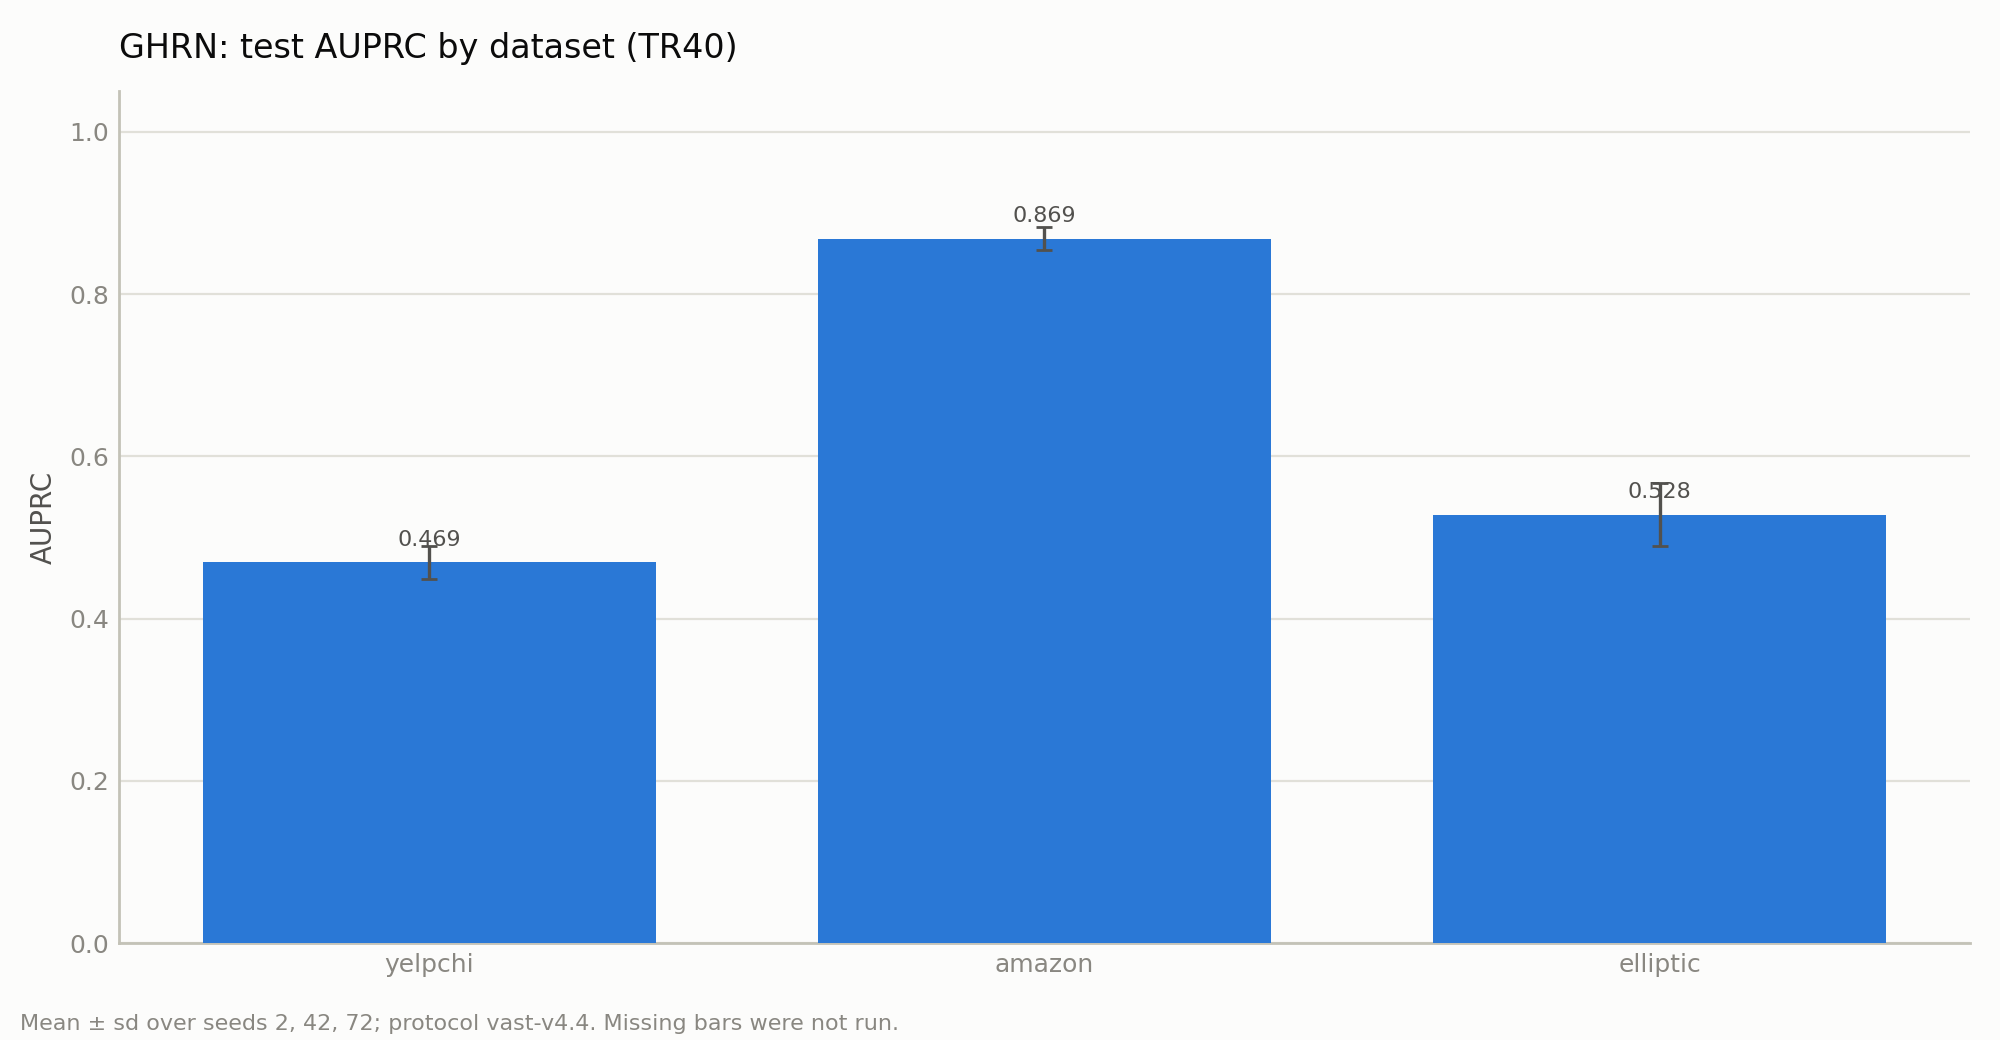

comparison_auroc_TR40.png


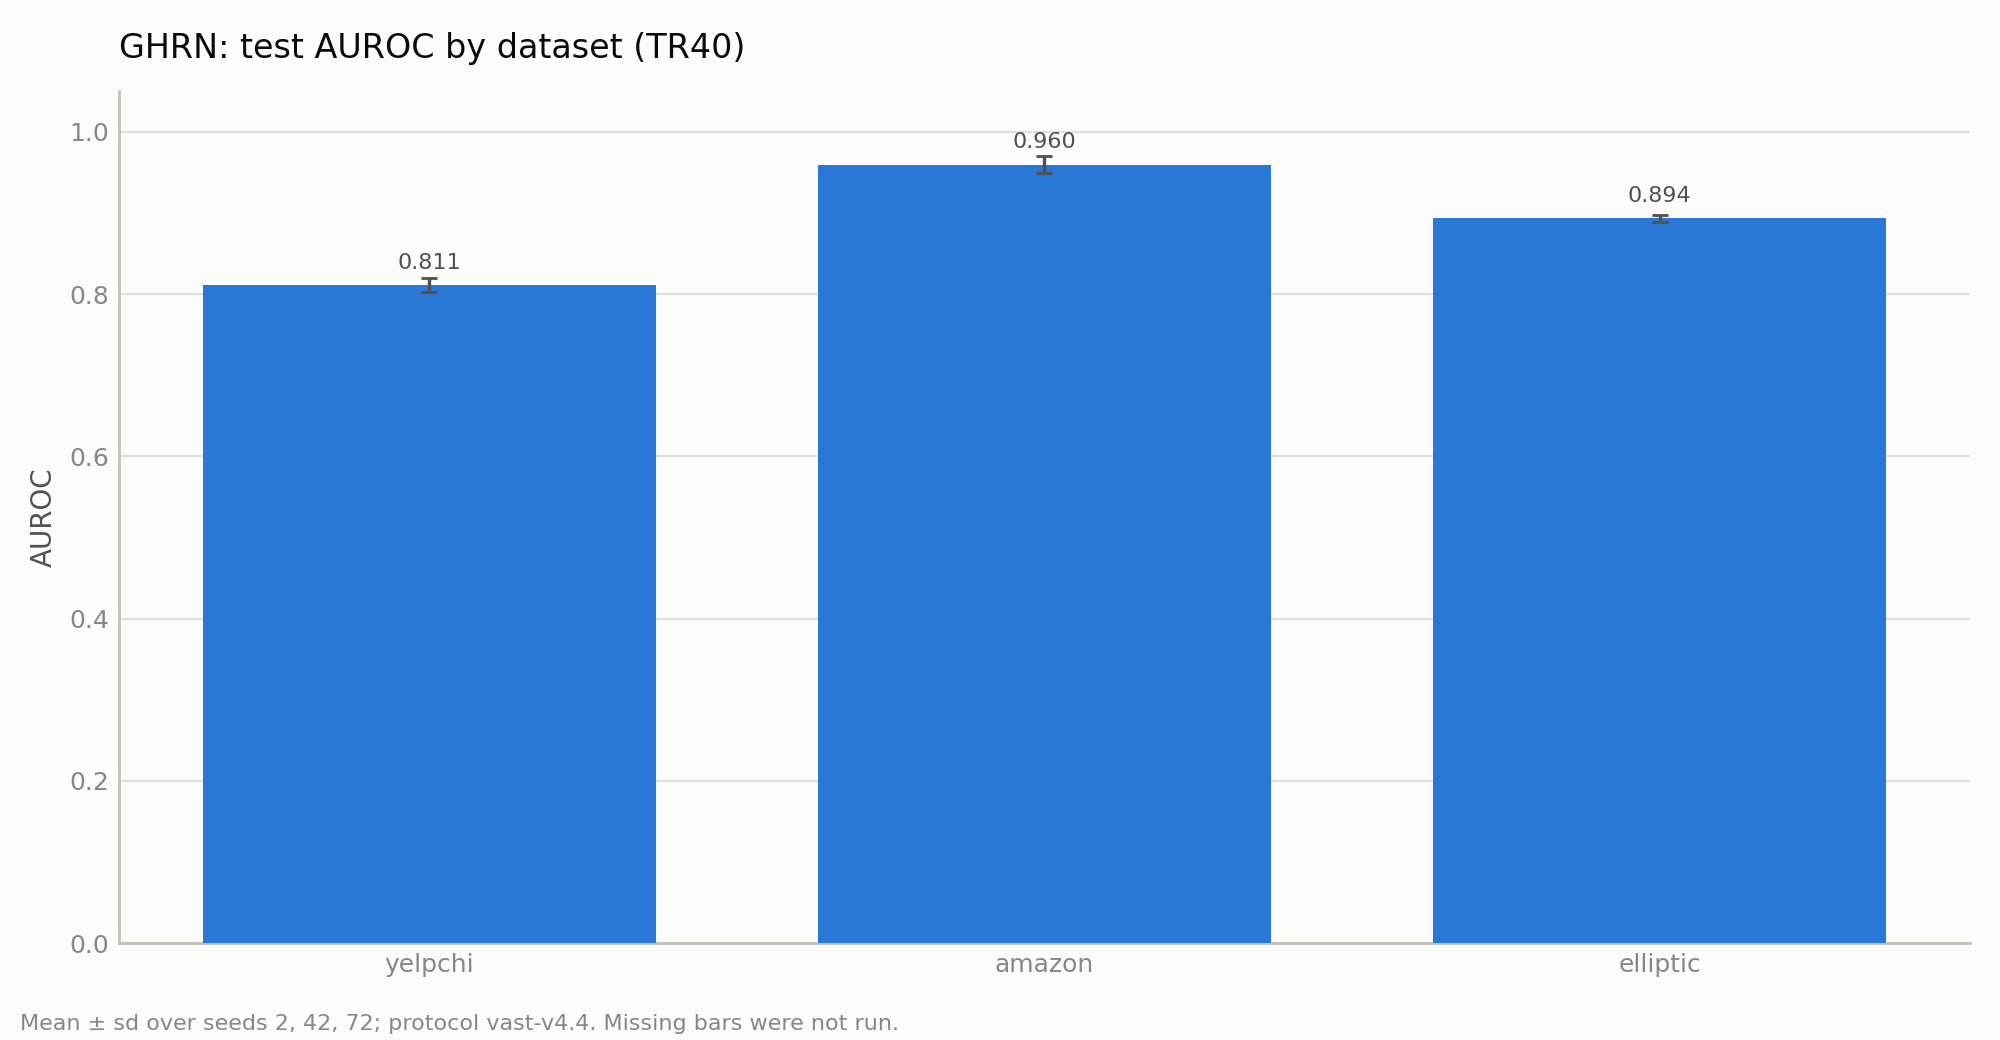

comparison_fraud_precision_TR40.png


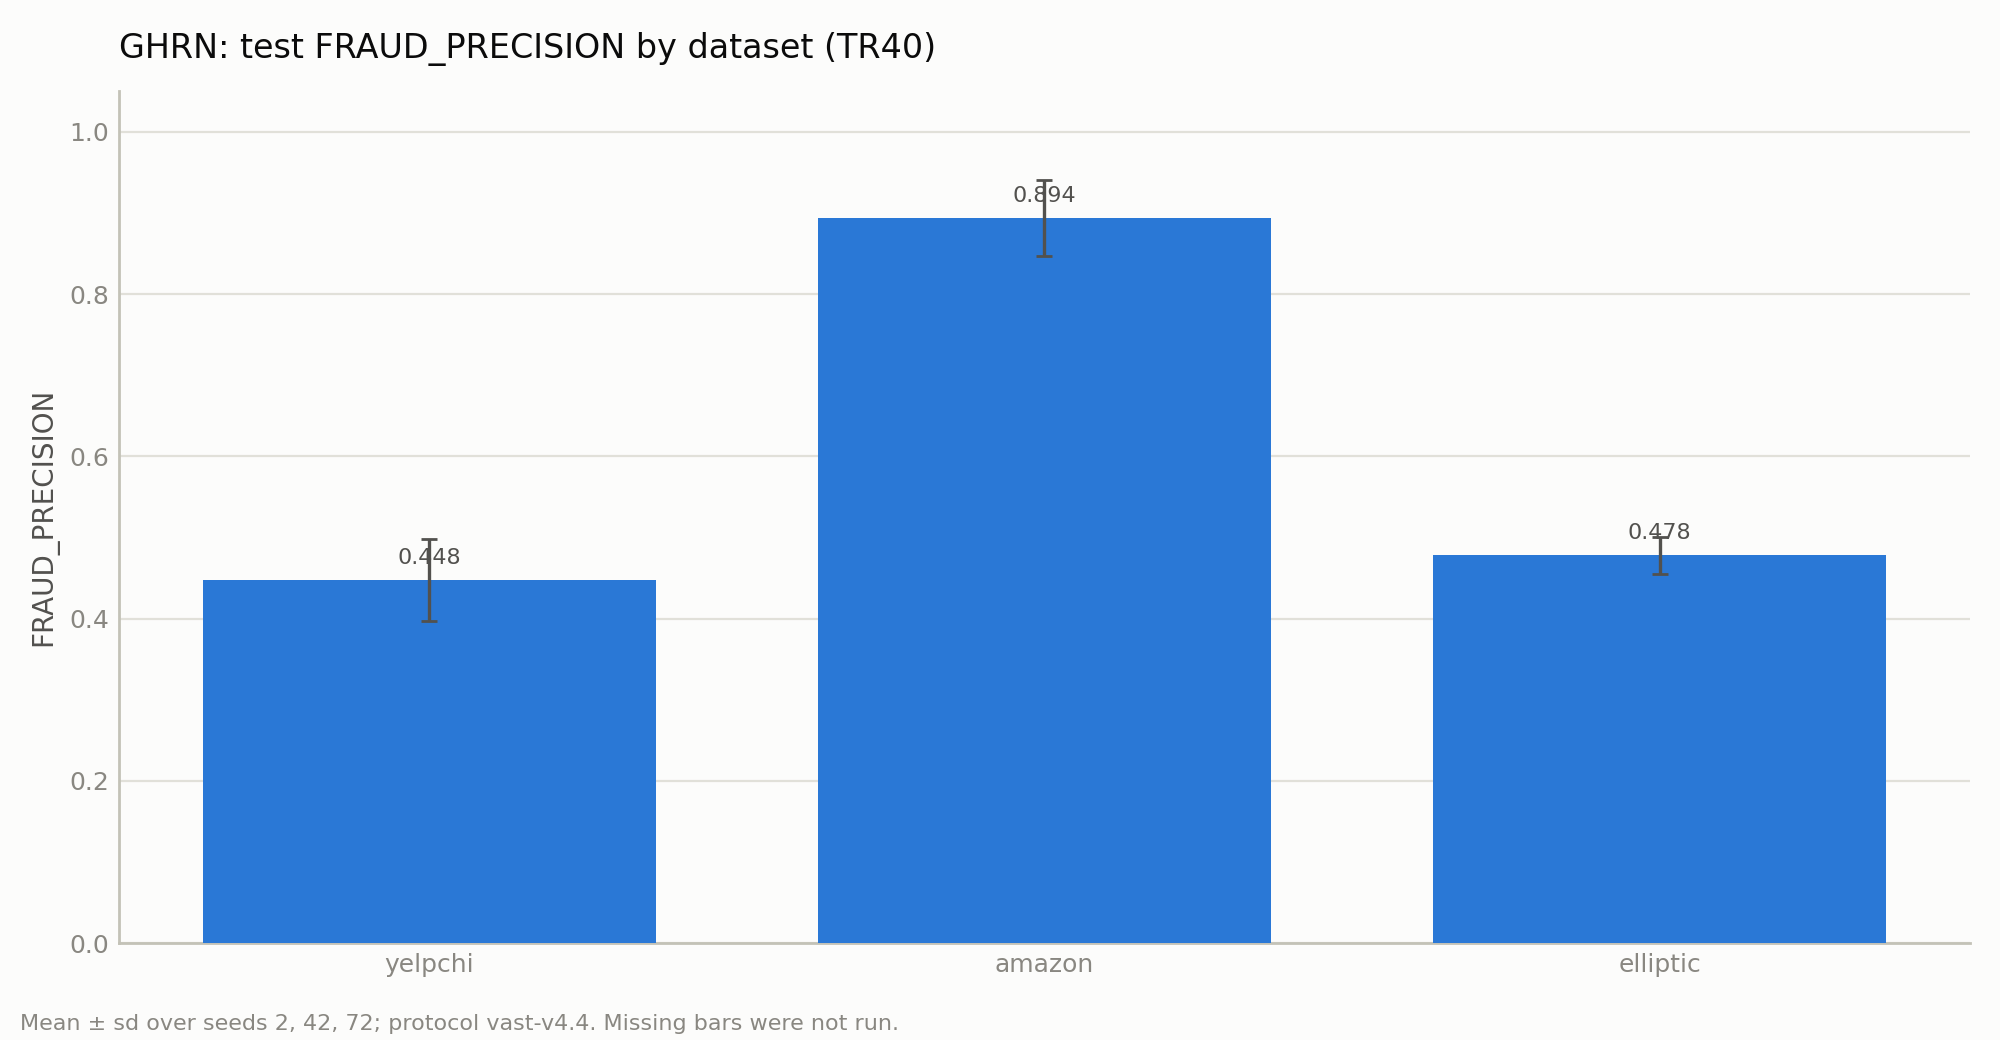

comparison_fraud_recall_TR40.png


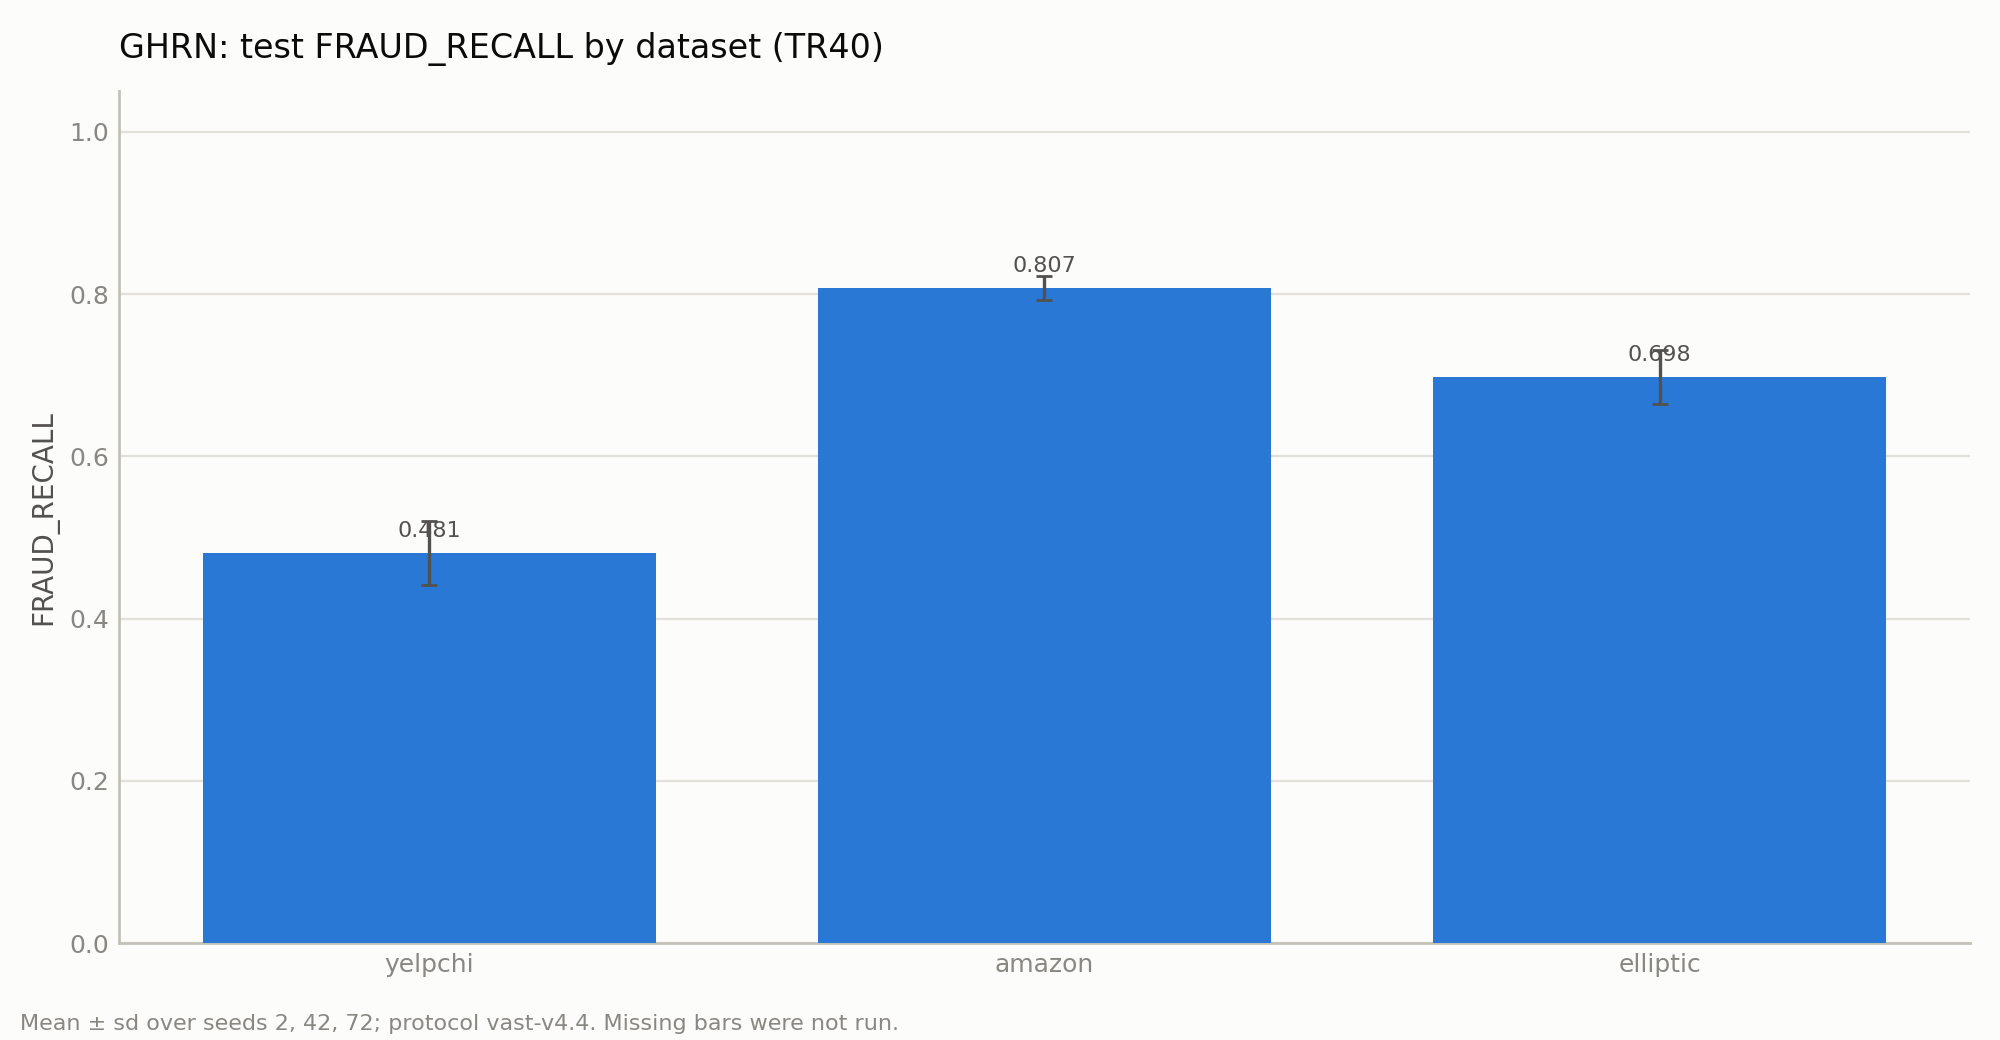

comparison_macro_f1_TR40.png


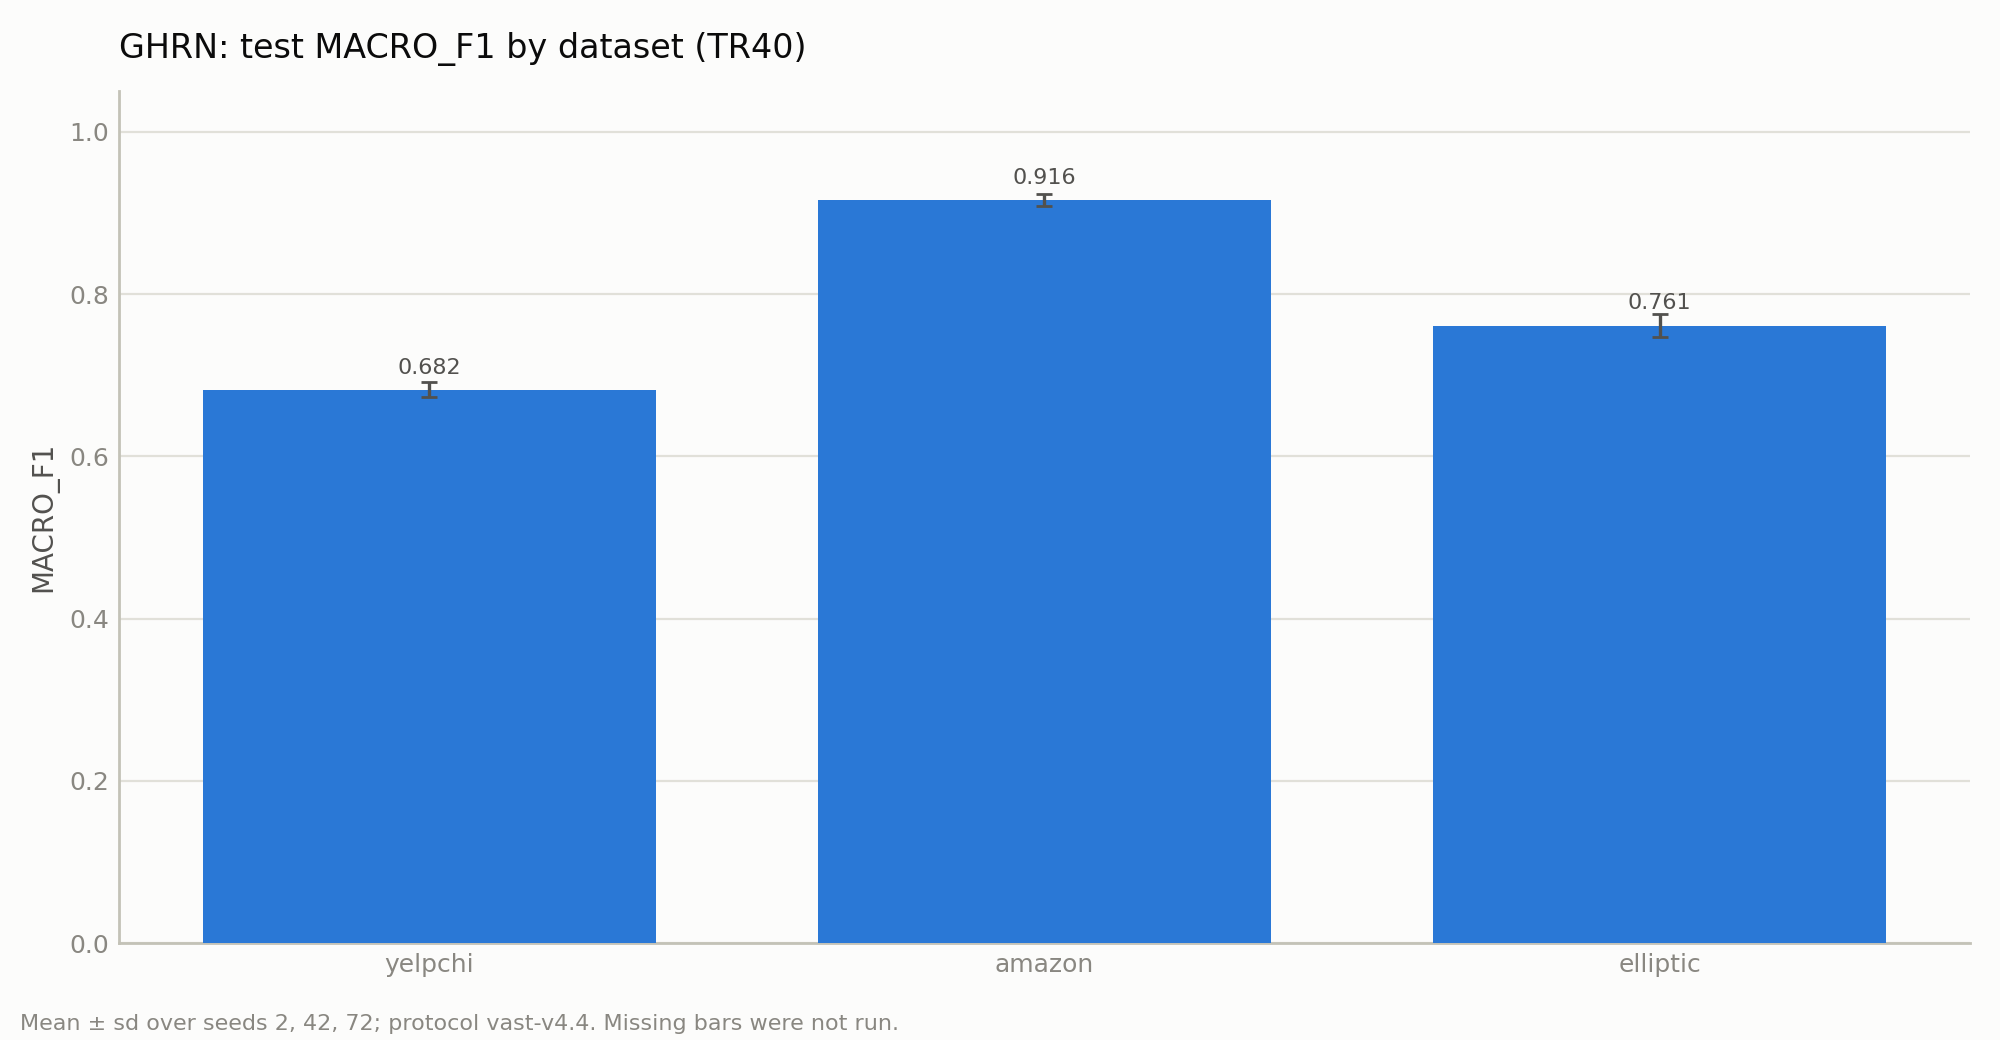

label_scarcity_auprc.png


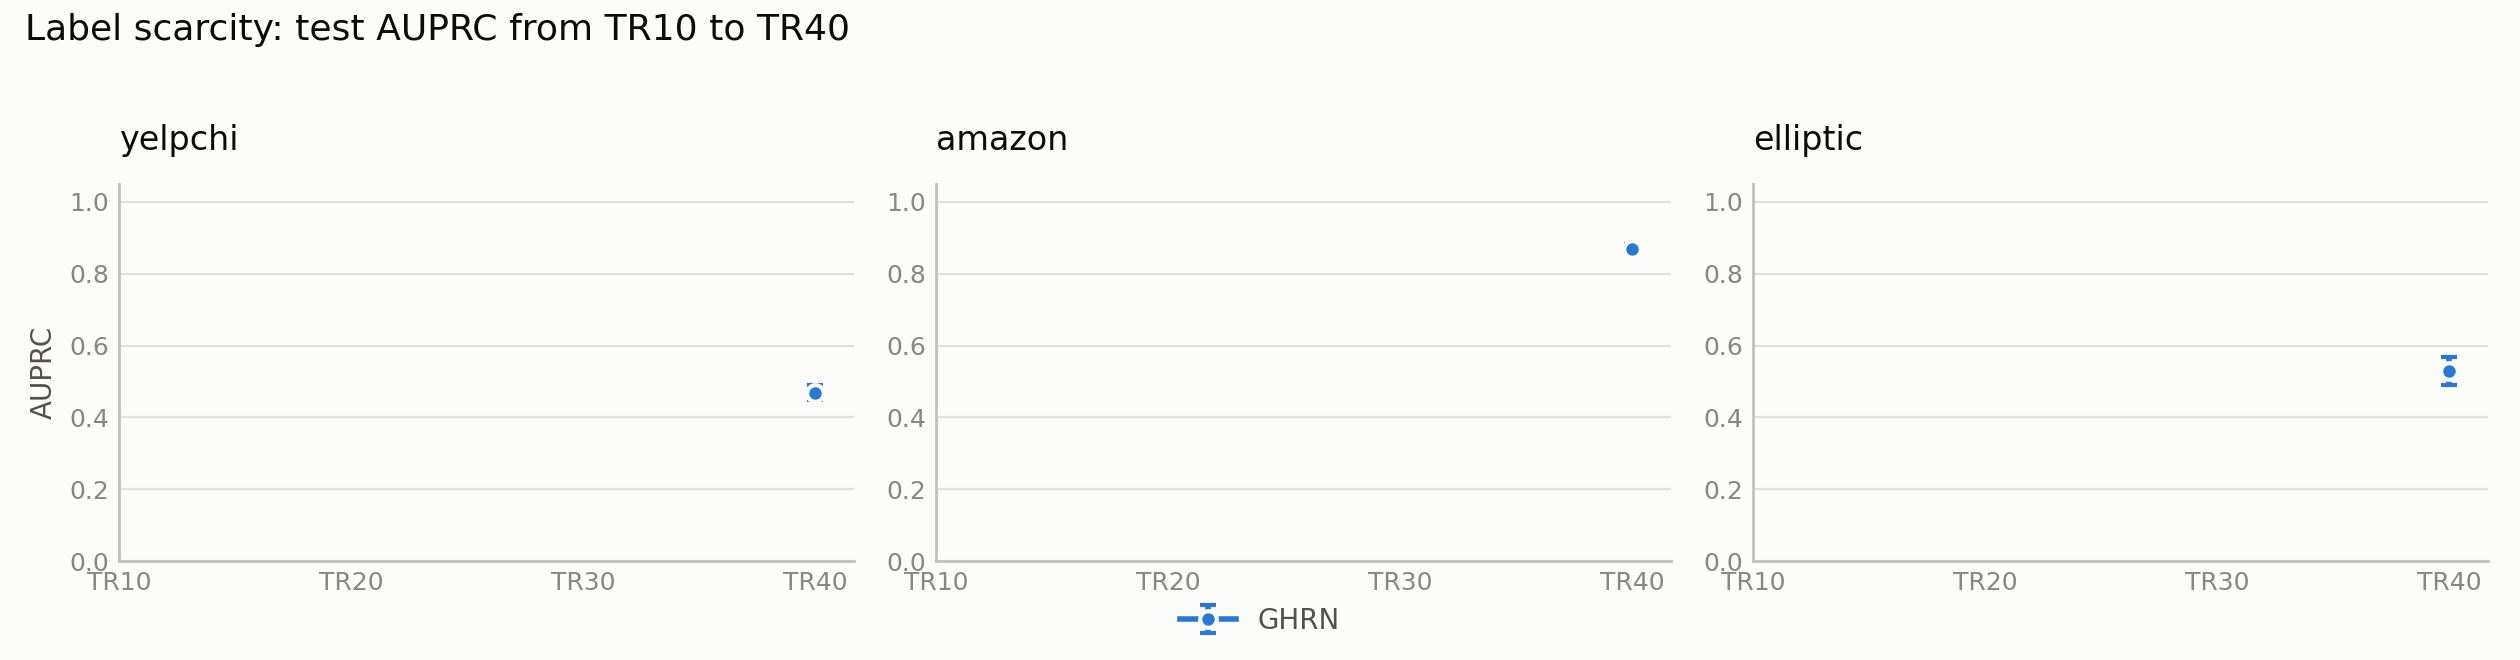

metric_heatmap_TR40.png


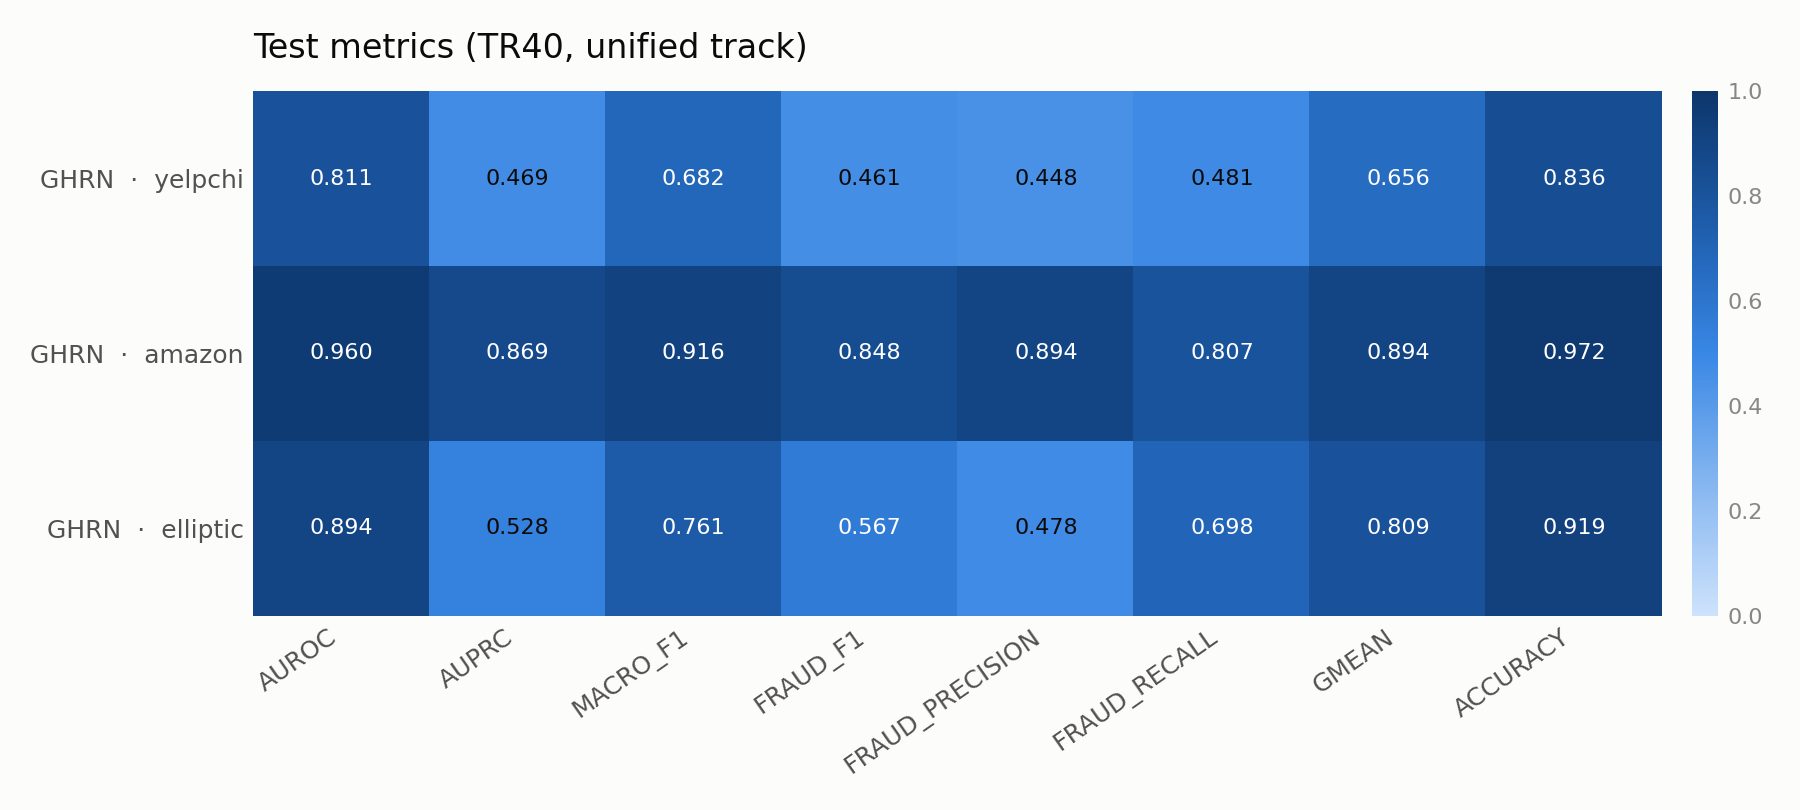

runtime_TR40.png


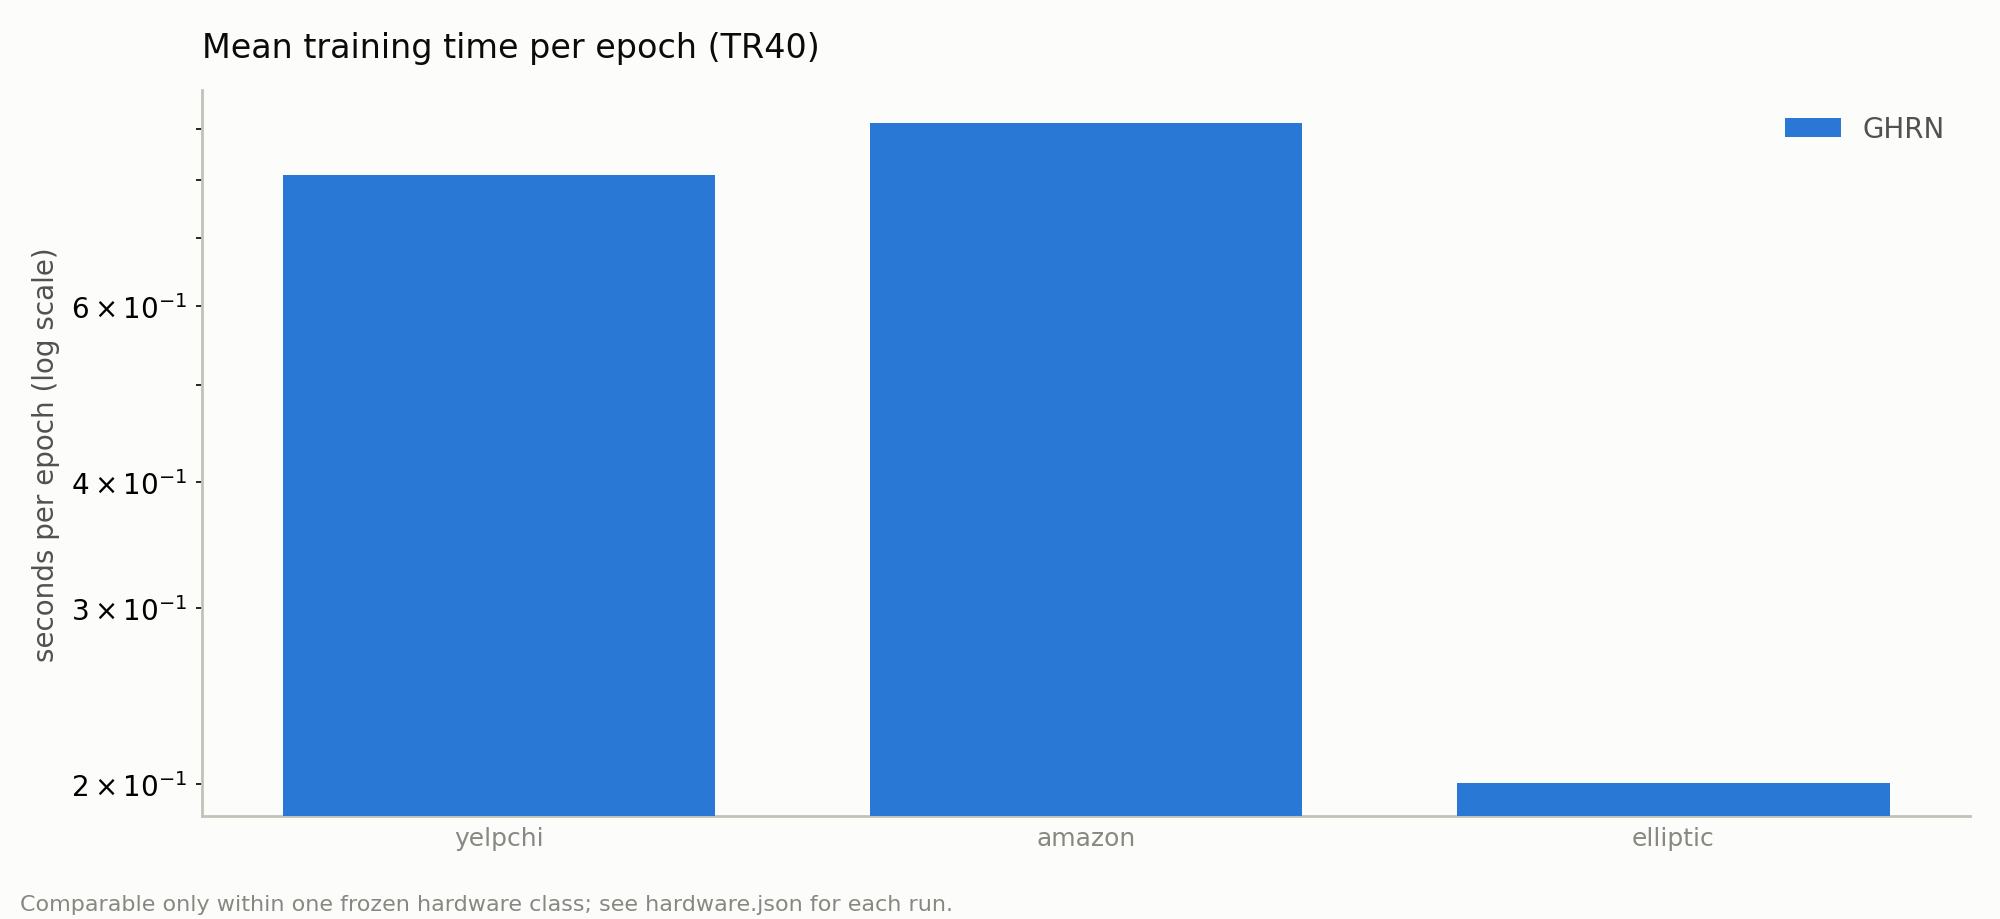

In [73]:
efficiency = RESULTS_ROOT / "tables" / "efficiency_comparison.md"
if efficiency.exists():
    display(Markdown(efficiency.read_text(encoding="utf-8")))

plots_dir = RESULTS_ROOT / "plots"
for image in sorted(plots_dir.glob("*.png")) if plots_dir.exists() else []:
    print(image.name)
    display(Image(filename=str(image)))


## 9. Save

In [74]:
stamp = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime())
archive = shutil.make_archive(str(ROOT / f"comp8851_ghrn_results_{stamp}"),
                              "zip", root_dir=str(RESULTS_ROOT))

files = [f for f in RESULTS_ROOT.rglob("*") if f.is_file()]
print(f"Archive : {archive}")
print(f"Size    : {Path(archive).stat().st_size / 1024**2:.1f} MB")
print(f"Files   : {len(files):,}")
print(f"Runs    : {sum(1 for f in files if f.name == 'summary.json')}")
print(f"Models  : {sum(1 for f in files if f.suffix == '.pt')} checkpoint file(s)")

print("\nKEEP THIS ARCHIVE. The comparison notebook takes one archive per model.")
if PLATFORM == "kaggle":
    print("\nKaggle: it is in /kaggle/working and appears under Output.")
    print("Use 'Save Version' -> 'Save & Run All (Commit)' to run headless and persist it.")
elif PLATFORM == "colab":
    try:
        from google.colab import files as colab_files
        colab_files.download(archive)
    except Exception as exc:
        print(f"  auto-download unavailable ({exc}); use the file browser.")
else:
    print(f"\nCopy it off the host before destroying the instance:")
    print(f"  scp -P <port> root@<host>:{archive} .")


Archive : /kaggle/working/comp8851/comp8851_ghrn_results_20260913T091140Z.zip
Size    : 10.1 MB
Files   : 409
Runs    : 21
Models  : 90 checkpoint file(s)

KEEP THIS ARCHIVE. The comparison notebook takes one archive per model.

Kaggle: it is in /kaggle/working and appears under Output.
Use 'Save Version' -> 'Save & Run All (Commit)' to run headless and persist it.


## Done

`results_ghrn/` now contains:

- `raw/` one evidence bundle per run: config, protocol identity, environment,
  hardware, dataset and view manifests, split indices, per-epoch timings with
  validation timed separately, validation metrics, test metrics, terminal log
  and the selected checkpoint
- `metrics/` the tuning trial records and per-run metrics
- `tables/` per-dataset comparisons, the aggregate summary, LaTeX, the run
  ledger and the efficiency comparison
- `plots/` comparison figures per metric, heatmap, runtime
- `reports/` the experiment matrix with an explicit status per cell, the dataset
  manifest and the reproducibility manifest

Next: run the other model's notebook, then `COMP8851_Compare.ipynb` with both
archives for the cross-model tables.
